# Mammo-FM full training — three-class Normal / Benign / Malignant at 1520×912

**Project:** Q-INTERVAL-Lite+ · **Author:** Pasindu Pahasara Balasooriya Lekamlage (104348348)
**Supersedes:** `MammoFM_Demo_Run_Colab.ipynb` (kept unchanged; nothing here overwrites it)

Fine-tunes the **Mammo-FM pretrained EfficientNet-B5 image encoder** with a three-class head,
on the prepared images **at their native 1520×912**. Encoder fine-tuning only — no text
encoder, no report generation, no reproduction of the vision-language foundation model.

## Two contracts, deliberately separate

| | what it is | where it comes from |
|---|---|---|
| **Preprocessing provenance** | how the prepared files were *produced*: breast crop, resize, padding, intensity handling, CLAHE off, and the target the prepare session recorded | read from the pinned `preprocessing.py` and reported, never used as the model input size |
| **Model-input contract** `model-input/2` | what this model *consumes*: 1520 × 912, grayscale replicated to 3 channels, ImageNet mean/std, geometry adapter `passthrough-v2` | declared in the configuration cell and **verified against the actual files** |

Conflating the two is how a model trained at one resolution ends up served at another. They
are versioned separately, both are recorded in every checkpoint and in the exported bundle,
and the model-input version is part of the configuration hash — so a cached result or a
checkpoint from the earlier 760×456 spec can never be reused here.

## What changed from the demo notebook

| # | Demo run | This notebook |
|---|---|---|
| 1 | Extracted `dataset.zip` and re-generated every model input in-session | **Consumes the already-prepared export.** Copies it Drive → local, verifies the transfer, trains from local disk. Breast cropping, windowing, CLAHE and every other raw step are never re-run — an explicit gate refuses that path instead of falling back to it. |
| 1a | — | **Handles the export as the TAR shard set it actually is.** The prepare session writes one shard set per variant (`baseline_NN.tar`, `masters_NN.tar`, `clahe_2p0_grid8_NN.tar`, `reports_NN.tar`) beside `SHA256SUMS.json` and `COMPLETE.json`, so a plain directory copy mirrors archives rather than images. Only the **declared** variant `baseline` and the declared sidecars are extracted; `clahe_*` is refused **by name** because the contract asserts `clahe: false`, and the variable-size `masters_*` never enters the index. Every shard is checked against the checksum index by size and SHA-256 before it is opened, an unlisted or gapped shard set is refused, and only the declared variant's subtree is searched — so a row can never resolve to another variant's file of the same name. |
| 2 | Input reduced to 760×456 | **Trains at the prepared 1520×912.** Actual PNG dimensions are read from every file's header and reported by source *before* training. Matching files pass through the geometry adapter unchanged; unexpected dimensions **stop the run** with the offending files named. Nothing is silently resized, and a smaller image is never enlarged and then described as native high-resolution data. |
| 3 | Derived the calibration split in-session when absent | **Reuses the frozen partition assignments, labels and exclusion records**, and verifies the manifest's roles against the frozen split file itself. Counts are recomputed and diffed against the last verified figures. `selection` stays unused. |
| 4 | Strict encoder load, `_fc.*` allowed absent | Unchanged in substance, plus the full checkpoint SHA-256, architecture record and package versions, and **a fresh encoder per trial** — no trial starts from another trial's fine-tuned weights. |
| 5 | One probe stage + one fine-tune stage under a wall-clock budget | **Stage A** linear probe (encoder frozen *and* in eval mode, head lr 1e-3, ≤10 epochs, patience 3) → **Stage B** full fine-tune from that trial's best probe checkpoint. The probe checkpoint stays a valid final candidate. Explicit training-mode helper instead of monkey-patching `Module.train`. |
| 6 | Cosine, 20 epochs, patience 5, **hard wall-clock cutoff** | 3-epoch linear warm-up → `ReduceLROnPlateau` on val macro-F1 (max, 0.5, patience 3, abs 0.001), per-group floors 1e-7 / 1e-6, early-stopping patience 12 (abs 0.001), no stop before 20 fine-tune epochs, **no wall-clock cutoff**. Cosine is retained as an explicit comparison configuration, never combined with plateau. Every group's LR is logged per epoch and the real `stop_reason` is reported. |
| 7 | Deterministic inputs only | Named profiles `none` and `mild` (±5° rotation p=0.5 on an expanded canvas, ×0.95–1.05 intensity gain p=0.3). Val / calibration / test stay deterministic. Reproducible per-source preview with geometry and tissue-coverage checks. |
| 8 | Largest micro-batch found by pushing to OOM | Effective batch 32 throughout; physical batch measured **at 1520×912** over 32 / 16 / 8 / 4 / 2 / 1 with matching gradient accumulation, every probe tensor and graph released between attempts. If batch size 1 does not fit the notebook **stops** — it never reduces the image resolution to make training fit. |
| 9 | A smoke training run that produced a real checkpoint | **No smoke training.** A preflight cell does brief input, checkpoint-loading and memory checks, writes no checkpoint and no result, and cannot produce a selectable training outcome; the model, optimiser and seeds are reinitialised afterwards. Training always runs on the full training partition. |
| 10 | Single run | A **declared experiment sequence** behind one strict compatibility test, with the cache keyed by configuration hash **across phases**: longer no-aug → longer mild-aug → LR search → weight decay → dropout → multi-seed, plus a faithful demo-recipe reference. Selection metric fixed as validation macro-F1 before any results are seen, and freezing is refused until **all three declared seeds (42, 2026, 3407)** have finished for both shortlisted configurations — there is no single-seed fallback. |
| 11 | Plain cross-entropy | Plain CE and natural shuffling remain the default. Moderately weighted CE (`w[c] ∝ sqrt(N/(3·n_c))`, training-only counts) is a **separate opt-in phase**. Source-balanced sampling and Group DRO are out of scope. Dataset identity is never a model input. |
| 12 | `last`/`best` per stage, weights only, copied to Drive at the end | Full resumable state, mirrored to Drive **every epoch** through a temporary file with checksum verification, replaced only on a match. Every recovered checkpoint is validated before it is resumed from; stage completion is persisted so a stage already ended by early stopping is skipped rather than repeated. An interruption raises immediately: no later stage runs and no result is recorded, so an unfinished trial can never be read back as complete. |
| 13 | Test scored once, ECE on the fit rows | Per-epoch per-class metrics, malignant AUC/AP, CE loss, per-source metrics with undefined values marked. Temperature fitted on calibration **only**, evaluated on separate data, fit-set figures labelled as such. Raw **and** calibrated malignant AUC. Patient-clustered bootstrap CIs. Seed variability reported separately. Export + reload verification with numerical tolerances, and versioned inference code emitted alongside the bundle. |

## Provenance of every setting

- **Inherited from my demo notebook** (unchanged): `clahe: false`, ImageNet mean/std, grayscale
  replicated to 3 channels, the label map Normal=0 / Benign=1 / Malignant=2, the strict
  `image_encoder.*` load, effective batch 32, grad-clip 1.0, probe head lr 1e-3, fine-tune
  head 1e-4 / encoder 1e-5, weight decay 1e-4.
- **Changed here**: the model input is 1520 × 912, the prepared images' own resolution,
  rather than the demo's reduced 760 × 456.
- **Published methods**: linear probing then fine-tuning (Kumar et al., arXiv:2202.10054);
  temperature scaling (Guo et al., ICML 2017); PyTorch AMP and `ReduceLROnPlateau` per the
  official docs; the Mammo-FM encoder and its `extract_features` contract
  (arXiv:2512.00198v2, batmanlab/Mammo-FM).
- **Newly proposed here, to be tested**: the augmentation profiles and their magnitudes, the
  LR / weight-decay / dropout grids, the plateau stopping policy, the multi-seed repeats.

**These are proposed settings to test.** They are not claimed to be optimal, they are not
copied from Mammo-FM's own fine-tuning experiments, and no particular accuracy is promised.
The existing Mammo-Bench test figure (macro-F1 0.6598) was measured at 760×456 and has
already been inspected: it is an **existing benchmark at a different input resolution**, not a
fresh untouched test result and not a like-for-like comparison. The sealed RSNA holdout is not
read, trained on or tuned against anywhere in this notebook.

## 1. Configuration

Everything editable lives in the next cell. Nothing below it needs changing to run a different
experiment — set `PHASE` and re-run.

In [1]:
!pip install -q efficientnet_pytorch scikit-learn tqdm
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader || true

import os
import gc
import re
import sys
import json
import math
import time
import copy
import random
import shutil
import hashlib
import platform
import zipfile
import tarfile
import struct
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from tqdm.notebook import tqdm

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# ========================== EDIT THIS CELL ONLY ==========================

# ---- Drive layout. One place. Nothing below re-derives a path. ----------
DRIVE_ROOT = '/content/drive/MyDrive/mamobench-dataset'

# The already-prepared 1520x912 export. PREPARED_IMAGE_SOURCES is tried in order:
# a .zip is copied locally and extracted; a directory of sharded .tar archives has the
# declared variant extracted (2.2); any other directory is copied locally. The raw
# collection (dataset.zip) is deliberately NOT listed - see the gate in 2.1.
PREPARED_IMAGE_SOURCES = [
    f'{DRIVE_ROOT}/preprocessed_prep-v1.zip',
    f'{DRIVE_ROOT}/preprocessed_prep-v1',
    f'{DRIVE_ROOT}/runs_demo_v1/full/seed_42/preprocessed_prep-v1.zip',
]
# The prepare session packages its output as one TAR shard set per VARIANT:
# `baseline_00.tar`, `masters_00.tar`, `clahe_2p0_grid8_00.tar`, `reports_00.tar`, ...
# alongside SHA256SUMS.json and COMPLETE.json. Which variant is the model input is a
# declared choice, not a guess, and it is part of the model-input contract below.
#   baseline  resize + pad to the target, no CLAHE  <- the model input
#   masters   lossless crops at the original depth, VARIABLE size, not a model input
#   clahe_*   a contrast-equalised candidate. REFUSED here: the contract asserts
#             clahe=False, so training on it would silently change the input.
PREPARED_VARIANT = 'baseline'
PREPARED_SIDECAR_ARCHIVES = ('reports',)     # the export's own manifest and QA report
PREPARED_REFUSED_VARIANTS = ('clahe',)       # never extracted, never trained on
MANIFEST_CANDIDATES = [
    f'{DRIVE_ROOT}/runs_demo_v1/full/seed_42/manifest.csv',
    f'{DRIVE_ROOT}/preprocessed_prep-v1/manifest.csv',
]
EXCLUSIONS_CANDIDATES = [
    f'{DRIVE_ROOT}/runs_demo_v1/full/seed_42/exclusion_manifest.csv',
    f'{DRIVE_ROOT}/preprocessed_prep-v1/exclusion_manifest.csv',
]
# The hash-pinned preprocessing module that produced the prepared images. Read for
# PROVENANCE only - its own recorded target is not the model input size.
PREPROCESSING_CANDIDATES = [
    f'{DRIVE_ROOT}/runs_demo_v1/full/seed_42/preprocessing.py',
    f'{DRIVE_ROOT}/preprocessed_prep-v1/preprocessing.py',
]
SPLIT_CANDIDATES = [
    f'{DRIVE_ROOT}/sprint4_audit/frozen_split.json',
    f'{DRIVE_ROOT}/runs_demo_v1/full/seed_42/frozen_split.json',
]
AUX_SPLIT_DIR = f'{DRIVE_ROOT}/runs_allsources'
# Auxiliary frozen assignment files, read from AUX_SPLIT_DIR. Calibration membership comes
# from these; it is never inferred from the primary split file.
AUX_ASSIGNMENT_FILES = (
    'calibration_split.json',
    'derived_validation_split.json',
    'new_patient_allocation.json',
)
FM_CKPT = f'{DRIVE_ROOT}/mammo_fm/Mammo-FM_BatmanlabTrained_CLIP.tar'

# Where this notebook writes. A NEW directory: the demo run is never touched.
OUT_ROOT = f'{DRIVE_ROOT}/runs_full_training_v2_1520x912'

# ---- Model-input contract, version 2 -----------------------------------
# The dimensions our preprocessing notebook specifies for the prepared files. These are
# a CLAIM, verified against every actual file in section 2.6 before any training starts.
MODEL_INPUT_VERSION = 'model-input/2'
MODEL_INPUT_NAME = 'mammofm-classical-1520x912'
EXPECTED_PREPARED_H = 1520
EXPECTED_PREPARED_W = 912
GEOMETRY_ADAPTER = 'passthrough-v2'   # the ONLY adapter: verify and pass through
NORM_MEAN_DEFAULT = [0.485, 0.456, 0.406]
NORM_STD_DEFAULT = [0.229, 0.224, 0.225]

# ---- What to run -------------------------------------------------------
# 'P0_demo_reference' | 'P1_long_noaug' | 'P2_long_mild' | 'P3_lr_search'
# | 'P4_weight_decay' | 'P5_dropout' | 'P6_seeds' | 'P7_imbalance'
# Run them in order, inspecting the table in section 11 between phases.
PHASE = 'P1_long_noaug'

FORCE_RERUN = False        # True ignores the result cache for the selected phase.
RESUME = True              # True resumes an interrupted trial at its epoch boundary.
RECOVER_FROM_DRIVE = True  # True pulls checkpoints back from Drive if local disk is gone.
MIRROR_EVERY_EPOCHS = 1    # How often completed epochs are mirrored to Drive.

# The content-duplicate check needs a per-image content hash in the manifest. Without
# one the check is UNAVAILABLE, not passing, and it blocks training. Set this True only
# to proceed deliberately without it, knowing an identical image could sit in two
# partitions undetected.
ALLOW_UNVERIFIED_CONTENT_DUPLICATES = False

# ---- Expected figures from the last verified prepare run ---------------
# Recomputed from the manifest at run time. Any difference is explained before training.
LAST_VERIFIED = {
    'manifest_rows_eligible': 19496,
    'processed': 19460,
    'review_required': 36,
    'excluded_total': 41,
    'partitions': {
        'train':       {'images': 11624, 'patients': 3421},
        'val':         {'images': 2018,  'patients': 598},
        'calibration': {'images': 920,   'patients': 255},
        'test':        {'images': 2938,  'patients': 853},
        'selection':   {'images': 1955,  'patients': 557},
    },
    'preprocessing_sha256': '5adad4f338d3f1a49ce7b9683d67b92de0436482a36b06d8455d80a724ef4e91',
    'encoder_sha256_prefix': '58ae959de52d563a',
    'encoder_params_total': 854,
    'encoder_params_covered': 852,
    'feat_dim': 2048,
    # The demo benchmark was measured at 760x456. Different input resolution, so NOT a
    # like-for-like comparison with anything produced here.
    'demo_test_at_760x456': {'accuracy': 0.6736, 'macro_f1': 0.6598,
                             'malignant_roc_auc': 0.8417, 'malignant_ap': 0.7916,
                             'temperature': 1.3663},
    'source_name_only_macro_f1': 0.5575,
}

# ---- Fixed across every trial -----------------------------------------
CLASS_NAMES = ('Normal', 'Benign', 'Malignant')      # index IS the label
EFFECTIVE_BATCH = 32
MICRO_BATCH_CHOICES = (32, 16, 8, 4, 2, 1)           # divisors of 32, largest first
MICRO_BATCH_OVERRIDE = 0                             # 0 = measure it
VAL_BATCH_OVERRIDE = 0                               # 0 = same as micro-batch
MEMORY_HEADROOM_FRAC = 0.80                          # keep 20% of VRAM free
GRAD_CLIP = 1.0
BASE_SEED = 42
N_WORKERS = min(8, max(2, os.cpu_count() or 4))
PREFETCH_FACTOR = 2
BOOTSTRAP_N = 2000
SELECTION_METRIC = 'macro_f1'                        # fixed before any results are seen
UNUSED_PARTITIONS = ('selection',)                   # left unused in this series

# Final selection is not permitted until every declared seed of at least
# SHORTLIST_SIZE configurations has finished. There is no single-seed fallback.
DECLARED_SEEDS = (42, 2026, 3407)
SHORTLIST_SIZE = 2
# A stage that ended any other way did not finish, and its trial is never usable.
CLEAN_STOP_REASONS = ('early_stopping', 'max_epochs')
# =========================================================================

LOCAL_ROOT = '/content/mammofm_full'
LOCAL_PREPARED = f'{LOCAL_ROOT}/prepared'
LOCAL_PKG = f'{LOCAL_ROOT}/pkg'
LOCAL_RUNS = f'{LOCAL_ROOT}/runs'
LOCAL_REPORTS = f'{LOCAL_ROOT}/reports'
for _d in (LOCAL_ROOT, LOCAL_PREPARED, LOCAL_PKG, LOCAL_RUNS, LOCAL_REPORTS):
    os.makedirs(_d, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ON_CUDA = DEVICE.type == 'cuda'
USE_BF16 = ON_CUDA and torch.cuda.is_bf16_supported()
AMP_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
USE_AMP = ON_CUDA
USE_SCALER = USE_AMP and not USE_BF16
if ON_CUDA:
    torch.backends.cudnn.benchmark = True

VERSIONS = {
    'python': platform.python_version(),
    'torch': torch.__version__,
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'opencv': cv2.__version__,
    'platform': platform.platform(),
    'cuda': torch.version.cuda,
    'gpu': torch.cuda.get_device_name(0) if ON_CUDA else None,
}


def sha256_file(path: str, chunk: int = 1 << 22) -> str:
    """SHA-256 of a file, streamed."""
    h = hashlib.sha256()
    with open(path, 'rb') as fh:
        for block in iter(lambda: fh.read(chunk), b''):
            h.update(block)
    return h.hexdigest()


def sha256_obj(obj: Any) -> str:
    """Stable hash of a JSON-serialisable object. Used for config identity."""
    payload = json.dumps(obj, sort_keys=True, separators=(',', ':'), default=str)
    return hashlib.sha256(payload.encode('utf-8')).hexdigest()


def first_existing(candidates: Sequence[str]) -> Optional[str]:
    """First path in `candidates` that exists. None if none do - never a guess."""
    for path in candidates:
        if os.path.exists(path):
            return path
    return None


def atomic_write_bytes(path: str, data: bytes) -> None:
    """Temp file then rename, so an interrupted write cannot replace a valid file."""
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    tmp = f'{path}.tmp'
    with open(tmp, 'wb') as fh:
        fh.write(data)
        fh.flush()
        os.fsync(fh.fileno())
    os.replace(tmp, path)


def atomic_torch_save(obj: Any, path: str) -> None:
    """torch.save via temp-then-rename. Never leaves a truncated checkpoint."""
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    tmp = f'{path}.tmp'
    torch.save(obj, tmp)
    os.replace(tmp, path)


def atomic_json_dump(obj: Any, path: str) -> None:
    atomic_write_bytes(path, json.dumps(obj, indent=2, default=str).encode('utf-8'))


def copy_if_different(src: str, dst: str) -> bool:
    """shutil.copy raises SameFileError when src and dst resolve to one path."""
    if not os.path.exists(src):
        return False
    if os.path.abspath(src) == os.path.abspath(dst):
        return False
    os.makedirs(os.path.dirname(dst) or '.', exist_ok=True)
    shutil.copy2(src, dst)
    return True


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed % (2 ** 32))
    torch.manual_seed(seed)
    if ON_CUDA:
        torch.cuda.manual_seed_all(seed)


def rng_state_snapshot() -> Dict[str, Any]:
    state = {
        'python': random.getstate(),
        'numpy': np.random.get_state(),
        'torch': torch.get_rng_state(),
    }
    if ON_CUDA:
        state['cuda'] = torch.cuda.get_rng_state_all()
    return state


def rng_state_restore(state: Dict[str, Any]) -> None:
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch'])
    if ON_CUDA and 'cuda' in state:
        torch.cuda.set_rng_state_all(state['cuda'])


class TrialInterrupted(BaseException):
    """A trial was interrupted. Deliberately a BaseException, not an Exception.

    An interruption must reach the phase runner untouched: nothing may advance to the
    next stage, and nothing may be recorded as complete. Subclassing BaseException keeps
    it out of the way of any `except Exception` intended for real training errors.
    """


def free_cuda() -> None:
    """Release Python-side references, then the CUDA caching allocator."""
    gc.collect()
    if ON_CUDA:
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()


if PREPARED_VARIANT in PREPARED_REFUSED_VARIANTS or any(
        PREPARED_VARIANT.startswith(v) for v in PREPARED_REFUSED_VARIANTS):
    raise RuntimeError(f'PREPARED_VARIANT={PREPARED_VARIANT!r} is also listed as refused. '
                       'The declared model input cannot be a refused variant.')

seed_everything(BASE_SEED)
print(f'device {DEVICE}' + (f' ({VERSIONS["gpu"]})' if ON_CUDA else ''))
print('precision', 'bf16' if USE_BF16 else ('fp16 + GradScaler' if USE_AMP else 'fp32'))
print(f'model input contract {MODEL_INPUT_VERSION} / {MODEL_INPUT_NAME}: '
      f'{EXPECTED_PREPARED_H} x {EXPECTED_PREPARED_W}, adapter {GEOMETRY_ADAPTER}')
print(f'prepared variant {PREPARED_VARIANT!r} | sidecars '
      f'{list(PREPARED_SIDECAR_ARCHIVES)} | refused {list(PREPARED_REFUSED_VARIANTS)}')
print(f'phase {PHASE} | base seed {BASE_SEED} | workers {N_WORKERS}')
print(f'declared seeds {list(DECLARED_SEEDS)} | shortlist size {SHORTLIST_SIZE} | '
      f'clean stop reasons {list(CLEAN_STOP_REASONS)}')
print(json.dumps(VERSIONS, indent=2))

  Preparing metadata (setup.py) ... done
NVIDIA A100-SXM4-80GB, 81920 MiB
Mounted at /content/drive
device cuda (NVIDIA A100-SXM4-80GB)
precision bf16
model input contract model-input/2 / mammofm-classical-1520x912: 1520 x 912, adapter passthrough-v2
prepared variant 'baseline' | sidecars ['reports'] | refused ['clahe']
phase P1_long_noaug | base seed 42 | workers 8
declared seeds [42, 2026, 3407] | shortlist size 2 | clean stop reasons ['early_stopping', 'max_epochs']
{
  "python": "3.13.15",
  "torch": "2.11.0+cu128",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "opencv": "5.0.0",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "cuda": "12.8",
  "gpu": "NVIDIA A100-SXM4-80GB"
}


## 2. Prepared data

The prepared images already exist at 1520×912. This section copies them to local storage,
verifies the transfer, reads the manifest, exclusion records and frozen split, and then
**measures the actual image dimensions** before anything is trained. It never rebuilds the raw
dataset and never repeats breast segmentation, windowing or CLAHE — a gate below refuses that
path explicitly rather than falling back to it.

### 2.1 Resolve the required assets

Nothing is guessed. Each asset is looked up in its configured candidate list and, if absent,
named exactly in a missing-asset report that stops the notebook.

In [2]:
REQUIRED = {}
MISSING = []

MANIFEST_PATH = first_existing(MANIFEST_CANDIDATES)
EXCLUSIONS_PATH = first_existing(EXCLUSIONS_CANDIDATES)
PREPROCESSING_PATH = first_existing(PREPROCESSING_CANDIDATES)
SPLIT_PATH = first_existing(SPLIT_CANDIDATES)
PREPARED_SRC = first_existing(PREPARED_IMAGE_SOURCES)
FM_CKPT_PATH = FM_CKPT if os.path.exists(FM_CKPT) else None

for _label, _value, _cands in (
    ('prepared-data manifest', MANIFEST_PATH, MANIFEST_CANDIDATES),
    ('preprocessing module (provenance)', PREPROCESSING_PATH, PREPROCESSING_CANDIDATES),
    ('frozen split manifest', SPLIT_PATH, SPLIT_CANDIDATES),
    ('prepared image export', PREPARED_SRC, PREPARED_IMAGE_SOURCES),
    ('Mammo-FM checkpoint', FM_CKPT_PATH, [FM_CKPT]),
):
    if _value is None:
        MISSING.append({'asset': _label, 'looked_in': list(_cands)})
    else:
        REQUIRED[_label] = _value

if EXCLUSIONS_PATH is None:
    print('NOTE: no exclusion_manifest.csv found. Exclusions will be derived from the '
          'manifest status columns only, and the count is reported against '
          f'LAST_VERIFIED["excluded_total"] = {LAST_VERIFIED["excluded_total"]}.')
    print('      looked in: ' + ', '.join(EXCLUSIONS_CANDIDATES))
else:
    REQUIRED['exclusion records'] = EXCLUSIONS_PATH

if MISSING:
    print('MISSING ASSETS - training cannot start. Nothing is guessed and there is no '
          'fallback to raw-data preprocessing.\n')
    for item in MISSING:
        print(f'  * {item["asset"]}')
        for cand in item['looked_in']:
            print(f'      looked in: {cand}')
    print('\nWhat each one unblocks:')
    print('  prepared-data manifest   partition assignments, labels, per-image records')
    print('  preprocessing module     provenance of how the files were produced')
    print('  frozen split manifest    patient-level partition membership, verified in 2.5')
    print('  prepared image export    the 1520x912 model inputs themselves')
    print('  Mammo-FM checkpoint      the pretrained encoder weights')
    print('\nIf the prepared image export was never written to Drive it has to be exported '
          'from the prepare session before this notebook can run. Re-running the raw crop '
          'pipeline here is refused by design: it would be a second preprocessing pass and '
          'would not reproduce the images this manifest describes.')
    raise SystemExit('missing required assets - see the list above')

print('resolved:')
for _k, _v in REQUIRED.items():
    print(f'  {_k:36s} {_v}')

resolved:
  prepared-data manifest               /content/drive/MyDrive/mamobench-dataset/runs_demo_v1/full/seed_42/manifest.csv
  preprocessing module (provenance)    /content/drive/MyDrive/mamobench-dataset/runs_demo_v1/full/seed_42/preprocessing.py
  frozen split manifest                /content/drive/MyDrive/mamobench-dataset/sprint4_audit/frozen_split.json
  prepared image export                /content/drive/MyDrive/mamobench-dataset/preprocessed_prep-v1
  Mammo-FM checkpoint                  /content/drive/MyDrive/mamobench-dataset/mammo_fm/Mammo-FM_BatmanlabTrained_CLIP.tar
  exclusion records                    /content/drive/MyDrive/mamobench-dataset/runs_demo_v1/full/seed_42/exclusion_manifest.csv


### 2.2 Copy Drive → local, verify the transfer

Training reads from local disk. Every copied file is verified by size and SHA-256 against the
source, so a truncated Drive read cannot become a silent data change.

**The prepared export is a set of TAR shards, one shard set per variant.** The prepare session
writes `baseline_NN.tar`, `masters_NN.tar`, `clahe_2p0_grid8_NN.tar` and `reports_NN.tar`
beside `SHA256SUMS.json` and `COMPLETE.json`. Mirroring that directory copies archives, not
images, which is why a plain copy leaves nothing for the manifest to resolve against.

So the shard set is handled explicitly:

* only the **declared variant** (`PREPARED_VARIANT`) and the declared sidecars are extracted —
  the refused variants are named in the output and left as archives, so `clahe_*` cannot be
  trained on by accident and the lossless `masters_*` (variable size) never enters the index;
* every shard is checked against `SHA256SUMS.json` by size **and** SHA-256 before it is opened,
  and a shard the index does not list is refused rather than trusted;
* `COMPLETE.json` must say the export was verified, and its own `training_readiness` note is
  printed verbatim — a verified copy is not a claim that the crops are correct;
* each shard is copied, verified, extracted and then deleted locally, so peak disk is one
  shard rather than the whole set, and an extraction marker stops a re-run repeating it.

In [3]:
def copy_and_verify(src: str, dst: str) -> Dict[str, Any]:
    """Copy one file Drive -> local and verify size and SHA-256 both ways."""
    src_bytes = os.path.getsize(src)
    if os.path.exists(dst) and os.path.getsize(dst) == src_bytes:
        src_sha = sha256_file(src)
        if sha256_file(dst) == src_sha:
            return {'src': src, 'dst': dst, 'bytes': src_bytes, 'sha256': src_sha,
                    'action': 'already present and verified'}
    os.makedirs(os.path.dirname(dst) or '.', exist_ok=True)
    t0 = time.time()
    shutil.copyfile(src, dst)
    src_sha = sha256_file(src)
    dst_sha = sha256_file(dst)
    if src_sha != dst_sha or os.path.getsize(dst) != src_bytes:
        raise RuntimeError(f'transfer verification FAILED for {src}: '
                           f'{src_sha[:16]} != {dst_sha[:16]}')
    return {'src': src, 'dst': dst, 'bytes': src_bytes, 'sha256': src_sha,
            'action': f'copied in {time.time() - t0:.0f}s'}


TRANSFERS = []
LOCAL_MANIFEST = f'{LOCAL_REPORTS}/manifest.csv'
LOCAL_PREPROCESSING = f'{LOCAL_PKG}/classical_session_analysis/preprocessing.py'
LOCAL_SPLIT = f'{LOCAL_REPORTS}/frozen_split.json'
LOCAL_FM = f'{LOCAL_ROOT}/mammo_fm_checkpoint.tar'

os.makedirs(f'{LOCAL_PKG}/classical_session_analysis', exist_ok=True)
open(f'{LOCAL_PKG}/classical_session_analysis/__init__.py', 'w').write('')

TRANSFERS.append(copy_and_verify(MANIFEST_PATH, LOCAL_MANIFEST))
TRANSFERS.append(copy_and_verify(PREPROCESSING_PATH, LOCAL_PREPROCESSING))
TRANSFERS.append(copy_and_verify(SPLIT_PATH, LOCAL_SPLIT))
TRANSFERS.append(copy_and_verify(FM_CKPT_PATH, LOCAL_FM))
LOCAL_EXCLUSIONS = None
if EXCLUSIONS_PATH is not None:
    LOCAL_EXCLUSIONS = f'{LOCAL_REPORTS}/exclusion_manifest.csv'
    TRANSFERS.append(copy_and_verify(EXCLUSIONS_PATH, LOCAL_EXCLUSIONS))

# Auxiliary frozen assignment files. These carry the assignments the primary split file
# does not: the reserved calibration patients, any derived validation reallocation, and
# later new-patient allocations. Calibration membership is READ from them, never inferred.
LOCAL_AUX: Dict[str, str] = {}
AUX_MISSING: List[str] = []
for _aux in AUX_ASSIGNMENT_FILES:
    _src = f'{AUX_SPLIT_DIR}/{_aux}'
    if os.path.exists(_src):
        _dst = f'{LOCAL_REPORTS}/aux_{_aux}'
        TRANSFERS.append(copy_and_verify(_src, _dst))
        LOCAL_AUX[_aux] = _dst
    else:
        AUX_MISSING.append(_src)

# ---- the prepared images -----------------------------------------------------------
# Three shapes, handled explicitly. A .zip is copied and extracted. A directory of TAR
# shards has ONLY its declared variant and sidecars extracted. Any other directory is
# mirrored. Nothing guesses which variant is the model input.
SHARD_RE = re.compile(r'^(?P<prefix>.+?)_(?P<index>\d{2})\.tar$')
UNSAFE_MEMBER = 'unsafe archive member'


def group_shard_archives(names: Sequence[str]) -> Dict[str, List[str]]:
    """{prefix: [shard file name, ...]} in index order, for `<prefix>_NN.tar` names."""
    grouped: Dict[str, List[Tuple[int, str]]] = {}
    for name in names:
        match = SHARD_RE.match(name)
        if match:
            grouped.setdefault(match.group('prefix'), []).append(
                (int(match.group('index')), name))
    return {prefix: [name for _, name in sorted(items)]
            for prefix, items in sorted(grouped.items())}


def classify_shard_prefix(prefix: str) -> Tuple[str, bool, str]:
    """(role, extract?, why) for one shard-set prefix. A declared decision, not a guess."""
    for refused in PREPARED_REFUSED_VARIANTS:
        if prefix == refused or prefix.startswith(refused):
            return ('REFUSED', False,
                    f'matches PREPARED_REFUSED_VARIANTS {refused!r}; the model-input '
                    'contract asserts clahe=False')
    if prefix == PREPARED_VARIANT:
        return ('declared model input', True, 'PREPARED_VARIANT')
    if prefix in PREPARED_SIDECAR_ARCHIVES:
        return ('sidecar', True, 'PREPARED_SIDECAR_ARCHIVES')
    return ('not the declared variant', False,
            f'only {PREPARED_VARIANT!r} is the model input')


def shard_index_gaps(names: Sequence[str]) -> List[int]:
    """Missing shard indices in a set, so an incomplete copy is not read as complete."""
    have = sorted(int(SHARD_RE.match(n).group('index')) for n in names)
    return [i for i in range(have[-1] + 1) if i not in have] if have else []


def extract_tar_shard(archive: str, dest: str) -> int:
    """Extract one shard, refusing absolute, escaping or non-regular members."""
    written = 0
    with tarfile.open(archive, 'r') as tf:
        members = tf.getmembers()
        for member in members:
            name = member.name.replace('\\', '/')
            if name.startswith('/') or '..' in name.split('/'):
                raise RuntimeError(f'{UNSAFE_MEMBER}: {name}')
            if not (member.isfile() or member.isdir()):
                raise RuntimeError(f'{UNSAFE_MEMBER} (not a regular file or directory): '
                                   f'{name}')
            if member.isfile():
                written += 1
        tf.extractall(dest)
    return written


def find_variant_root(root: str, variant: str) -> Optional[str]:
    """The single directory named `variant` inside the extracted export, or None."""
    hits = []
    for dirpath, dirnames, _ in os.walk(root):
        dirnames[:] = [d for d in dirnames if not d.startswith('.')]
        if os.path.basename(dirpath) == variant:
            hits.append(dirpath)
    if len(hits) == 1:
        return hits[0]
    if len(hits) > 1:
        raise RuntimeError(f'{len(hits)} directories named {variant!r} in the extracted '
                           f'export: {hits}. Which one is the model input is ambiguous.')
    return None


def find_export_manifest(root: str) -> Optional[str]:
    """The export's own manifest.csv, when the sidecar archives carried one."""
    hits = []
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if not d.startswith('.')]
        for filename in filenames:
            if filename.lower() == 'manifest.csv':
                hits.append(os.path.join(dirpath, filename))
    return sorted(hits)[0] if len(hits) == 1 else None


PREPARED_LAYOUT = 'unknown'
PREPARED_INDEX_ROOT = LOCAL_PREPARED
EXPORT_MANIFEST_PATH: Optional[str] = None
EXPORT_VARIANT_PARENT: Optional[str] = None
SHARD_REPORT: Dict[str, Any] = {}

_src_entries = sorted(os.listdir(PREPARED_SRC)) if os.path.isdir(PREPARED_SRC) else []
_shard_sets = group_shard_archives(_src_entries)

if PREPARED_SRC.lower().endswith('.zip'):
    PREPARED_LAYOUT = 'zip'
    LOCAL_PREPARED_ZIP = f'{LOCAL_ROOT}/prepared_export.zip'
    TRANSFERS.append(copy_and_verify(PREPARED_SRC, LOCAL_PREPARED_ZIP))
    _marker = f'{LOCAL_PREPARED}/.extracted.json'
    _stamp = {'sha256': sha256_file(LOCAL_PREPARED_ZIP),
              'bytes': os.path.getsize(LOCAL_PREPARED_ZIP)}
    if os.path.exists(_marker) and json.load(open(_marker)) == _stamp:
        print('prepared export already extracted')
    else:
        t0 = time.time()
        with zipfile.ZipFile(LOCAL_PREPARED_ZIP) as zf:
            for info in zf.infolist():
                name = info.filename.replace('\\', '/')
                if name.startswith('/') or '..' in name.split('/'):
                    raise RuntimeError(f'{UNSAFE_MEMBER}: {name}')
            zf.extractall(LOCAL_PREPARED)
        atomic_json_dump(_stamp, _marker)
        print(f'extracted prepared export in {time.time() - t0:.0f}s')
elif _shard_sets:
    PREPARED_LAYOUT = 'tar shards'
    print(f'the prepared export is a TAR shard set: {len(_shard_sets)} variant(s), '
          f'{sum(len(v) for v in _shard_sets.values())} archive(s)')

    # The checksum index is required. Without it a shard cannot be verified, and an
    # unverified shard is not extracted.
    _sums_path = f'{PREPARED_SRC}/SHA256SUMS.json'
    if not os.path.exists(_sums_path):
        raise SystemExit(f'{_sums_path} is missing. The export is a shard set, so every '
                         'archive has to be verified against its checksum index before '
                         'it is opened. Nothing is extracted unverified.')
    SHARD_SUMS = json.load(open(_sums_path))

    # COMPLETE.json records that the export finished and was verified on Drive.
    _complete_path = f'{PREPARED_SRC}/COMPLETE.json'
    if not os.path.exists(_complete_path):
        raise SystemExit(f'{_complete_path} is missing. The prepare session writes it '
                         'only after every archive is verified on Drive, so this export '
                         'is either incomplete or still being written.')
    EXPORT_COMPLETE = json.load(open(_complete_path))
    if str(EXPORT_COMPLETE.get('export_status')) != 'verified':
        raise SystemExit('COMPLETE.json says export_status='
                         f'{EXPORT_COMPLETE.get("export_status")!r}, not "verified".')
    print(f'  export {EXPORT_COMPLETE.get("prep_version")} | config hash '
          f'{EXPORT_COMPLETE.get("config_hash")} | written {EXPORT_COMPLETE.get("when")}')
    print(f'  processed {EXPORT_COMPLETE.get("images_processed")} | review required '
          f'{EXPORT_COMPLETE.get("images_review_required")} | failed '
          f'{EXPORT_COMPLETE.get("images_failed")} | not eligible '
          f'{EXPORT_COMPLETE.get("not_eligible")}')
    print(f'  the export\'s own readiness note: {EXPORT_COMPLETE.get("training_readiness")}')

    print('\n  shard sets found, and what happens to each:')
    _to_extract: List[str] = []
    for _prefix, _names in _shard_sets.items():
        _role, _extract, _why = classify_shard_prefix(_prefix)
        _gaps = shard_index_gaps(_names)
        _bytes = sum(os.path.getsize(f'{PREPARED_SRC}/{n}') for n in _names)
        print(f'    {_prefix:22s} {len(_names):2d} shard(s)  {_bytes / 1e9:6.2f} GB  '
              f'{"EXTRACT" if _extract else "keep as archive":16s} {_role} ({_why})')
        if _gaps:
            raise SystemExit(f'shard set {_prefix!r} is missing indices {_gaps}. An '
                             'incomplete shard set is not extracted.')
        if _extract:
            _to_extract.extend(_names)
    SHARD_REPORT = {
        'layout': 'tar shards', 'source': PREPARED_SRC,
        'declared_variant': PREPARED_VARIANT,
        'sets': {p: {'shards': n, 'role': classify_shard_prefix(p)[0],
                     'extracted': classify_shard_prefix(p)[1]}
                 for p, n in _shard_sets.items()},
        'extracted_shards': list(_to_extract),
        'export_complete': EXPORT_COMPLETE,
    }
    if PREPARED_VARIANT not in _shard_sets:
        raise SystemExit(
            f'the declared variant {PREPARED_VARIANT!r} has no shard set in this export. '
            f'Present: {sorted(_shard_sets)}. Either the prepare session did not write '
            f'it, or PREPARED_VARIANT names the wrong variant. It is not substituted.')

    # One shard at a time: copy, verify against the index, extract, delete. Peak disk is
    # one shard rather than the whole set.
    _marker = f'{LOCAL_PREPARED}/.extracted_shards.json'
    _stamp = {'variant': PREPARED_VARIANT,
              'shards': {n: SHARD_SUMS.get(n, {}).get('sha256', '') for n in _to_extract}}
    if os.path.exists(_marker) and json.load(open(_marker)) == _stamp:
        print(f'\n  the declared shards are already extracted under {LOCAL_PREPARED}')
    else:
        _staging = f'{LOCAL_ROOT}/prepared_shards'
        os.makedirs(_staging, exist_ok=True)
        _files_written = 0
        for _name in _to_extract:
            _expect = SHARD_SUMS.get(_name)
            if not _expect:
                raise SystemExit(f'{_name} is not listed in SHA256SUMS.json, so it '
                                 'cannot be verified. It is not extracted.')
            _local = f'{_staging}/{_name}'
            _t = copy_and_verify(f'{PREPARED_SRC}/{_name}', _local)
            if int(_expect['bytes']) != _t['bytes'] or str(_expect['sha256']) != _t['sha256']:
                raise SystemExit(
                    f'{_name} does not match SHA256SUMS.json.\n'
                    f'  index says {_expect["sha256"][:16]}... {_expect["bytes"]} bytes\n'
                    f'  file is    {_t["sha256"][:16]}... {_t["bytes"]} bytes\n'
                    'The archive on Drive is not the one the export recorded. Nothing is '
                    'extracted from it.')
            t0 = time.time()
            _n = extract_tar_shard(_local, LOCAL_PREPARED)
            _files_written += _n
            os.remove(_local)
            print(f'    {_name:26s} verified, {_n} file(s) extracted in '
                  f'{time.time() - t0:.0f}s')
        atomic_json_dump(_stamp, _marker)
        print(f'  {_files_written} file(s) extracted from '
              f'{len(_to_extract)} verified shard(s)')

    _variant_root = find_variant_root(LOCAL_PREPARED, PREPARED_VARIANT)
    if _variant_root is None:
        raise SystemExit(
            f'no directory named {PREPARED_VARIANT!r} appeared under {LOCAL_PREPARED} '
            'after extraction. The shard members are not laid out the way the prepare '
            'session records them; nothing is searched blind.')
    PREPARED_INDEX_ROOT = _variant_root
    EXPORT_VARIANT_PARENT = os.path.dirname(_variant_root)
    EXPORT_MANIFEST_PATH = find_export_manifest(LOCAL_PREPARED)
    print(f'\n  model inputs are indexed from {PREPARED_INDEX_ROOT}')
    print('  the refused and non-declared variants stay as unopened archives on Drive, '
          'so they cannot enter the index')
    if EXPORT_MANIFEST_PATH:
        print(f"  the export's own manifest: {EXPORT_MANIFEST_PATH} (used in 2.4 as a "
              'path index only; partitions and labels come from the frozen split)')
else:
    PREPARED_LAYOUT = 'directory'
    if os.path.exists(f'{LOCAL_PREPARED}/.mirrored'):
        print('prepared directory already mirrored')
    else:
        t0 = time.time()
        shutil.copytree(PREPARED_SRC, LOCAL_PREPARED, dirs_exist_ok=True)
        open(f'{LOCAL_PREPARED}/.mirrored', 'w').write(PREPARED_SRC)
        print(f'mirrored prepared directory in {time.time() - t0:.0f}s')

for _t in TRANSFERS:
    print(f'  {os.path.basename(_t["dst"]):28s} {_t["bytes"] / 1e6:9.2f} MB  '
          f'{_t["sha256"][:16]}  {_t["action"]}')

FM_SHA256 = next(t['sha256'] for t in TRANSFERS if t['dst'] == LOCAL_FM)
PREP_SHA256 = next(t['sha256'] for t in TRANSFERS if t['dst'] == LOCAL_PREPROCESSING)
SPLIT_FILE_SHA256 = next(t['sha256'] for t in TRANSFERS if t['dst'] == LOCAL_SPLIT)
AUX_SHA256 = {name: next(t['sha256'] for t in TRANSFERS if t['dst'] == path)
              for name, path in LOCAL_AUX.items()}
print(f'\nprepared export layout      {PREPARED_LAYOUT}, variant {PREPARED_VARIANT!r}')
print(f'preprocessing module sha256 {PREP_SHA256}')
print(f'frozen split file sha256    {SPLIT_FILE_SHA256}')
print(f'auxiliary assignment files  {len(LOCAL_AUX)} of {len(AUX_ASSIGNMENT_FILES)} present')
for _name, _sha in sorted(AUX_SHA256.items()):
    print(f'  {_name:34s} {_sha[:16]}')
for _absent in AUX_MISSING:
    print(f'  absent: {_absent}')
if PREP_SHA256 != LAST_VERIFIED['preprocessing_sha256']:
    print('  NOTE: this is not the module revision recorded in LAST_VERIFIED '
          f'({LAST_VERIFIED["preprocessing_sha256"][:16]}...). That is expected if the '
          'prepare session was re-run at 1520x912; it is reported rather than assumed, and '
          'the actual image dimensions are measured in 2.6 either way.')

the prepared export is a TAR shard set: 4 variant(s), 9 archive(s)
  export prep-v1 | config hash dcf6f6cb878b | written 2026-09-09 14:42:41
  processed 19459 | review required 36 | failed 1 | not eligible 235
  the export's own readiness note: NOT ESTABLISHED - export completion means the files copied and their checksums match. It says nothing about whether the crops are correct. The review_required cases are unresolved.

  shard sets found, and what happens to each:
    baseline                2 shard(s)    5.62 GB  EXTRACT          declared model input (PREPARED_VARIANT)
    clahe_2p0_grid8         3 shard(s)    7.15 GB  keep as archive  REFUSED (matches PREPARED_REFUSED_VARIANTS 'clahe'; the model-input contract asserts clahe=False)
    masters                 3 shard(s)    9.14 GB  keep as archive  not the declared variant (only 'baseline' is the model input)
    reports                 1 shard(s)    0.06 GB  EXTRACT          sidecar (PREPARED_SIDECAR_ARCHIVES)


/tmp/ipykernel_14830/2924354788.py:108: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(dest)


    baseline_00.tar            verified, 10667 file(s) extracted in 5s
    baseline_01.tar            verified, 8829 file(s) extracted in 4s
    reports_00.tar             verified, 13 file(s) extracted in 0s
  19509 file(s) extracted from 3 verified shard(s)

  model inputs are indexed from /content/mammofm_full/prepared/out/baseline
  the refused and non-declared variants stay as unopened archives on Drive, so they cannot enter the index
  the export's own manifest: /content/mammofm_full/prepared/reports/manifest.csv (used in 2.4 as a path index only; partitions and labels come from the frozen split)
  manifest.csv                     11.43 MB  29ec4661a9c9f462  copied in 1s
  preprocessing.py                  0.02 MB  5adad4f338d3f1a4  copied in 1s
  frozen_split.json                 0.07 MB  da4e115581c05522  copied in 1s
  mammo_fm_checkpoint.tar        2147.27 MB  58ae959de52d563a  copied in 62s
  exclusion_manifest.csv            0.00 MB  9fc13e36a4d38c06  copied in 1s
  aux_cal

### 2.3 Preprocessing provenance, then the model-input contract

Two separate things, kept separate on purpose.

**Provenance** is read from the pinned `preprocessing.py`: how the prepared files were
produced, including whatever target that session recorded. It is reported and stored, and it
is **not** used to decide what this model consumes.

**The model-input contract** (`model-input/2`) is declared in the configuration cell:
1520 × 912, grayscale replicated to 3 channels, ImageNet mean/std, geometry adapter
`passthrough-v2`. Section 2.6 verifies it against the actual files.

The module's own `prepare_baseline()` enforces *its* recorded target, so it is deliberately
not called here — only its `decode_bytes()` is used, and normalisation is applied once from
the model-input contract.

In [4]:
if LOCAL_PKG not in sys.path:
    sys.path.insert(0, LOCAL_PKG)
from classical_session_analysis import preprocessing as PREP  # noqa: E402

PROVENANCE = {
    'role': 'HOW THE PREPARED FILES WERE PRODUCED - not the model input specification',
    'module_file': 'preprocessing.py',
    'module_sha256': PREP_SHA256,
    'contract': dict(PREP.CONTRACT),
    'recorded_target_h': int(PREP.CONTRACT.get('target_h', -1)),
    'recorded_target_w': int(PREP.CONTRACT.get('target_w', -1)),
    'clahe': PREP.CONTRACT.get('clahe'),
    'orientation': PREP.CONTRACT.get('orientation'),
    'crop': PREP.CONTRACT.get('crop'),
    'entry_points_available': ['decode_bytes', 'prepare_raw', 'prepare_baseline'],
    'entry_points_used_here': ['decode_bytes'],
    'why': ('prepare_baseline() asserts the module\'s own recorded target, and prepare_raw() '
            'would re-run breast cropping on an already-cropped file. Only decoding is '
            'reused; geometry and normalisation come from the model-input contract below.'),
}

if tuple(PREP.CLASS_NAMES) != tuple(CLASS_NAMES):
    raise RuntimeError(f'class order disagrees: module {PREP.CLASS_NAMES} vs '
                       f'notebook {CLASS_NAMES}. Normal=0, Benign=1, Malignant=2 is fixed.')
if PROVENANCE['clahe'] is not False:
    raise RuntimeError(f'provenance says clahe={PROVENANCE["clahe"]}; the prepared baseline '
                       'variant carries no CLAHE and none is applied here')

CLASSES = list(CLASS_NAMES)
LABEL_TO_INDEX = {c: i for i, c in enumerate(CLASSES)}
NORM_MEAN = [float(v) for v in PREP.CONTRACT.get('norm_mean', NORM_MEAN_DEFAULT)]
NORM_STD = [float(v) for v in PREP.CONTRACT.get('norm_std', NORM_STD_DEFAULT)]
N_CHANNELS = int(PREP.CONTRACT.get('channels', 3))
PAD_VALUE = int(PREP.CONTRACT.get('pad_value', 0))
if N_CHANNELS != 3:
    raise RuntimeError(f'channels={N_CHANNELS}; grayscale is replicated to 3 channels')

# MODEL_H / MODEL_W are the declared model input. 2.6 refuses to proceed unless every
# prepared file already has exactly these dimensions.
MODEL_H = int(EXPECTED_PREPARED_H)
MODEL_W = int(EXPECTED_PREPARED_W)

MODEL_INPUT_CONTRACT: Dict[str, Any] = {
    'version': MODEL_INPUT_VERSION,
    'name': MODEL_INPUT_NAME,
    'model_h': MODEL_H,
    'model_w': MODEL_W,
    'channels': N_CHANNELS,
    'channel_construction': 'single grayscale plane replicated to 3 identical channels',
    'norm_mean': NORM_MEAN,
    'norm_std': NORM_STD,
    'normalisation': 'x/255 then (x - mean) / std, applied exactly once',
    'geometry_adapter': GEOMETRY_ADAPTER,
    'geometry_adapter_doc': ('verify the decoded prepared image is already model_h x '
                            'model_w and pass it through unchanged; any other size is a '
                            'hard error. No resize, no pad, no crop, no upscaling.'),
    'accepts': 'prepared prep-v1 export images only, at their native stored resolution',
    'export_variant': PREPARED_VARIANT,
    'export_variant_doc': ('the prepare session writes several variants of every image; '
                           'this contract consumes exactly one of them, and the others '
                           'are never extracted'),
    'export_variants_refused': list(PREPARED_REFUSED_VARIANTS),
    'refuses': ['raw uploads (breast cropping would be a second preprocessing pass)',
                'DICOM (no decoder is implemented or tested here)',
                'any prepared image whose dimensions differ from model_h x model_w',
                f'any export variant other than {PREPARED_VARIANT!r}'],
    'class_mapping': {c: i for i, c in enumerate(CLASSES)},
    'preprocessing_provenance_sha256': PREP_SHA256,
    'preprocessing_recorded_target': [PROVENANCE['recorded_target_h'],
                                      PROVENANCE['recorded_target_w']],
    'supersedes': 'model-input/1 at 760x456, used by the demo run',
}
MODEL_INPUT_HASH = sha256_obj(MODEL_INPUT_CONTRACT)

print('PREPROCESSING PROVENANCE (how the files were made)')
print(f'  contract            {PROVENANCE["contract"].get("name")} / '
      f'{PROVENANCE["contract"].get("prep_version")}')
print(f'  module sha256       {PREP_SHA256[:32]}')
print(f'  recorded target     {PROVENANCE["recorded_target_h"]} x '
      f'{PROVENANCE["recorded_target_w"]}')
print(f'  clahe               {PROVENANCE["clahe"]}')
print(f'  orientation         {PROVENANCE["orientation"]}')
print(f'  entry points used   {PROVENANCE["entry_points_used_here"]}')
print('\nMODEL-INPUT CONTRACT (what this model consumes)')
print(f'  version             {MODEL_INPUT_VERSION} / {MODEL_INPUT_NAME}')
print(f'  input               {MODEL_H} x {MODEL_W}')
print(f'  channels            {N_CHANNELS} - {MODEL_INPUT_CONTRACT["channel_construction"]}')
print(f'  normalisation       mean {NORM_MEAN}  std {NORM_STD}   (ImageNet, inherited)')
print(f'  geometry adapter    {GEOMETRY_ADAPTER}')
print(f'  export variant      {PREPARED_VARIANT} (refused: '
      f'{list(PREPARED_REFUSED_VARIANTS)})')
print(f'  contract hash       {MODEL_INPUT_HASH[:16]}')
print('  label mapping       ' + ', '.join(f'{c}={i}' for i, c in enumerate(CLASSES)))
if (PROVENANCE['recorded_target_h'], PROVENANCE['recorded_target_w']) != (MODEL_H, MODEL_W):
    print(f'\nThe provenance module records {PROVENANCE["recorded_target_h"]}x'
          f'{PROVENANCE["recorded_target_w"]} while this contract declares {MODEL_H}x'
          f'{MODEL_W}. That disagreement is reported, not resolved by assumption: section '
          '2.6 measures the files themselves and stops if they are not '
          f'{MODEL_H}x{MODEL_W}.')
print('\nThe checkpoint configuration gives no documented reason to change mean/std, so the '
      'inherited ImageNet values stand.')

PREPROCESSING PROVENANCE (how the files were made)
  contract            mammofm-classical-baseline / prep-v1
  module sha256       5adad4f338d3f1a49ce7b9683d67b92d
  recorded target     760 x 456
  clahe               False
  orientation         stored orientation retained; no flips are applied
  entry points used   ['decode_bytes']

MODEL-INPUT CONTRACT (what this model consumes)
  version             model-input/2 / mammofm-classical-1520x912
  input               1520 x 912
  channels            3 - single grayscale plane replicated to 3 identical channels
  normalisation       mean [0.485, 0.456, 0.406]  std [0.229, 0.224, 0.225]   (ImageNet, inherited)
  geometry adapter    passthrough-v2
  export variant      baseline (refused: ['clahe'])
  contract hash       8d1b34a1f49b4720
  label mapping       Normal=0, Benign=1, Malignant=2

The provenance module records 760x456 while this contract declares 1520x912. That disagreement is reported, not resolved by assumption: section 2.6 me

### 2.4 Read the manifest and resolve prepared image paths

The manifest's path columns point at the prepare session's own local disk, so every row has to
be rebased onto the export as it actually sits here. Only the **declared variant's** subtree is
indexed (`PREPARED_INDEX_ROOT` from 2.2), so a row can never resolve to a `masters` or `clahe`
file of the same name.

Resolution takes the strongest evidence available, in order:

1. **the export's own manifest**, when the sidecar archives carried one — it records exactly
   which file each `image_id` was written to, so this is a lookup rather than a search. It
   supplies *paths only*: partitions, labels and exclusions still come from the primary
   manifest and the frozen split files;
2. the recorded path columns, longest tail first, against an index of **every trailing path
   suffix** in the variant subtree — so an extra wrapper directory does not defeat matching;
3. `source/image_id`, then a bare `image_id`.

Only a **unique** match resolves: two files matching one row means the manifest does not say
which is meant, and that is reported rather than guessed.

An unresolved row is an error, never a silent drop. When rows fail, the report prints what the
export actually contains — file count, extensions, top-level entries and sample paths — next
to what the manifest expected, because the two lists side by side are what identifies the
cause.

In [5]:
MAN = pd.read_csv(LOCAL_MANIFEST,
                  dtype={'source_subjectID': str, 'patient': str, 'image_id': str,
                         'source_dataset': str, 'label_text': str, 'role': str,
                         'split': str, 'status': str, 'pixel_sha': str},
                  low_memory=False)
print(f'manifest rows {len(MAN)}  columns {len(MAN.columns)}')

_needed = ['image_id', 'patient', 'source_dataset', 'label_text', 'label', 'role',
           'status', 'baseline_path']
_absent = [c for c in _needed if c not in MAN.columns]
if _absent:
    raise RuntimeError(f'manifest is missing required columns {_absent}. '
                       f'Present: {sorted(MAN.columns)}')

IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
MAX_SUFFIX_DEPTH = 6


def index_prepared_export(root: str) -> Dict[str, Any]:
    """Walk the export ONCE and index it, rather than guessing its folder layout.

    Guessing roots only works if the export happens to be shaped the way the guess
    expects, and any extra wrapper directory defeats an exact relative-path match. So
    every file is indexed by each of its trailing path SUFFIXES, one to MAX_SUFFIX_DEPTH
    components deep. A manifest path then matches on its longest unique suffix however
    deeply the export is nested. The inventory is kept for the failure report, so a
    layout that does not match is diagnosed rather than just refused.
    """
    by_suffix: Dict[str, List[str]] = {}
    by_stem: Dict[str, List[str]] = {}
    extensions: Dict[str, int] = {}
    top_level: List[str] = []
    samples: List[str] = []
    total = 0
    if os.path.isdir(root):
        top_level = sorted(os.listdir(root))[:25]
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if not d.startswith('.')]
        for filename in filenames:
            if filename.startswith('.'):
                continue
            full = os.path.join(dirpath, filename)
            rel = os.path.relpath(full, root).replace(os.sep, '/')
            parts = [p for p in rel.split('/') if p]
            for depth in range(1, min(MAX_SUFFIX_DEPTH, len(parts)) + 1):
                key = '/'.join(parts[-depth:]).lower()
                by_suffix.setdefault(key, []).append(full)
            stem, ext = os.path.splitext(filename)
            by_stem.setdefault(stem.lower(), []).append(full)
            extensions[ext.lower()] = extensions.get(ext.lower(), 0) + 1
            total += 1
            if len(samples) < 8:
                samples.append(rel)
    return {'root': root, 'by_suffix': by_suffix, 'by_stem': by_stem,
            'extensions': extensions, 'total_files': total, 'top_level': top_level,
            'samples': samples, 'max_suffix_depth': MAX_SUFFIX_DEPTH}


t0 = time.time()
EXPORT_INDEX = index_prepared_export(PREPARED_INDEX_ROOT)
print(f'indexed the {PREPARED_VARIANT!r} variant subtree in {time.time() - t0:.0f}s: '
      f'{EXPORT_INDEX["total_files"]} file(s), extensions {EXPORT_INDEX["extensions"]}')
print(f'  root:      {PREPARED_INDEX_ROOT}')
print(f'  top level: {EXPORT_INDEX["top_level"]}')
if EXPORT_INDEX['samples']:
    print('  sample relative paths:')
    for _sample in EXPORT_INDEX['samples']:
        print(f'    {_sample}')

_MANIFEST_PATH_COLUMNS = [c for c in ('rel_path', 'preprocessed_image_path',
                                      'baseline_path', 'image_path')
                          if c in MAN.columns]
print(f'  manifest path columns available: {_MANIFEST_PATH_COLUMNS}')


# The prepare session's manifest carries one path column per variant, and the names are
# its schema rather than a pattern to be derived (`masters` is recorded as
# `master_path`, singular). They are declared here so a wrong guess cannot silently
# pick another variant's column; an unknown variant falls back to a search instead.
EXPORT_PATH_COLUMNS = {'baseline': 'baseline_path', 'masters': 'master_path'}


def export_manifest_column(variant: str) -> str:
    """The manifest column that records where `variant` was written."""
    if variant in EXPORT_PATH_COLUMNS:
        return EXPORT_PATH_COLUMNS[variant]
    if variant.startswith('clahe'):
        return 'clahe_path'
    return f'{variant}_path'


def build_export_manifest_index(path: Optional[str], parent: Optional[str],
                                variant: str) -> Dict[str, str]:
    """{image_id: absolute path} from the export's OWN manifest. Paths only.

    The export records, per image_id, the relative path it wrote each variant to. That
    is a statement of fact by the process that wrote the files, so it beats searching.
    Only the declared variant's column is read, only rows whose file actually exists are
    kept, and nothing here touches partitions, labels or exclusions.
    """
    if not path or not parent:
        return {}
    column = export_manifest_column(variant)
    frame = pd.read_csv(path, dtype={'image_id': str}, low_memory=False)
    if 'image_id' not in frame.columns or column not in frame.columns:
        print(f"  the export's manifest has no {column!r} column "
              f'(present: {sorted(frame.columns)[:12]}...), so it is not used as an index')
        return {}
    mapping: Dict[str, str] = {}
    missing = 0
    # fillna before astype: a blank path column stays NaN (a float) through astype(str)
    # on current pandas, and the manifest leaves it blank for every failed row.
    for _iid, _rel in zip(frame['image_id'].astype(str).tolist(),
                          frame[column].fillna('').astype(str).tolist()):
        _rel = str(_rel).replace('\\', '/').strip()
        if not _rel or _rel == 'nan':
            continue
        _full = os.path.normpath(os.path.join(parent, _rel))
        if os.path.exists(_full):
            mapping[_iid] = _full
        else:
            missing += 1
    print(f"  the export's manifest indexes {len(mapping)} {variant} file(s) by image_id"
          + (f'; {missing} recorded path(s) are not present on local disk' if missing
             else ''))
    return mapping


EXPORT_MANIFEST_INDEX = build_export_manifest_index(
    EXPORT_MANIFEST_PATH, EXPORT_VARIANT_PARENT, PREPARED_VARIANT)


def resolution_candidates(row: Dict[str, Any]) -> List[Tuple[str, str]]:
    """(strategy, path-suffix) candidates for one manifest row, strongest evidence first.

    A longer path suffix is stronger evidence about which file a row means than a bare
    name: two sources can hold files with the same name. So the recorded path columns
    are tried longest-tail first, and a bare image_id last.
    """
    image_id = str(row['image_id'])
    source = str(row['source_dataset'])
    out: List[Tuple[str, str]] = []
    for depth in range(MAX_SUFFIX_DEPTH, 0, -1):
        for column in _MANIFEST_PATH_COLUMNS:
            raw = str(row.get(column) or '').replace('\\', '/').strip()
            if not raw or raw == 'nan':
                continue
            parts = [p for p in raw.split('/') if p not in ('', '.')]
            if len(parts) >= depth:
                out.append((f'{column}:tail{depth}', '/'.join(parts[-depth:])))
    for ext in IMAGE_EXTENSIONS:
        out.append(('source/image_id', f'{source}/{image_id}{ext}'))
    for ext in IMAGE_EXTENSIONS:
        out.append(('image_id', f'{image_id}{ext}'))
    seen = set()
    unique = []
    for strategy, rel in out:
        key = rel.lower()
        if key in seen:
            continue
        seen.add(key)
        unique.append((strategy, rel))
    return unique


def resolve_prepared(row: Dict[str, Any]) -> Tuple[str, str]:
    """(path, strategy) for one row, or ('', reason) when it cannot be resolved.

    The export's own manifest is consulted first: it records where each image_id was
    written, so it is a lookup, not a search. Otherwise suffix candidates are tried
    strongest-evidence first and a UNIQUE match wins. An ambiguous
    suffix is not resolved by picking one of its matches - it is remembered and the next
    candidate is tried, and only if nothing unique is ever found is the ambiguity
    reported as the reason. Two files matching a row means the manifest does not say
    which is meant, and guessing is how the wrong image gets trained on.
    """
    direct = EXPORT_MANIFEST_INDEX.get(str(row['image_id']))
    if direct:
        return direct, 'export_manifest:image_id'
    ambiguity = ''
    for strategy, rel in resolution_candidates(row):
        hits = EXPORT_INDEX['by_suffix'].get(rel.lower())
        if not hits:
            continue
        if len(hits) == 1:
            return hits[0], strategy
        if not ambiguity:
            ambiguity = f'ambiguous {strategy} {rel}: {len(hits)} matches'
    stem_hits = EXPORT_INDEX['by_stem'].get(str(row['image_id']).lower())
    if stem_hits:
        if len(stem_hits) == 1:
            return stem_hits[0], 'image_id:stem'
        if not ambiguity:
            ambiguity = f'ambiguous image_id stem: {len(stem_hits)} matches'
    return '', ambiguity or 'no candidate matched'


_records = MAN.to_dict('records')
_resolved = [resolve_prepared(r) for r in _records]
MAN['prepared_path'] = [r[0] for r in _resolved]
MAN['resolution_strategy'] = [r[1] for r in _resolved]

# Exclusions: reuse the recorded file when present, otherwise derive from status.
if LOCAL_EXCLUSIONS is not None:
    EXCL = pd.read_csv(LOCAL_EXCLUSIONS, dtype={'image_id': str})
else:
    _rows = []
    for _iid, _st in zip(MAN.image_id.astype(str), MAN.status.astype(str)):
        if _st == 'failed':
            _rows.append({'image_id': _iid, 'reason': 'preprocessing failure'})
        elif _st == 'review_required':
            _rows.append({'image_id': _iid,
                          'reason': 'unresolved crop review - kept its full frame'})
    EXCL = pd.DataFrame(_rows, columns=['image_id', 'reason'])
EXCL = EXCL.drop_duplicates('image_id')
EXCLUDED_IDS = set(EXCL.image_id.astype(str))

MAN['excluded'] = MAN.image_id.astype(str).isin(EXCLUDED_IDS)
DATA = MAN[(~MAN.excluded) & MAN.status.eq('processed')].copy()
DATA['label'] = DATA.label.astype(int)
DATA['role'] = DATA.role.astype(str)

_unresolved = DATA[DATA.prepared_path.eq('')]
if len(_unresolved):
    print(f'\nUNRESOLVED PREPARED IMAGES: {len(_unresolved)} of {len(DATA)}')
    print('\nwhy each one failed:')
    print(_unresolved.resolution_strategy.value_counts().to_string())
    print('\nfirst rows, with what the manifest says about them:')
    _cols = ['image_id', 'source_dataset'] + _MANIFEST_PATH_COLUMNS
    print(_unresolved[_cols].head(8).to_string())
    print(f'\nWHAT THE INDEXED SUBTREE ACTUALLY CONTAINS ({PREPARED_INDEX_ROOT})')
    print(f'  files            {EXPORT_INDEX["total_files"]}')
    print(f'  extensions       {EXPORT_INDEX["extensions"]}')
    print(f'  top level        {EXPORT_INDEX["top_level"]}')
    print('  sample paths     ' + (', '.join(EXPORT_INDEX['samples']) or '(none)'))
    print(f'\n  source of the export:  {PREPARED_SRC}')
    print(f'  layout:                {PREPARED_LAYOUT}')
    print(f'  declared variant:      {PREPARED_VARIANT}')
    print(f"  export's own manifest: {EXPORT_MANIFEST_PATH or '(none found)'}"
          f' -> {len(EXPORT_MANIFEST_INDEX)} indexed path(s)')
    print('\nRead the two lists against each other. The usual causes, in order:')
    if EXPORT_INDEX['total_files'] == 0:
        print('  * THE EXPORT IS EMPTY. Nothing was copied or the archive extracted to a '
              'different place. Check PREPARED_IMAGE_SOURCES points at the real export.')
    if '.tar' in EXPORT_INDEX['extensions']:
        print('  * THE EXPORT IS STILL A SET OF UNEXTRACTED TAR SHARDS. The prepare '
              'session packages each variant as <variant>_NN.tar beside SHA256SUMS.json, '
              'so a directory copy mirrors archives rather than images. Section 2.2 '
              'extracts the declared variant; if .tar dominates the extension count '
              'above then that step did not run - re-read its output, and check '
              f'PREPARED_VARIANT ({PREPARED_VARIANT!r}) names a shard set that exists.')
    print('  * The export is the prep-v1 SOURCE collection (files named by their '
          'original path, often .jpg) rather than the prepared model inputs the manifest '
          'describes (files named by image_id). Those are different images at a '
          'different size; even if a name happened to match, the dimension audit in 2.6 '
          f'would stop the run unless every file is exactly {MODEL_H}x{MODEL_W}.')
    print('  * The prepared images were generated into the prepare session\'s local disk '
          '(the baseline_path column above) and never exported to Drive. In that case '
          'they have to be regenerated and exported by the prepare notebook - this '
          'notebook will not rebuild them from raw data.')
    print(f'  * The export is nested more than {MAX_SUFFIX_DEPTH} levels below the '
          'indexed root, or its file names match neither the manifest path columns nor '
          'image_id.')
    _unresolved_out = f'{LOCAL_REPORTS}/unresolved_prepared_images.csv'
    _unresolved[_cols + ['resolution_strategy']].to_csv(_unresolved_out, index=False)
    atomic_json_dump({'inventory': {k: v for k, v in EXPORT_INDEX.items()
                                    if k in ('root', 'extensions', 'total_files',
                                             'top_level', 'samples')},
                      'layout': PREPARED_LAYOUT, 'source': PREPARED_SRC,
                      'declared_variant': PREPARED_VARIANT,
                      'export_manifest': EXPORT_MANIFEST_PATH,
                      'export_manifest_indexed': len(EXPORT_MANIFEST_INDEX),
                      'shards': SHARD_REPORT},
                     f'{LOCAL_REPORTS}/prepared_export_inventory.json')
    print(f'\nfull list -> {_unresolved_out}')
    print(f'export inventory -> {LOCAL_REPORTS}/prepared_export_inventory.json')
    raise SystemExit(f'{len(_unresolved)} prepared images not found in the local export')
print(f'\nall {len(DATA)} eligible prepared images resolved under '
      f'{PREPARED_INDEX_ROOT}')
print('resolution strategy used, by row count:')
print(DATA.resolution_strategy.value_counts().to_string())
_by_manifest = int(DATA.resolution_strategy.eq('export_manifest:image_id').sum())
if _by_manifest:
    print(f'\n{_by_manifest} row(s) came from the export\'s own record of where it wrote '
          f'each {PREPARED_VARIANT} file, which is the strongest evidence available: the '
          'writing process stated the path rather than this notebook inferring it.')
_weak = DATA[DATA.resolution_strategy.str.startswith(
    ('image_id:', 'source/image_id'))]
if len(_weak):
    print(f'\n{len(_weak)} row(s) were resolved by image_id alone rather than by a '
          'recorded relative path. That is weaker evidence about which file a row means, '
          'so it is reported here; the dimension audit in 2.6 still has to pass for all '
          'of them.')

print('Counts, frames and hashes are NOT computed here. The integrity gates in 2.5 can '
      'still exclude duplicate content, so every count and every hash is computed once, '
      'in 2.7, after the final row set is settled.')

manifest rows 19496  columns 50
indexed the 'baseline' variant subtree in 0s: 19496 file(s), extensions {'.png': 19496}
  root:      /content/mammofm_full/prepared/out/baseline
  top level: ['cdd-cesm', 'cmmd', 'ddsm', 'dmid', 'inbreast', 'kau-bcmd']
  sample relative paths:
    cdd-cesm/666527a8bed60f23.png
    cdd-cesm/b41b68025a0a6b05.png
    cdd-cesm/42128f6e4f177476.png
    cdd-cesm/cb9fdb7d1403f013.png
    cdd-cesm/f722f21f8b595dfa.png
    cdd-cesm/211240711972a370.png
    cdd-cesm/9454b65ceee7a9cf.png
    cdd-cesm/7ecd09416f4279a0.png
  manifest path columns available: ['rel_path', 'preprocessed_image_path', 'baseline_path', 'image_path']
  the export's manifest indexes 19496 baseline file(s) by image_id

all 19455 eligible prepared images resolved under /content/mammofm_full/prepared/out/baseline
resolution strategy used, by row count:
resolution_strategy
export_manifest:image_id    19455

19455 row(s) came from the export's own record of where it wrote each baseline file, whic

### 2.5 Integrity gates and frozen-split verification

Partition membership is verified against **both** the primary frozen split file and the
auxiliary assignment files. Calibration membership is read from
`calibration_split.json`; it is never inferred from a patient appearing under `val`. If the
calibration assignment file is absent while the manifest carries calibration rows, the check
reports **UNAVAILABLE** and blocks training rather than guessing.

**A calibration mismatch has two directions, and only one of them is a leak.** They are gated
separately, because collapsing them into one verdict makes a correct export look broken:

- a patient the **manifest** calls calibration that the file does **not** reserve → calibration
  membership came from somewhere other than the assignment file. That is inference. **Blocks.**
- a patient the **file** reserves that carries kept rows **in another partition** → a reserved
  patient is being trained or validated on. **Blocks.**
- a patient the file reserves whose rows all failed preprocessing or were dropped as duplicates,
  or which this manifest does not describe at all → there is no surviving row to carry the role.
  Nothing held out reaches training, so this is **reported per patient, not gated**: the file
  reserves patients, and refusing an export because a reserved patient's images were excluded
  would refuse a correct export. The effect is a calibration set smaller than the file intends,
  which is stated plainly because it is what the temperature is fitted on.

Patient overlap, image identity and duplicate content are checked across every partition.
Nothing is moved between partitions to resolve a clash; the copy in the less protected
partition is excluded instead, **recorded in the exclusion set**, and every count and hash is
then recomputed in 2.7. A content-duplicate check that cannot run reports UNAVAILABLE, never
PASS.

In [6]:
PROTECTION_ORDER = {'test': 0, 'calibration': 1, 'selection': 2, 'val': 3, 'train': 4}
GATES: List[Dict[str, Any]] = []


# The ONLY override in this notebook, and the only check it applies to. A gate that
# names no override cannot be bypassed at all: missing split or calibration-assignment
# evidence blocks training whatever this dictionary says.
GATE_OVERRIDES = {
    'ALLOW_UNVERIFIED_CONTENT_DUPLICATES': bool(ALLOW_UNVERIFIED_CONTENT_DUPLICATES),
}


def gate(name: str, ok: bool, detail: str, unavailable: bool = False,
         overridable_by: Optional[str] = None) -> str:
    """Record one gate. UNAVAILABLE is a third state and is never reported as PASS.

    A check whose inputs are missing has not passed - it has not run. UNAVAILABLE blocks
    training exactly like FAIL, so a missing input can never be mistaken for a clean
    result.

    `overridable_by` names the single configuration flag that may bypass THIS check, and
    nothing else. Only the content-duplicate check passes one. Split membership and
    calibration-assignment evidence deliberately pass none, so no flag can wave them
    through: an unverified partition boundary is a leak, not an inconvenience.
    """
    status = 'UNAVAILABLE' if unavailable else ('PASS' if ok else 'FAIL')
    if overridable_by is not None and overridable_by not in GATE_OVERRIDES:
        raise KeyError(f'gate {name!r} names override {overridable_by!r}, which is not '
                       f'one of {sorted(GATE_OVERRIDES)}')
    GATES.append({'gate': name, 'status': status, 'detail': detail,
                  'overridable_by': overridable_by})
    print(f'  [{status}] {name}: {detail}')
    return status


def blocking_gates(gates: Sequence[Dict[str, Any]]) -> Tuple[List[Dict[str, Any]],
                                                             List[Dict[str, Any]]]:
    """(blocking, overridden) split of the gate record.

    A FAIL always blocks. An UNAVAILABLE blocks unless it names an override AND that
    override is enabled - so enabling the content-duplicate override clears exactly that
    check and leaves every other unavailable check blocking.
    """
    blocking, overridden = [], []
    for g in gates:
        if g['status'] == 'FAIL':
            blocking.append(g)
        elif g['status'] == 'UNAVAILABLE':
            flag = g.get('overridable_by')
            if flag is not None and GATE_OVERRIDES.get(flag):
                overridden.append(g)
            else:
                blocking.append(g)
    return blocking, overridden


def normalise_role(name: str) -> str:
    key = str(name).strip().lower()
    return {'validation': 'val', 'valid': 'val', 'holdout': 'test',
            'calib': 'calibration'}.get(key, key)


def load_frozen_split(path: str) -> Dict[str, List[str]]:
    """Role -> list of raw patient ids, from a frozen assignment file as written."""
    payload = json.load(open(path))
    if isinstance(payload, dict) and 'splits' in payload:
        payload = payload['splits']
    if not isinstance(payload, dict):
        raise RuntimeError(f'{path}: expected a mapping of role -> patient list, got '
                           f'{type(payload).__name__}')
    out: Dict[str, List[str]] = {}
    for key, value in payload.items():
        if isinstance(value, list) and all(not isinstance(v, (dict, list)) for v in value):
            out[normalise_role(key)] = [str(v) for v in value]
    if not out:
        raise RuntimeError(f'{path}: no role -> patient-list entries found')
    return out


def load_auxiliary_assignments(paths: Dict[str, str]) -> Dict[str, Dict[str, List[str]]]:
    """Each auxiliary file parsed the same way, keyed by file name.

    `calibration_split.json` is the authority on calibration membership. A file that
    cannot be parsed is an error, not something to skip: a half-read assignment file is
    how a held-out patient ends up in training.
    """
    out: Dict[str, Dict[str, List[str]]] = {}
    for name, path in sorted(paths.items()):
        out[name] = load_frozen_split(path)
    return out


print('frozen-split verification')
FROZEN_SPLIT = load_frozen_split(LOCAL_SPLIT)
AUX_ASSIGNMENTS = load_auxiliary_assignments(LOCAL_AUX)
print(f'  primary   {os.path.basename(LOCAL_SPLIT)} sha256 {SPLIT_FILE_SHA256[:16]}')
for _role in sorted(FROZEN_SPLIT):
    print(f'    {_role:12s} {len(FROZEN_SPLIT[_role]):6d} patient ids')
for _name, _roles in AUX_ASSIGNMENTS.items():
    print(f'  auxiliary {_name} sha256 {AUX_SHA256[_name][:16]}')
    for _role in sorted(_roles):
        print(f'    {_role:12s} {len(_roles[_role]):6d} patient ids')

for _a, _b in [(a, b) for i, a in enumerate(sorted(FROZEN_SPLIT))
               for b in sorted(FROZEN_SPLIT)[i + 1:]]:
    _overlap = set(FROZEN_SPLIT[_a]) & set(FROZEN_SPLIT[_b])
    gate(f'primary split roles {_a} and {_b} are disjoint', len(_overlap) == 0,
         f'{len(_overlap)} shared ids' + (f', e.g. {sorted(_overlap)[:5]}'
                                          if _overlap else ''))

# Raw id -> the patient key(s) the manifest actually uses for it. Built from the FULL
# manifest, not the kept rows: which key a subject id maps to is an identity fact and
# does not depend on whether that subject's images survived exclusion. Building it from
# the kept rows made an excluded patient look like a patient the manifest never had.
if 'source_subjectID' in MAN.columns:
    _raw_to_keys: Dict[str, set] = {}
    for _raw, _key in zip(MAN.source_subjectID.astype(str), MAN.patient.astype(str)):
        _raw_to_keys.setdefault(_raw, set()).add(_key)
else:
    _raw_to_keys = {k: {k} for k in MAN.patient.astype(str).unique()}


def expand_ids(raw_ids: Sequence[str]) -> set:
    out = set()
    for raw in raw_ids:
        out |= _raw_to_keys.get(str(raw), {str(raw)})
    return out


# Expected role per patient key: the primary file first, then auxiliary files layered on
# top in a declared order. Nothing is derived from a role the file did not state.
EXPECTED_ROLE: Dict[str, str] = {}
ROLE_SOURCE: Dict[str, str] = {}
for _role, _ids in FROZEN_SPLIT.items():
    for _key in expand_ids(_ids):
        EXPECTED_ROLE[_key] = _role
        ROLE_SOURCE[_key] = 'frozen_split.json'
AUX_ORDER = ('derived_validation_split.json', 'new_patient_allocation.json',
             'calibration_split.json')
_aux_conflicts = []
for _fname in AUX_ORDER:
    _roles = AUX_ASSIGNMENTS.get(_fname)
    if not _roles:
        continue
    for _role, _ids in _roles.items():
        for _key in expand_ids(_ids):
            _prior = EXPECTED_ROLE.get(_key)
            if _prior is not None and _prior != _role and _fname != 'calibration_split.json':
                _aux_conflicts.append((_key, _prior, ROLE_SOURCE.get(_key), _role, _fname))
            EXPECTED_ROLE[_key] = _role
            ROLE_SOURCE[_key] = _fname

gate('auxiliary assignment files do not contradict each other', len(_aux_conflicts) == 0,
     f'{len(_aux_conflicts)} conflicting reassignments'
     + (f', e.g. {_aux_conflicts[:3]} (patient, old role, old source, new role, new source)'
        if _aux_conflicts else '; layered in the declared order '
                               f'{list(AUX_ORDER)}'))

def classify_declared_calibration(declared: Sequence[str], kept_roles: Dict[str, str],
                                  all_roles: Dict[str, str]) -> Dict[str, List[str]]:
    """Account for every patient the calibration file reserves. Four outcomes.

    The two directions of a calibration mismatch are not the same fault, and collapsing
    them into one verdict is what made a correct export look broken.

    A patient the MANIFEST calls calibration that the file does not reserve means
    calibration membership came from somewhere other than the file - inference, and a
    leak. That direction is gated separately.

    The reverse - a patient the FILE reserves that the kept rows do not hold - is only a
    leak in one of its forms, so each patient is classified:

      in_calibration   the kept rows hold it as calibration. Nothing to explain.
      other_partition  kept rows exist under ANOTHER role. THE LEAK: a patient reserved
                       for calibration is being trained or validated on.
      excluded_only    rows exist in the full manifest but none survived exclusion, so
                       there is no row left to carry the role. Expected, not a leak.
      absent           no rows at all in this manifest. The file reserves a patient this
                       manifest does not describe. Not a leak either - nothing held out
                       reaches training - but the calibration set is smaller than the
                       file intends, which is worth knowing before fitting a temperature.
    """
    out: Dict[str, List[str]] = {'in_calibration': [], 'other_partition': [],
                                 'excluded_only': [], 'absent': []}
    for patient in declared:
        key = str(patient)
        kept = kept_roles.get(key)
        if kept == 'calibration':
            out['in_calibration'].append(key)
        elif kept is not None:
            out['other_partition'].append(f'{key} (kept as {kept})')
        elif key in all_roles:
            out['excluded_only'].append(key)
        else:
            out['absent'].append(key)
    return out


CALIBRATION_FILE_PRESENT = 'calibration_split.json' in AUX_ASSIGNMENTS
_manifest_calibration = set(DATA.loc[DATA.role == 'calibration', 'patient'].astype(str))
_declared_calibration = {k for k, v in EXPECTED_ROLE.items() if v == 'calibration'}
if _manifest_calibration and not CALIBRATION_FILE_PRESENT:
    gate('calibration membership is read from an assignment file', False,
         f'the manifest assigns {len(_manifest_calibration)} patients to calibration but '
         f'calibration_split.json is absent from {AUX_SPLIT_DIR}. Calibration membership '
         'is NOT inferred from a patient appearing under val, because that would make any '
         'val patient eligible for calibration. Supply the file.', unavailable=True)
else:
    _cal_missing = sorted(_manifest_calibration - _declared_calibration)
    _cal_classes = classify_declared_calibration(
        sorted(_declared_calibration),
        dict(zip(DATA.patient.astype(str), DATA.role.astype(str))),
        dict(zip(MAN.patient.astype(str), MAN.role.astype(str))))

    # Direction 1, the leak that matters: the manifest calls a patient calibration that
    # the file does not reserve. Calibration membership then came from somewhere other
    # than the assignment file, which is inference. Blocks.
    gate('every manifest calibration patient is reserved by the assignment file',
         len(_cal_missing) == 0,
         f'{len(_cal_missing)} manifest calibration patients are absent from '
         'calibration_split.json'
         + (f', e.g. {_cal_missing[:5]}. Calibration membership would then be coming '
            'from somewhere other than the assignment file.' if _cal_missing
            else '; every calibration row traces back to the file'))

    # Direction 2, the leak that matters: a patient the file RESERVES for calibration is
    # carrying rows in another partition. That is a reserved patient being trained or
    # validated on. Blocks.
    gate('no reserved calibration patient carries rows in another partition',
         len(_cal_classes['other_partition']) == 0,
         f'{len(_cal_classes["other_partition"])} reserved calibration patients hold '
         'rows under a different role'
         + (f', e.g. {_cal_classes["other_partition"][:5]}' if
            _cal_classes['other_partition'] else '; the reservation is respected'))

    # Direction 3, NOT a leak and deliberately not a gate: the file reserves patients,
    # and a patient whose every image failed preprocessing or was dropped as a duplicate
    # has no surviving row to carry the role. Blocking on that would refuse a correct
    # export. It is accounted for per patient instead, because the effect is a smaller
    # calibration set than the file reserves - which matters for temperature fitting.
    _cal_unheld = _cal_classes['excluded_only'] + _cal_classes['absent']
    print(f'  [INFO] calibration reservation accounting: '
          f'{len(_cal_classes["in_calibration"])} of {len(_declared_calibration)} '
          f'reserved patients hold calibration rows; '
          f'{len(_cal_classes["excluded_only"])} have rows but none survived exclusion; '
          f'{len(_cal_classes["absent"])} have no rows in this manifest')
    if _cal_unheld:
        _cal_report = pd.DataFrame(
            [{'patient': p, 'classification': 'rows exist but all excluded',
              'manifest_role': None} for p in _cal_classes['excluded_only']]
            + [{'patient': p, 'classification': 'no rows in this manifest',
                'manifest_role': None} for p in _cal_classes['absent']])
        _cal_report_path = f'{LOCAL_REPORTS}/calibration_reserved_not_held.csv'
        _cal_report.to_csv(_cal_report_path, index=False)
        print(f'         {len(_cal_unheld)} reserved patient(s) carry no calibration '
              f'row. Not a leak - no held-out patient reaches training - but the '
              f'calibration set is correspondingly smaller. Listed in {_cal_report_path}.')
        print(f'         e.g. {_cal_unheld[:8]}')
        print('         This is expected when the assignment file was written against a '
              'row set that a later exclusion pass reduced. It is reported rather than '
              'gated because refusing it would refuse a correct export; the count above '
              'is the number to quote when reporting the calibration partition size.')

_manifest_role = dict(zip(DATA.patient.astype(str), DATA.role.astype(str)))
_disagree = []
_uncovered = []
for _key, _role in _manifest_role.items():
    _expected = EXPECTED_ROLE.get(_key)
    if _expected is None:
        _uncovered.append(_key)
    elif _expected != _role:
        _disagree.append((_key, _role, _expected, ROLE_SOURCE.get(_key)))

gate('every manifest patient appears in a frozen assignment file', len(_uncovered) == 0,
     f'{len(_uncovered)} patients absent from the primary and auxiliary files'
     + (f', e.g. {_uncovered[:5]}' if _uncovered else ''))
gate('manifest roles agree with the frozen assignment files', len(_disagree) == 0,
     f'{len(_disagree)} disagreements'
     + (f', e.g. {_disagree[:5]} (patient, manifest role, declared role, source file)'
        if _disagree else '; every role compared exactly, with no calibration inference'))

print('\nintegrity gates')
_span = DATA.groupby('patient').role.nunique()
_bad_patients = _span[_span > 1]
gate('no patient spans partitions', len(_bad_patients) == 0,
     f'{len(_bad_patients)} patients in more than one partition'
     + (f', e.g. {list(_bad_patients.index[:5])}' if len(_bad_patients) else ''))

_dup_ids = DATA.image_id[DATA.image_id.duplicated()].unique()
gate('image_id is unique', len(_dup_ids) == 0,
     f'{len(_dup_ids)} duplicated image_id values'
     + (f', e.g. {list(_dup_ids[:5])}' if len(_dup_ids) else ''))

# ---- content duplicates: excluded, RECORDED, and recomputed in 2.7 ----------------
NEW_DUPLICATE_EXCLUSIONS = pd.DataFrame(columns=['image_id', 'reason'])
CONTENT_CHECK_AVAILABLE = ('pixel_sha' in DATA.columns
                           and bool(DATA.pixel_sha.notna().any())
                           and bool(DATA.pixel_sha.astype(str).ne('').any()))
if CONTENT_CHECK_AVAILABLE:
    _content = DATA[DATA.pixel_sha.notna() & DATA.pixel_sha.astype(str).ne('')]
    _missing_sha = int(len(DATA) - len(_content))
    _cspan = _content.groupby('pixel_sha').role.nunique()
    _bad_content = _cspan[_cspan > 1]
    _rows = []
    for _sha in _bad_content.index:
        _g = _content[_content.pixel_sha == _sha].copy()
        _g['prot'] = _g.role.map(PROTECTION_ORDER).fillna(9)
        _g = _g.sort_values(['prot', 'image_id'])
        _keep = _g.image_id.iloc[0]
        for _row in _g.iloc[1:].itertuples():
            _rows.append({
                'image_id': _row.image_id,
                'reason': ('identical image content also present in a more protected '
                           f'partition; the copy kept is {_keep} in role '
                           f'{_g.role.iloc[0]}'),
                'pixel_sha': str(_sha),
                'dropped_from_role': _row.role,
            })
    if _rows:
        NEW_DUPLICATE_EXCLUSIONS = pd.DataFrame(_rows)
        DATA = DATA[~DATA.image_id.isin(set(NEW_DUPLICATE_EXCLUSIONS.image_id))].copy()
        print(f'  excluded {len(NEW_DUPLICATE_EXCLUSIONS)} images whose identical content '
              f'also sits in a more protected partition, across {len(_bad_content)} '
              'content groups (0 moved). Recorded in the exclusion set; counts and hashes '
              'are recomputed in 2.7.')
    _cspan2 = (DATA[DATA.pixel_sha.astype(str).ne('')]
               .groupby('pixel_sha').role.nunique())
    if _missing_sha:
        gate('no identical image content spans partitions', False,
             f'{_missing_sha} rows carry no content hash, so they could not be compared; '
             'the check is incomplete rather than clean', unavailable=True,
             overridable_by='ALLOW_UNVERIFIED_CONTENT_DUPLICATES')
    else:
        gate('no identical image content spans partitions', int((_cspan2 > 1).sum()) == 0,
             f'{int((_cspan2 > 1).sum())} content hashes still spanning partitions after '
             f'excluding {len(NEW_DUPLICATE_EXCLUSIONS)} duplicate images')
else:
    gate('no identical image content spans partitions', False,
         'the manifest carries no usable pixel_sha column, so identical content in two '
         'partitions cannot be detected. This check did not run: it is UNAVAILABLE, not '
         'passing. ALLOW_UNVERIFIED_CONTENT_DUPLICATES = True bypasses THIS check only.',
         unavailable=True, overridable_by='ALLOW_UNVERIFIED_CONTENT_DUPLICATES')

if 'source_subjectID' in DATA.columns:
    _multi_source = DATA.groupby(DATA.source_subjectID.astype(str)).source_dataset.nunique()
    _ambiguous = [rid for rid, n in _multi_source.items() if n > 1]
    _collapsed = [rid for rid in _ambiguous
                  if DATA.loc[DATA.source_subjectID.astype(str) == rid,
                              'patient'].nunique() < 2]
    gate('a raw subject id shared across sources is not collapsed into one patient',
         len(_collapsed) == 0,
         f'{len(_ambiguous)} raw ids appear under more than one source; '
         f'{len(_collapsed)} of them share a single patient key'
         + (f', e.g. {_collapsed[:5]}' if _collapsed else ''))
else:
    gate('a raw subject id shared across sources is not collapsed into one patient', False,
         'the manifest carries no source_subjectID column, so a raw id reused across two '
         'source collections cannot be detected', unavailable=True)

gate('labels are 0/1/2 only', set(DATA.label.unique()) <= {0, 1, 2},
     f'observed {sorted(DATA.label.unique())}')

_map_ok = all(
    bool((DATA.loc[DATA.label_text == name, 'label'] == idx).all())
    for name, idx in LABEL_TO_INDEX.items() if bool((DATA.label_text == name).any())
)
gate('label text matches label index', _map_ok,
     'Normal=0, Benign=1, Malignant=2 consistent throughout')

_roles = sorted(DATA.role.unique())
gate('no unassigned partition present', 'unassigned' not in _roles,
     f'partitions present: {_roles}')

_unused_present = [r for r in UNUSED_PARTITIONS if r in _roles]
gate('unused partitions stay unused', True,
     f'{_unused_present} present and deliberately not read by any trial'
     if _unused_present else 'none of the reserved-unused partitions are present')

_rsna = DATA.patient.astype(str).str.lower().str.startswith('rsna')
gate('no sealed RSNA holdout rows', int(_rsna.sum()) == 0,
     f'{int(_rsna.sum())} rows carrying an rsna: patient key')

_counts = pd.Series([g['status'] for g in GATES]).value_counts()
print(f'\ngates: ' + ', '.join(f'{int(v)} {k}' for k, v in _counts.items()))
print('\nHow each partition is used:')
print('  train        gradient updates only, on the FULL training partition')
print('  val          configuration and checkpoint selection')
print('  calibration  temperature only, after the configuration is frozen')
print('  test         the declared final evaluation')
for _u in UNUSED_PARTITIONS:
    print(f'  {_u:12s} left unused in this experiment series')
print('No partition is ever subsampled: there is no smoke-training path in this notebook.')

frozen-split verification
  primary   frozen_split.json sha256 da4e115581c05522
    selection       581 patient ids
    test            831 patient ids
    train          3292 patient ids
    val             830 patient ids
  auxiliary calibration_split.json sha256 25d9af258d904361
    calibration     264 patient ids
  auxiliary new_patient_allocation.json sha256 113217e170aff3cf
    test             49 patient ids
    train           228 patient ids
    val              49 patient ids
  [PASS] primary split roles selection and test are disjoint: 0 shared ids
  [PASS] primary split roles selection and train are disjoint: 0 shared ids
  [PASS] primary split roles selection and val are disjoint: 0 shared ids
  [PASS] primary split roles test and train are disjoint: 0 shared ids
  [PASS] primary split roles test and val are disjoint: 0 shared ids
  [PASS] primary split roles train and val are disjoint: 0 shared ids
  [PASS] auxiliary assignment files do not contradict each other: 0 confli

### 2.6 Prepared-input dimension audit, then the geometry adapter

The dimensions are **measured, not assumed**. Every prepared file's PNG header is read and the
distribution is reported overall and **by source**. Only if every file already matches the
model-input contract does training proceed, and then the geometry adapter passes images
through unchanged.

If anything differs the notebook stops and names the files. It does not resize them, and it
does not enlarge a smaller image and call the result native high-resolution data.

In [7]:
def png_size(path: str) -> Tuple[int, int]:
    """(height, width) from a PNG IHDR header. No decode."""
    with open(path, 'rb') as fh:
        head = fh.read(26)
    if len(head) < 26 or head[:8] != b'\x89PNG\r\n\x1a\n':
        raise ValueError(f'not a PNG: {path}')
    width, height = struct.unpack('>II', head[16:24])
    return int(height), int(width)


t0 = time.time()
_dims = []
for _p in tqdm(DATA.prepared_path.tolist(), desc='dimension audit', leave=False):
    try:
        _dims.append(png_size(_p))
    except ValueError:
        _dims.append((-1, -1))
DATA['prep_h'] = [d[0] for d in _dims]
DATA['prep_w'] = [d[1] for d in _dims]
print(f'read {len(_dims)} PNG headers in {time.time() - t0:.0f}s')

SIZE_TABLE = (DATA.groupby(['prep_h', 'prep_w']).size()
              .sort_values(ascending=False).rename('images').reset_index())
SIZE_TABLE['matches_contract'] = ((SIZE_TABLE.prep_h == MODEL_H)
                                  & (SIZE_TABLE.prep_w == MODEL_W))
print(f'\nactual prepared dimensions, against the declared {MODEL_H} x {MODEL_W}')
print(SIZE_TABLE.to_string(index=False))

DATA['dimensions'] = (DATA.prep_h.astype(str) + 'x' + DATA.prep_w.astype(str))
DIM_BY_SOURCE = pd.crosstab(DATA.source_dataset, DATA.dimensions)
print('\ndistribution by source')
print(DIM_BY_SOURCE.to_string())
print('\nper-source summary')
for _src, _g in DATA.groupby('source_dataset'):
    _counts = _g.dimensions.value_counts()
    _match = int(((_g.prep_h == MODEL_H) & (_g.prep_w == MODEL_W)).sum())
    print(f'  {_src:10s} n={len(_g):6d}  matching {MODEL_H}x{MODEL_W}: {_match:6d}  '
          f'other: {len(_g) - _match:5d}  sizes: '
          + ', '.join(f'{k} x{v}' for k, v in _counts.head(4).items()))

UNREADABLE = DATA[(DATA.prep_h < 0) | (DATA.prep_w < 0)]
OFF_CONTRACT = DATA[(DATA.prep_h != MODEL_H) | (DATA.prep_w != MODEL_W)]
OFF_CONTRACT = OFF_CONTRACT[~OFF_CONTRACT.image_id.isin(set(UNREADABLE.image_id))]

DIMENSION_AUDIT = {
    'declared': [MODEL_H, MODEL_W],
    'model_input_version': MODEL_INPUT_VERSION,
    'provenance_recorded_target': [PROVENANCE['recorded_target_h'],
                                   PROVENANCE['recorded_target_w']],
    'images_audited': int(len(DATA)),
    'distinct_sizes': int(len(SIZE_TABLE)),
    'size_table': SIZE_TABLE.to_dict('records'),
    'by_source': DIM_BY_SOURCE.to_dict(),
    'unreadable': int(len(UNREADABLE)),
    'off_contract': int(len(OFF_CONTRACT)),
    'all_match': bool(len(UNREADABLE) == 0 and len(OFF_CONTRACT) == 0),
}
atomic_json_dump(DIMENSION_AUDIT, f'{LOCAL_REPORTS}/dimension_audit.json')

if len(UNREADABLE) or len(OFF_CONTRACT):
    print(f'\nDIMENSION AUDIT FAILED - training will not start.')
    print(f'  declared model input : {MODEL_H} x {MODEL_W}  ({MODEL_INPUT_VERSION})')
    print(f'  images audited       : {len(DATA)}')
    print(f'  unreadable files     : {len(UNREADABLE)}')
    print(f'  wrong dimensions     : {len(OFF_CONTRACT)}')
    if len(UNREADABLE):
        print('\nunreadable (not a decodable PNG header):')
        for _r in UNREADABLE.head(25).itertuples():
            print(f'  {_r.image_id}  {_r.source_dataset:10s}  {_r.prepared_path}')
        if len(UNREADABLE) > 25:
            print(f'  ... and {len(UNREADABLE) - 25} more')
    if len(OFF_CONTRACT):
        print(f'\nwrong dimensions, grouped (expected {MODEL_H}x{MODEL_W}):')
        for (_h, _w), _g in OFF_CONTRACT.groupby(['prep_h', 'prep_w']):
            _direction = ('SMALLER than the contract - upscaling it would invent detail the '
                          'file does not contain'
                          if _h * _w < MODEL_H * MODEL_W else
                          'LARGER than the contract')
            print(f'\n  {_h}x{_w}: {len(_g)} images, {_direction}')
            print(f'  sources: {_g.source_dataset.value_counts().to_dict()}')
            for _r in _g.head(15).itertuples():
                print(f'    {_r.image_id}  {_r.source_dataset:10s}  {_r.prepared_path}')
            if len(_g) > 15:
                print(f'    ... and {len(_g) - 15} more at this size')
    _off_list = f'{LOCAL_REPORTS}/off_contract_images.csv'
    pd.concat([UNREADABLE, OFF_CONTRACT])[
        ['image_id', 'source_dataset', 'role', 'label_text', 'prep_h', 'prep_w',
         'prepared_path']].to_csv(_off_list, index=False)
    print(f'\nfull list written to {_off_list}')
    print(f'\nThe geometry adapter is {GEOMETRY_ADAPTER}: verify and pass through. There is '
          'deliberately no resize path, so these files cannot be silently adapted. Either '
          're-export them from the prepare session at '
          f'{MODEL_H}x{MODEL_W}, or change EXPECTED_PREPARED_H / EXPECTED_PREPARED_W to the '
          'dimensions the files genuinely have - which bumps the model-input contract hash '
          'and invalidates every cached result, as it should.')
    raise SystemExit(f'{len(UNREADABLE) + len(OFF_CONTRACT)} prepared images do not match '
                     f'the {MODEL_H}x{MODEL_W} model-input contract')

print(f'\nDIMENSION AUDIT PASSED: all {len(DATA)} prepared images are exactly '
      f'{MODEL_H} x {MODEL_W}')
print(f'geometry adapter {GEOMETRY_ADAPTER}: verified and passed through unchanged - no '
      'resize, no pad, no crop, no upscaling, and no repeat of breast cropping, windowing '
      'or CLAHE')


def adapt_geometry(img8: np.ndarray) -> np.ndarray:
    """The whole geometry adapter: verify the contract, then pass through.

    A prepared image is already at the model input size. Anything else is a hard error,
    because resizing here would either discard detail or invent it.
    """
    if img8.ndim != 2:
        raise ValueError(f'expected a single-channel image, got shape {img8.shape}')
    if img8.shape != (MODEL_H, MODEL_W):
        raise ValueError(
            f'geometry adapter {GEOMETRY_ADAPTER} received {img8.shape[0]}x{img8.shape[1]}, '
            f'expected {MODEL_H}x{MODEL_W}. This adapter has no resize path by design.')
    return img8


def fit_pad_to_model_input(img8: np.ndarray) -> np.ndarray:
    """One proportional resize into the model input size, then centred padding.

    This is NOT part of the geometry adapter and is never applied to a prepared file. It
    exists only so that geometric augmentation, which necessarily enlarges the canvas
    before it can rotate without cropping, can return to the model input size. Aspect
    ratio is preserved, so nothing is stretched.
    """
    if img8.ndim != 2:
        raise ValueError(f'expected a single-channel image, got shape {img8.shape}')
    h, w = img8.shape
    if h < 1 or w < 1:
        raise ValueError(f'degenerate image shape {img8.shape}')
    scale = min(MODEL_H / float(h), MODEL_W / float(w))
    nh = min(MODEL_H, max(1, int(round(h * scale))))
    nw = min(MODEL_W, max(1, int(round(w * scale))))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    small = cv2.resize(img8, (nw, nh), interpolation=interp)
    top = (MODEL_H - nh) // 2
    left = (MODEL_W - nw) // 2
    out = cv2.copyMakeBorder(small, top, MODEL_H - nh - top, left, MODEL_W - nw - left,
                             cv2.BORDER_CONSTANT, value=PAD_VALUE)
    if out.shape != (MODEL_H, MODEL_W):
        raise ValueError(f'fit_pad produced {out.shape}, expected {(MODEL_H, MODEL_W)}')
    return out


print('\nCounts, frames and hashes are computed in 2.7, after this audit and after the '
      'duplicate exclusions from 2.5, so nothing is measured on a row set that later '
      'changed.')

dimension audit:   0%|          | 0/19455 [00:00<?, ?it/s]

read 19455 PNG headers in 0s

actual prepared dimensions, against the declared 1520 x 912
 prep_h  prep_w  images  matches_contract
   1520     912   19455              True

distribution by source
dimensions      1520x912
source_dataset          
cdd-cesm            1001
cmmd                5194
ddsm               10370
dmid                 389
inbreast             367
kau-bcmd            2134

per-source summary
  cdd-cesm   n=  1001  matching 1520x912:   1001  other:     0  sizes: 1520x912 x1001
  cmmd       n=  5194  matching 1520x912:   5194  other:     0  sizes: 1520x912 x5194
  ddsm       n= 10370  matching 1520x912:  10370  other:     0  sizes: 1520x912 x10370
  dmid       n=   389  matching 1520x912:    389  other:     0  sizes: 1520x912 x389
  inbreast   n=   367  matching 1520x912:    367  other:     0  sizes: 1520x912 x367
  kau-bcmd   n=  2134  matching 1520x912:   2134  other:     0  sizes: 1520x912 x2134

DIMENSION AUDIT PASSED: all 19455 prepared images are exactly 1520

### 2.7 Final exclusion set, then every count and hash recomputed

The duplicate images excluded in 2.5 are appended to the exclusion set and written out.
**Only then** are the partition counts, the class counts, the frames, the split hash and the
dataset hash computed — once, from the settled row set. The dataset hash covers image
identity, **label** and **image content**, so a relabelled or substituted image changes it and
invalidates every cached result and checkpoint.

In [8]:
# ---- the exclusion set, with the new duplicate exclusions recorded ---------------
EXCL_FINAL = EXCL.copy()
if len(NEW_DUPLICATE_EXCLUSIONS):
    EXCL_FINAL = pd.concat(
        [EXCL_FINAL, NEW_DUPLICATE_EXCLUSIONS[['image_id', 'reason']]],
        ignore_index=True).drop_duplicates('image_id')
EXCLUSIONS_OUT = f'{LOCAL_REPORTS}/exclusion_manifest_final.csv'
EXCL_FINAL.to_csv(EXCLUSIONS_OUT, index=False)
if len(NEW_DUPLICATE_EXCLUSIONS):
    NEW_DUPLICATE_EXCLUSIONS.to_csv(
        f'{LOCAL_REPORTS}/new_duplicate_exclusions.csv', index=False)
print(f'exclusions: {len(EXCL)} recorded by the prepare session '
      f'+ {len(NEW_DUPLICATE_EXCLUSIONS)} duplicate-content exclusions added here '
      f'= {len(EXCL_FINAL)} total -> {EXCLUSIONS_OUT}')
if len(NEW_DUPLICATE_EXCLUSIONS):
    print(NEW_DUPLICATE_EXCLUSIONS[['image_id', 'dropped_from_role']].to_string(index=False))

# ---- frames, from the settled row set -------------------------------------------
FRAMES = {role: DATA[DATA.role == role].reset_index(drop=True).copy()
          for role in sorted(DATA.role.unique())}
EMPTY = DATA.iloc[0:0].copy()
TRAIN_DF = FRAMES.get('train', EMPTY)
VAL_DF = FRAMES.get('val', EMPTY)
CALIB_DF = FRAMES.get('calibration', EMPTY)
TEST_DF = FRAMES.get('test', EMPTY)
for _name, _frame in (('train', TRAIN_DF), ('val', VAL_DF),
                      ('calibration', CALIB_DF), ('test', TEST_DF)):
    if len(_frame) == 0:
        gate(f'{_name} partition is non-empty', False, 'zero rows')

TRAIN_CLASS_COUNTS = (TRAIN_DF.label.value_counts().sort_index()
                      .reindex(range(3), fill_value=0).to_numpy().astype(int))

# ---- counts, recomputed AFTER every exclusion -----------------------------------
OBSERVED = {
    'manifest_rows_eligible': int(len(MAN)),
    'processed': int(MAN.status.eq('processed').sum()),
    'review_required': int(MAN.status.eq('review_required').sum()),
    'excluded_total': int(len(EXCL_FINAL)),
    'excluded_by_prepare_session': int(len(EXCL)),
    'excluded_duplicate_content_here': int(len(NEW_DUPLICATE_EXCLUSIONS)),
    'images_after_exclusions': int(len(DATA)),
    'partitions': {
        str(role): {'images': int(len(frame)),
                    'patients': int(frame.patient.nunique())}
        for role, frame in FRAMES.items()
    },
}

print('\ncounts recomputed from the settled row set vs the last verified prepare run')
print(f'{"quantity":34s} {"observed":>10s} {"verified":>10s} {"delta":>8s}')
DIFFS = []
for _key in ('manifest_rows_eligible', 'processed', 'review_required', 'excluded_total'):
    _obs = OBSERVED[_key]
    _exp = LAST_VERIFIED[_key]
    print(f'{_key:34s} {_obs:10d} {_exp:10d} {_obs - _exp:+8d}')
    if _obs != _exp:
        DIFFS.append((_key, _obs, _exp))
for _role in sorted(set(OBSERVED['partitions']) | set(LAST_VERIFIED['partitions'])):
    _o = OBSERVED['partitions'].get(_role, {'images': 0, 'patients': 0})
    _e = LAST_VERIFIED['partitions'].get(_role, {'images': 0, 'patients': 0})
    for _unit in ('images', 'patients'):
        print(f'{_role + " " + _unit:34s} {_o[_unit]:10d} {_e[_unit]:10d} '
              f'{_o[_unit] - _e[_unit]:+8d}')
        if _o[_unit] != _e[_unit]:
            DIFFS.append((f'{_role}.{_unit}', _o[_unit], _e[_unit]))

if len(NEW_DUPLICATE_EXCLUSIONS):
    print(f'\n{len(NEW_DUPLICATE_EXCLUSIONS)} of these differences are explained by the '
          'duplicate-content exclusions this notebook added, which the prepare session did '
          'not record. Every other difference still needs an explanation.')
if DIFFS:
    print('\nCOUNTS DIFFER from the last verified prepare run:')
    for _name, _obs, _exp in DIFFS:
        print(f'  {_name}: observed {_obs}, verified {_exp} ({_obs - _exp:+d})')
    print('\nExplain each difference before training. Legitimate causes: a different '
          'manifest revision, an exclusion file present in one run and not the other, the '
          'duplicate exclusions above, or a prepared export covering a subset of sources. '
          'An unexplained difference in a held-out partition means these are not the '
          'partitions the earlier results were measured on, and the two sets of numbers are '
          'not comparable.')
else:
    print('\ncounts match the last verified prepare run exactly')

# ---- hashes, recomputed AFTER every exclusion -----------------------------------
# The dataset hash covers identity, LABEL and image CONTENT, so relabelling an image or
# substituting its pixels changes it and invalidates every cached result and checkpoint.
CONTENT_IDENTITY = 'pixel_sha' if CONTENT_CHECK_AVAILABLE else 'unavailable'
if CONTENT_CHECK_AVAILABLE:
    _content_key = DATA.pixel_sha.astype(str).tolist()
else:
    _content_key = [f'{h}x{w}' for h, w in zip(DATA.prep_h, DATA.prep_w)]
DATASET_ROWS = sorted(zip(DATA.image_id.astype(str).tolist(),
                          DATA.label.astype(int).tolist(),
                          _content_key))
DATA_HASH = sha256_obj({'content_identity': CONTENT_IDENTITY,
                        'n_rows': len(DATASET_ROWS),
                        'rows': DATASET_ROWS})
SPLIT_HASH = sha256_obj({
    'primary_file_sha256': SPLIT_FILE_SHA256,
    'auxiliary_file_sha256': AUX_SHA256,
    'frames': {role: sorted(FRAMES[role].patient.astype(str).unique().tolist())
               for role in sorted(FRAMES)},
})

_status = pd.Series([g['status'] for g in GATES]).value_counts().to_dict()
GATE_FAILURES = [g for g in GATES if g['status'] == 'FAIL']
GATE_UNAVAILABLE = [g for g in GATES if g['status'] == 'UNAVAILABLE']
GATE_BLOCKING, GATE_OVERRIDDEN = blocking_gates(GATES)
GATES_OK = len(GATE_BLOCKING) == 0
print('\nframes: ' + ', '.join(f'{k} {len(v)}' for k, v in FRAMES.items()))
print(f'gate states: {_status}')
if GATE_UNAVAILABLE:
    print('UNAVAILABLE checks (these did NOT pass):')
    for _g in GATE_UNAVAILABLE:
        _flag = _g.get('overridable_by')
        if _flag is None:
            _verdict = 'BLOCKING - no override exists for this check'
        elif GATE_OVERRIDES.get(_flag):
            _verdict = f'overridden by {_flag}'
        else:
            _verdict = f'BLOCKING - set {_flag} = True to bypass this check only'
        print(f'  {_g["gate"]}: {_verdict}')
    print(f'overrides in effect: {GATE_OVERRIDES}')
    print('Split membership and calibration-assignment evidence name no override, so no '
          'flag can bypass them.')
if GATE_BLOCKING:
    print(f'{len(GATE_BLOCKING)} gate(s) block training:')
    for _g in GATE_BLOCKING:
        print(f'  [{_g["status"]}] {_g["gate"]}')
print(f'data hash  {DATA_HASH[:16]}  (identity + label + content: {CONTENT_IDENTITY})')
print(f'split hash {SPLIT_HASH[:16]}  (primary + '
      f'{len(AUX_SHA256)} auxiliary assignment files)')
print(f'model-input hash {MODEL_INPUT_HASH[:16]}')
print('gates all pass:', GATES_OK)
atomic_json_dump({'observed': OBSERVED, 'differences': DIFFS, 'gates': GATES,
                  'data_hash': DATA_HASH, 'split_hash': SPLIT_HASH,
                  'content_identity': CONTENT_IDENTITY,
                  'new_duplicate_exclusions': int(len(NEW_DUPLICATE_EXCLUSIONS))},
                 f'{LOCAL_REPORTS}/data_state.json')

exclusions: 41 recorded by the prepare session + 0 duplicate-content exclusions added here = 41 total -> /content/mammofm_full/reports/exclusion_manifest_final.csv

counts recomputed from the settled row set vs the last verified prepare run
quantity                             observed   verified    delta
manifest_rows_eligible                  19496      19496       +0
processed                               19460      19460       +0
review_required                            36         36       +0
excluded_total                             41         41       +0
calibration images                        920        920       +0
calibration patients                      255        255       +0
selection images                         1955       1955       +0
selection patients                        557        557       +0
test images                              2938       2938       +0
test patients                             853        853       +0
train images                     

In [9]:
# Set to True only after explaining every difference printed in 2.7. This gates training.
COUNTS_DIFFER_ACKNOWLEDGED = False

COUNTS_OK = (not DIFFS) or COUNTS_DIFFER_ACKNOWLEDGED
print('counts gate:', 'pass' if COUNTS_OK else 'BLOCKED - explain the differences first')

counts gate: pass


In [10]:
print('images by partition and class')
print(pd.crosstab(DATA.role, DATA.label_text).to_string())
print('\nimages by source and partition')
print(pd.crosstab(DATA.source_dataset, DATA.role).to_string())
print('\npatients by partition')
print(DATA.groupby('role').patient.nunique().to_string())
print('\nimages by source and class')
print(pd.crosstab(DATA.source_dataset, DATA.label_text).to_string())
print('\ntraining class counts')
for _i, _c in enumerate(CLASSES):
    print(f'  {_c:10s} {int(TRAIN_CLASS_COUNTS[_i]):6d}')
print('\nexclusions by reason (final set, including this notebook\'s additions)')
if len(EXCL_FINAL):
    print(EXCL_FINAL.reason.astype(str).str.slice(0, 70).value_counts().to_string())
else:
    print('  none recorded')
print('\nSource dataset is recorded for reporting only. It is never a model input.')
print(f'For reference, the existing benchmark: macro-F1 obtainable from the dataset name '
      f'alone was {LAST_VERIFIED["source_name_only_macro_f1"]:.4f}. Quote any model figure '
      'next to that floor, not alone.')
print(f'The demo run scored macro-F1 '
      f'{LAST_VERIFIED["demo_test_at_760x456"]["macro_f1"]:.4f} at 760x456. This notebook '
      f'trains at {MODEL_H}x{MODEL_W}, so that figure is a benchmark at a different input '
      'resolution, not a like-for-like comparison.')

images by partition and class
label_text   Benign  Malignant  Normal
role                                  
calibration     294        356     270
selection       602        799     554
test            901       1265     772
train          3639       4873    3112
val             618        871     529

images by source and partition
role            calibration  selection  test  train   val
source_dataset                                           
cdd-cesm                 41          0   160    679   121
cmmd                    238        527   824   3065   540
ddsm                    495       1114  1524   6172  1065
dmid                     18         38    58    235    40
inbreast                 10         36    54    222    45
kau-bcmd                118        240   318   1251   207

patients by partition
role
calibration     255
selection       557
test            853
train          3421
val             598

images by source and class
label_text      Benign  Malignant  Normal
sou

## 3. Model

Every EfficientNet-B5 parameter must be present in the checkpoint with a matching shape. The
only keys allowed to be absent are the original ImageNet classifier `_fc.weight` / `_fc.bias`,
which `extract_features()` never calls. Anything else missing or shape-incompatible stops the
run — there is no fallback to ImageNet weights and no fallback to random initialisation.

### 3.1 Load and verify the Mammo-FM encoder state

In [11]:
ENCODER_ARCH = 'efficientnet-b5'
ALLOWED_ABSENT_PREFIXES = ('_fc.',)   # documented: extract_features() bypasses the head

_ckpt = torch.load(LOCAL_FM, map_location='cpu', weights_only=False)
_full_sd = _ckpt['model'] if isinstance(_ckpt, dict) and 'model' in _ckpt else _ckpt
if not isinstance(_full_sd, dict):
    raise RuntimeError(f'unexpected checkpoint payload {type(_full_sd)}; expected a '
                       'state_dict or a dict carrying one under "model"')

ENCODER_STATE = {k[len('image_encoder.'):]: v for k, v in _full_sd.items()
                 if k.startswith('image_encoder.')}
if not ENCODER_STATE:
    raise RuntimeError('no image_encoder.* keys in the checkpoint. Refusing to continue: '
                       'silently falling back to ImageNet or random weights would make '
                       'every downstream number meaningless.')

REFERENCE_STATE = EfficientNet.from_name(ENCODER_ARCH).state_dict()
REF_KEYS = set(REFERENCE_STATE)
CKPT_KEYS = set(ENCODER_STATE)
COVERED = REF_KEYS & CKPT_KEYS
SHAPE_MISMATCH = sorted(k for k in COVERED
                        if tuple(REFERENCE_STATE[k].shape) != tuple(ENCODER_STATE[k].shape))
ABSENT = sorted(REF_KEYS - CKPT_KEYS)
ABSENT_DISALLOWED = [k for k in ABSENT if not k.startswith(ALLOWED_ABSENT_PREFIXES)]
UNEXPECTED = sorted(CKPT_KEYS - REF_KEYS)

print(f'{ENCODER_ARCH}: reference {len(REF_KEYS)} params | checkpoint {len(CKPT_KEYS)} | '
      f'covered {len(COVERED)} ({100 * len(COVERED) / len(REF_KEYS):.1f}%)')
print(f'absent from the checkpoint: {len(ABSENT)} -> {ABSENT}')
print(f'unexpected in the checkpoint: {len(UNEXPECTED)}'
      + (f' -> {UNEXPECTED[:6]}' if UNEXPECTED else ''))

if SHAPE_MISMATCH:
    for _k in SHAPE_MISMATCH[:8]:
        print(f'  shape mismatch {_k}: reference {tuple(REFERENCE_STATE[_k].shape)} vs '
              f'checkpoint {tuple(ENCODER_STATE[_k].shape)}')
    raise RuntimeError(f'{len(SHAPE_MISMATCH)} encoder parameters are shape-incompatible')
if ABSENT_DISALLOWED:
    raise RuntimeError(f'{len(ABSENT_DISALLOWED)} meaningful encoder parameters are absent, '
                       f'e.g. {ABSENT_DISALLOWED[:6]}. Only {ALLOWED_ABSENT_PREFIXES} may be '
                       'absent, because extract_features() never calls the ImageNet head.')
if UNEXPECTED:
    print('  unexpected keys are dropped at load time and are NOT silently accepted into '
          'the model; the load below is checked for exactly this.')
print(f'only the unused {ALLOWED_ABSENT_PREFIXES} ImageNet head is absent - allowed')

_probe_enc = EfficientNet.from_name(ENCODER_ARCH).eval()
with torch.no_grad():
    FEAT_DIM = int(_probe_enc.extract_features(torch.zeros(1, 3, 64, 64)).shape[1])
del _probe_enc

ENCODER_RECORD = {
    'source': 'Mammo-FM (batmanlab/Mammo-FM) image encoder',
    'reference': 'arXiv:2512.00198v2',
    'arch': ENCODER_ARCH,
    'checkpoint_file': os.path.basename(FM_CKPT),
    'checkpoint_sha256': FM_SHA256,
    'state_dict_key': 'model',
    'key_prefix_stripped': 'image_encoder.',
    'params_reference': len(REF_KEYS),
    'params_in_checkpoint': len(CKPT_KEYS),
    'params_covered': len(COVERED),
    'absent_allowed': ABSENT,
    'unexpected_dropped': UNEXPECTED,
    'feat_dim': FEAT_DIM,
    'pooling': 'AdaptiveAvgPool2d(1)',
    'head': f'Linear({FEAT_DIM}, 3)',
    'metadata_inputs': 'none - image only',
    'versions': VERSIONS,
}
print(f'\nfeature dim {FEAT_DIM} | checkpoint sha256 {FM_SHA256}')
print(f'expected prefix {LAST_VERIFIED["encoder_sha256_prefix"]}: '
      + ('match' if FM_SHA256.startswith(LAST_VERIFIED['encoder_sha256_prefix'])
         else 'DIFFERENT checkpoint from the last verified run - reconcile before training'))
if FEAT_DIM != LAST_VERIFIED['feat_dim']:
    print(f'feat_dim {FEAT_DIM} differs from the verified {LAST_VERIFIED["feat_dim"]}')
if len(COVERED) != LAST_VERIFIED['encoder_params_covered']:
    print(f'covered {len(COVERED)} differs from the verified '
          f'{LAST_VERIFIED["encoder_params_covered"]}')

efficientnet-b5: reference 854 params | checkpoint 852 | covered 852 (99.8%)
absent from the checkpoint: 2 -> ['_fc.bias', '_fc.weight']
unexpected in the checkpoint: 0
only the unused ('_fc.',) ImageNet head is absent - allowed

feature dim 2048 | checkpoint sha256 58ae959de52d563acc1d43f50571498eddcd4fb7ca599e706540fdd319e3599b
expected prefix 58ae959de52d563a: match


### 3.2 The three-class model, and one fresh encoder per trial

`build_model()` constructs a new EfficientNet-B5 and loads the pretrained state into it every
time it is called, so no trial can inherit another trial's fine-tuned weights. The head bias is
initialised from the training class prevalence, which starts the model at the base rates rather
than at a uniform guess.

In [12]:
class MammoFM3C(nn.Module):
    """Mammo-FM EfficientNet-B5 encoder -> global average pool -> 3-class linear head."""

    def __init__(self, encoder: nn.Module, feat_dim: int, head_dropout: float = 0.0):
        super().__init__()
        self.backbone = encoder
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head_dropout = float(head_dropout)
        self.dropout = nn.Dropout(self.head_dropout) if self.head_dropout > 0 else nn.Identity()
        self.head = nn.Linear(feat_dim, 3)

    def feature_map(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone.extract_features(x)

    def head_from_map(self, feat: torch.Tensor) -> torch.Tensor:
        return self.head(self.dropout(self.pool(feat).flatten(1)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head_from_map(self.feature_map(x))


def build_model(head_dropout: float = 0.0,
                class_counts: Optional[np.ndarray] = None,
                to_device: bool = True) -> MammoFM3C:
    """A fresh model initialised from the ORIGINAL pretrained encoder, every call."""
    enc = EfficientNet.from_name(ENCODER_ARCH)
    result = enc.load_state_dict({k: v for k, v in ENCODER_STATE.items() if k in REF_KEYS},
                                 strict=False)
    still_missing = [k for k in result.missing_keys
                     if not k.startswith(ALLOWED_ABSENT_PREFIXES)]
    if still_missing:
        raise RuntimeError(f'encoder load left {len(still_missing)} meaningful params '
                           f'uninitialised: {still_missing[:6]}')
    if result.unexpected_keys:
        raise RuntimeError(f'encoder load reported unexpected keys: '
                           f'{list(result.unexpected_keys)[:6]}')
    model = MammoFM3C(enc, FEAT_DIM, head_dropout=head_dropout)
    nn.init.normal_(model.head.weight, std=0.01)
    counts = TRAIN_CLASS_COUNTS if class_counts is None else np.asarray(class_counts)
    counts = np.clip(counts.astype(float), 1.0, None)
    with torch.no_grad():
        model.head.bias.copy_(torch.tensor(np.log(counts / counts.sum()),
                                           dtype=torch.float32))
    return model.to(DEVICE) if to_device else model


def set_training_modes(model: MammoFM3C, stage: str, training: bool,
                       bn_stats_trainable: bool = False) -> None:
    """The single place training modes are decided. No Module.train monkey-patching.

    stage 'probe'    : the encoder is always in eval mode - BatchNorm running statistics
                       and the stochastic-depth (drop-connect) layers are both inert.
    stage 'finetune' : the encoder follows `training`, except that BatchNorm modules are
                       held in eval mode unless bn_stats_trainable is True, so running
                       statistics stay frozen while their affine parameters still learn.

    Call this after every model.train() / model.eval() and after every validation pass;
    torch.no_grad() alone does NOT stop BatchNorm updating its running statistics.
    """
    if stage not in ('probe', 'finetune'):
        raise ValueError(f'unknown stage {stage!r}')
    nn.Module.train(model, training)
    if stage == 'probe':
        model.backbone.eval()
        return
    model.backbone.train(training)
    if not bn_stats_trainable:
        for module in model.backbone.modules():
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                module.eval()


def set_requires_grad(model: MammoFM3C, stage: str) -> int:
    """Freeze or unfreeze the encoder. Returns the trainable parameter count."""
    trainable_encoder = stage == 'finetune'
    for param in model.backbone.parameters():
        param.requires_grad_(trainable_encoder)
    for param in model.head.parameters():
        param.requires_grad_(True)
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


GROUP_ORDER = ('encoder_decay', 'encoder_nodecay', 'head_decay', 'head_nodecay')
GROUP_MIN_LR = {'encoder_decay': 1e-7, 'encoder_nodecay': 1e-7,
                'head_decay': 1e-6, 'head_nodecay': 1e-6}


def param_groups(model: MammoFM3C, head_lr: float, encoder_lr: float,
                 weight_decay: float) -> Tuple[List[Dict[str, Any]], List[str]]:
    """Four groups in a fixed order, so scheduler min_lrs and resume stay aligned.

    Weight decay applies to eligible weight tensors only. Biases and normalisation
    parameters are 1-dimensional and are excluded.
    """
    buckets: Dict[str, List[nn.Parameter]] = {name: [] for name in GROUP_ORDER}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        where = 'encoder' if name.startswith('backbone.') else 'head'
        decay = 'decay' if param.ndim > 1 else 'nodecay'
        buckets[f'{where}_{decay}'].append(param)
    groups, names = [], []
    for name in GROUP_ORDER:
        params = buckets[name]
        if not params:
            continue
        groups.append({
            'params': params,
            'lr': encoder_lr if name.startswith('encoder') else head_lr,
            'weight_decay': weight_decay if name.endswith('_decay') else 0.0,
            'group_name': name,
        })
        names.append(name)
    if not groups:
        raise RuntimeError('no trainable parameters - check set_requires_grad')
    return groups, names


_shape = build_model(head_dropout=0.0, to_device=False)
set_requires_grad(_shape, 'finetune')
_groups, _group_names = param_groups(_shape, head_lr=1e-4, encoder_lr=1e-5,
                                     weight_decay=1e-4)
print('parameter groups at the fine-tune stage')
for _grp in _groups:
    print(f"  {_grp['group_name']:16s} tensors {len(_grp['params']):4d}  "
          f"lr {_grp['lr']:.1e}  wd {_grp['weight_decay']:.0e}  "
          f"min_lr {GROUP_MIN_LR[_grp['group_name']]:.0e}")
del _shape, _groups
print('\nWeight decay applies to weight tensors only; biases and normalisation parameters '
      'are 1-dimensional and are excluded.')
print('One fresh pretrained encoder per trial. No trial starts from another trial\'s '
      'fine-tuned weights. Section 5.1 loads the checkpoint once as a preflight check and '
      'discards the model afterwards.')

parameter groups at the fine-tune stage
  encoder_decay    tensors  195  lr 1.0e-05  wd 1e-04  min_lr 1e-07
  encoder_nodecay  tensors  311  lr 1.0e-05  wd 0e+00  min_lr 1e-07
  head_decay       tensors    1  lr 1.0e-04  wd 1e-04  min_lr 1e-06
  head_nodecay     tensors    1  lr 1.0e-04  wd 0e+00  min_lr 1e-06

Weight decay applies to weight tensors only; biases and normalisation parameters are 1-dimensional and are excluded.
One fresh pretrained encoder per trial. No trial starts from another trial's fine-tuned weights. Section 5.1 loads the checkpoint once as a preflight check and discards the model afterwards.


## 4. Augmentation profiles

Two named profiles. `none` reproduces the deterministic baseline. `mild` is the candidate
profile — **proposed conservative settings, chosen here, not values taken from Mammo-FM's own
fine-tuning experiments.**

| profile | transform | probability |
|---|---|---|
| `none` | nothing | — |
| `mild` | rotation, uniform in ±5° | 0.50 |
| `mild` | multiplicative intensity gain, uniform in 0.95–1.05 | 0.30 |

Rotation runs on an expanded canvas and is then fitted back proportionally, so no tissue is
rotated out of frame. That re-fit is the one place a resize happens, it applies only to an
augmented copy in memory, and it is not part of the geometry adapter — a prepared file is
never resized. The intensity gain is multiplicative, so a zero background stays exactly zero.
Grayscale augmentation happens **before** the channel replication, so all three channels stay
identical. No random crops, no vertical flips, no elastic deformation, no random erasing, no
CLAHE, no MixUp, no CutMix. Validation, calibration and test transforms are deterministic.

In [13]:
AUGMENTATION_PROFILES = {
    'none': {
        'description': 'deterministic baseline - decode, verify geometry, normalise',
        'rotation_degrees': 0.0, 'rotation_p': 0.0,
        'intensity_gain_range': [1.0, 1.0], 'intensity_gain_p': 0.0,
    },
    'mild': {
        'description': ('candidate profile: proposed conservative settings, not copied '
                        'from Mammo-FM fine-tuning experiments'),
        'rotation_degrees': 5.0, 'rotation_p': 0.5,
        'intensity_gain_range': [0.95, 1.05], 'intensity_gain_p': 0.3,
    },
}
AUGMENTATION_EXCLUDED = ('random crop', 'vertical flip', 'horizontal flip',
                         'elastic deformation', 'random erasing', 'CLAHE',
                         'MixUp', 'CutMix')


def rotate_expanded(img8: np.ndarray, degrees: float) -> np.ndarray:
    """Rotate on a canvas expanded to hold the whole rotated image, then fit back.

    Nothing is cropped away: the canvas grows to the rotated bounding box, the border is
    filled with pad_value, and fit_pad_to_model_input brings it back to the model input
    size proportionally.
    """
    h, w = img8.shape
    matrix = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), float(degrees), 1.0)
    cos = abs(matrix[0, 0])
    sin = abs(matrix[0, 1])
    new_w = max(1, int(np.ceil(h * sin + w * cos)))
    new_h = max(1, int(np.ceil(h * cos + w * sin)))
    matrix[0, 2] += new_w / 2.0 - w / 2.0
    matrix[1, 2] += new_h / 2.0 - h / 2.0
    rotated = cv2.warpAffine(img8, matrix, (new_w, new_h), flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_CONSTANT, borderValue=PAD_VALUE)
    return fit_pad_to_model_input(rotated)


def expected_rotation_area_ratio(height: int, width: int, degrees: float) -> float:
    """Predicted area scaling from rotate_expanded, for checking against observation.

    The canvas grows to the rotated bounding box and is then fitted back proportionally,
    so foreground pixel COUNT necessarily shrinks by the square of that fit scale. That
    is a scale change, not tissue loss: an observed coverage ratio matching this number
    is the evidence that nothing was cropped.
    """
    radians = abs(math.radians(degrees))
    cos = math.cos(radians)
    sin = math.sin(radians)
    new_w = width * cos + height * sin
    new_h = height * cos + width * sin
    scale = min(MODEL_H / new_h, MODEL_W / new_w)
    return float(scale * scale)


def apply_intensity_gain(img8: np.ndarray, gain: float) -> np.ndarray:
    """Multiplicative gain, clipped to 8-bit. A zero background is preserved exactly."""
    scaled = img8.astype(np.float32) * float(gain)
    return np.clip(scaled, 0.0, 255.0).round().astype(np.uint8)


def augment_grayscale(img8: np.ndarray, profile: str,
                      rng: np.random.Generator) -> Tuple[np.ndarray, Dict[str, Any]]:
    """Apply a named profile to one uint8 grayscale image. Returns the image and a record."""
    if profile not in AUGMENTATION_PROFILES:
        raise ValueError(f'unknown augmentation profile {profile!r}; '
                         f'available: {sorted(AUGMENTATION_PROFILES)}')
    spec = AUGMENTATION_PROFILES[profile]
    applied: Dict[str, Any] = {'profile': profile, 'rotation': None, 'gain': None}
    out = img8
    if spec['rotation_p'] > 0 and rng.random() < spec['rotation_p']:
        angle = float(rng.uniform(-spec['rotation_degrees'], spec['rotation_degrees']))
        out = rotate_expanded(out, angle)
        applied['rotation'] = round(angle, 4)
    if spec['intensity_gain_p'] > 0 and rng.random() < spec['intensity_gain_p']:
        low, high = spec['intensity_gain_range']
        gain = float(rng.uniform(low, high))
        out = apply_intensity_gain(out, gain)
        applied['gain'] = round(gain, 5)
    return out, applied


def sample_rng(seed: int, epoch: int, index: int) -> np.random.Generator:
    """Deterministic per-sample generator. Same (seed, epoch, index) -> same augmentation."""
    return np.random.default_rng([int(seed), int(epoch), int(index)])


def to_normalised_tensor(img8: np.ndarray) -> np.ndarray:
    """uint8 (H, W) -> float32 (3, H, W), replicated then normalised once."""
    x = img8.astype(np.float32) / 255.0
    x = np.repeat(x[None, :, :], N_CHANNELS, axis=0)
    mean = np.asarray(NORM_MEAN, dtype=np.float32)[:, None, None]
    std = np.asarray(NORM_STD, dtype=np.float32)[:, None, None]
    return (x - mean) / std


for _name, _spec in AUGMENTATION_PROFILES.items():
    print(f'{_name:6s} {_spec["description"]}')
    print(f'       rotation +/-{_spec["rotation_degrees"]}deg p={_spec["rotation_p"]} | '
          f'gain {_spec["intensity_gain_range"]} p={_spec["intensity_gain_p"]}')
print('\ndeliberately excluded from the default configuration: '
      + ', '.join(AUGMENTATION_EXCLUDED))
print('validation, calibration and test transforms are always profile "none"')
print(f'augmented output geometry is always {MODEL_H}x{MODEL_W}, matching the model-input '
      'contract; the prepared files on disk are opened read-only and never modified')

none   deterministic baseline - decode, verify geometry, normalise
       rotation +/-0.0deg p=0.0 | gain [1.0, 1.0] p=0.0
mild   candidate profile: proposed conservative settings, not copied from Mammo-FM fine-tuning experiments
       rotation +/-5.0deg p=0.5 | gain [0.95, 1.05] p=0.3

deliberately excluded from the default configuration: random crop, vertical flip, horizontal flip, elastic deformation, random erasing, CLAHE, MixUp, CutMix
validation, calibration and test transforms are always profile "none"
augmented output geometry is always 1520x912, matching the model-input contract; the prepared files on disk are opened read-only and never modified


### 4.1 Reproducible preview, one image per source

Original next to three augmented draws from a fixed seed. Below the figure, the checks that
matter: the label is untouched, the output geometry is exactly the model input size, tissue
coverage matches what the rotation geometry predicts, and the background stays black under the
intensity gain.

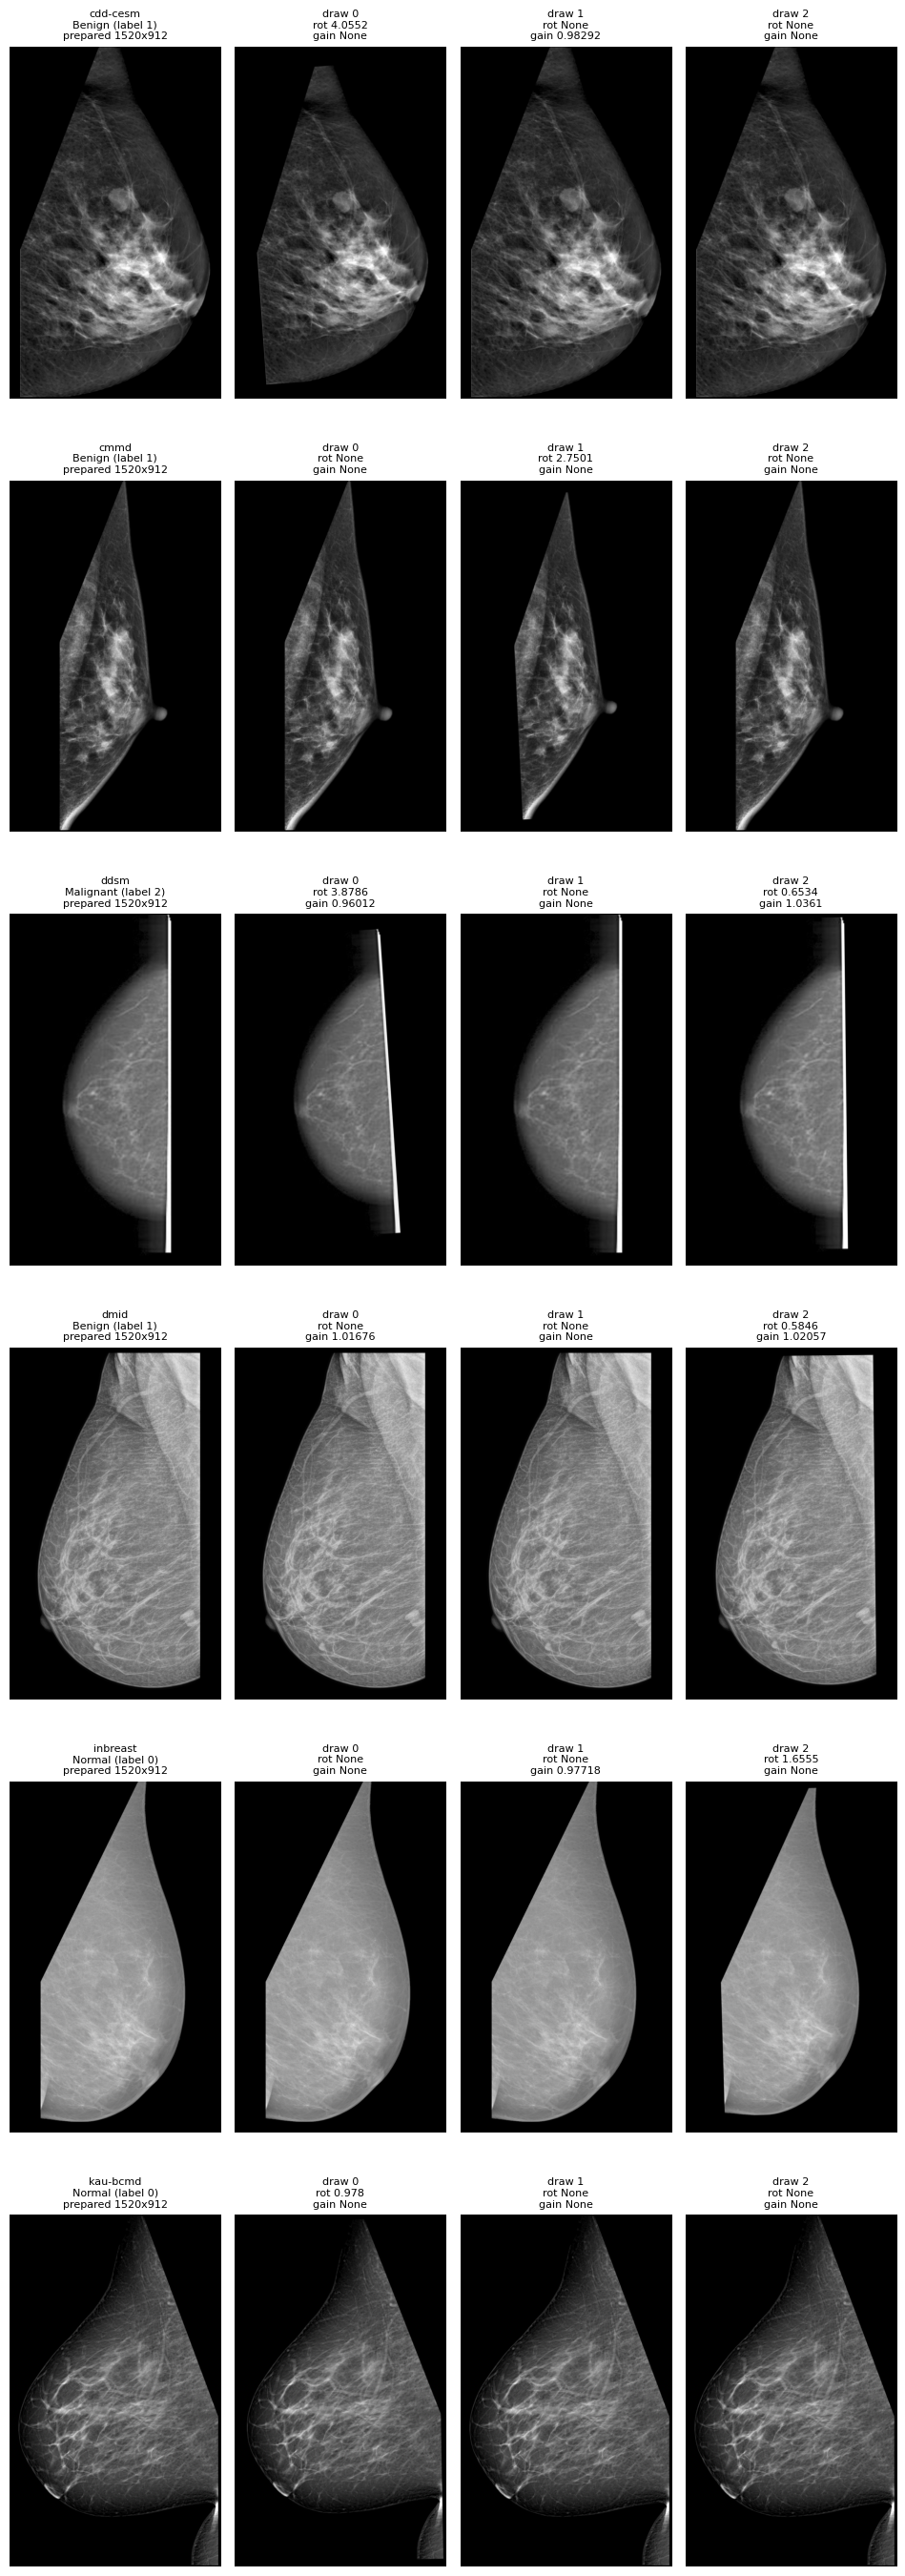

  source  draw  rotation    gain  shape_ok  dtype_ok  coverage_original  coverage_augmented  coverage_ratio  coverage_expected  coverage_matches_geometry  background_preserved
cdd-cesm     0    4.0552     NaN      True      True             0.6000              0.4826          0.8043             0.8038                       True                  True
cdd-cesm     1       NaN 0.98292      True      True             0.6000              0.6000          1.0000             1.0000                       True                  True
cdd-cesm     2       NaN     NaN      True      True             0.6000              0.6000          1.0000             1.0000                       True                  True
    cmmd     0       NaN     NaN      True      True             0.2740              0.2740          1.0000             1.0000                       True                  True
    cmmd     1    2.7501     NaN      True      True             0.2740              0.2365          0.8630             

In [14]:
PREVIEW_PROFILE = 'mild'
PREVIEW_DRAWS = 3
PREVIEW_SEED = 20260910

_sources = sorted(TRAIN_DF.source_dataset.astype(str).unique())
_rows = []
for _src in _sources:
    _sub = TRAIN_DF[TRAIN_DF.source_dataset.astype(str) == _src].sort_values('image_id')
    if len(_sub):
        _rows.append(_sub.iloc[0])

if _rows:
    fig, axes = plt.subplots(len(_rows), PREVIEW_DRAWS + 1,
                             figsize=(2.4 * (PREVIEW_DRAWS + 1), 4.6 * len(_rows)))
    axes = np.atleast_2d(axes)
    PREVIEW_CHECKS = []
    for _r, _row in enumerate(_rows):
        _orig8 = adapt_geometry(PREP.decode_bytes(open(_row.prepared_path, 'rb').read()))
        _orig_cover = float((_orig8 > 0).mean())
        axes[_r, 0].imshow(_orig8, cmap='gray', vmin=0, vmax=255)
        axes[_r, 0].set_title(f'{_row.source_dataset}\n{_row.label_text} '
                              f'(label {int(_row.label)})\nprepared '
                              f'{_orig8.shape[0]}x{_orig8.shape[1]}', fontsize=8)
        axes[_r, 0].axis('off')
        for _d in range(PREVIEW_DRAWS):
            _rng = sample_rng(PREVIEW_SEED, _d, _r)
            _aug8, _applied = augment_grayscale(_orig8, PREVIEW_PROFILE, _rng)
            _cover = float((_aug8 > 0).mean())
            _bg_ok = True
            if _applied['gain'] is not None and _applied['rotation'] is None:
                _bg_ok = bool(((_orig8 == 0) & (_aug8 != 0)).sum() == 0)
            _ratio = _cover / max(_orig_cover, 1e-9)
            _expected = (1.0 if _applied['rotation'] is None
                         else expected_rotation_area_ratio(MODEL_H, MODEL_W,
                                                           _applied['rotation']))
            PREVIEW_CHECKS.append({
                'source': str(_row.source_dataset), 'draw': _d,
                'label_unchanged': True,
                'shape_ok': _aug8.shape == (MODEL_H, MODEL_W),
                'dtype_ok': _aug8.dtype == np.uint8,
                'coverage_original': round(_orig_cover, 4),
                'coverage_augmented': round(_cover, 4),
                'coverage_ratio': round(_ratio, 4),
                'coverage_expected': round(_expected, 4),
                'coverage_matches_geometry': bool(abs(_ratio - _expected) < 0.10),
                'background_preserved': _bg_ok,
                'rotation': _applied['rotation'], 'gain': _applied['gain'],
            })
            axes[_r, _d + 1].imshow(_aug8, cmap='gray', vmin=0, vmax=255)
            axes[_r, _d + 1].set_title(
                f'draw {_d}\nrot {_applied["rotation"]}\ngain {_applied["gain"]}',
                fontsize=8)
            axes[_r, _d + 1].axis('off')
    plt.tight_layout()
    plt.show()

    PREVIEW = pd.DataFrame(PREVIEW_CHECKS)
    print(PREVIEW[['source', 'draw', 'rotation', 'gain', 'shape_ok', 'dtype_ok',
                   'coverage_original', 'coverage_augmented', 'coverage_ratio',
                   'coverage_expected', 'coverage_matches_geometry',
                   'background_preserved']].to_string(index=False))
    print(f'\nall outputs {MODEL_H}x{MODEL_W}: {bool(PREVIEW.shape_ok.all())}')
    print(f'all outputs uint8: {bool(PREVIEW.dtype_ok.all())}')
    print(f'black background preserved under gain-only draws: '
          f'{bool(PREVIEW.background_preserved.all())}')
    print(f'coverage matches the predicted geometry in every draw: '
          f'{bool(PREVIEW.coverage_matches_geometry.all())}')
    print('\nA rotated draw covers FEWER foreground pixels than the original, and that is '
          'expected rather than a loss: the canvas expands to the rotated bounding box and '
          'is then fitted back proportionally, so every pixel survives at a smaller scale. '
          'coverage_expected is that scale squared, computed analytically from the angle. '
          'A ratio matching it is the evidence nothing was cropped; a ratio well below it '
          'would mean tissue really was cut away.')
    print('labels are never touched by augmentation - only pixels are transformed')
else:
    print('no training rows available to preview')

## 5. Dataset, loaders, and the physical batch size

Prepared inputs are decoded, geometry-verified, augmented in memory when a profile is active,
converted to a tensor and normalised once. **The prepared files on disk are never modified.**

At 1520×912 one float32 sample is about 16.6 MB, four times the demo's 760×456, so loader
prefetch depth is kept modest to protect host memory.

In [15]:
class PreparedDataset(Dataset):
    """Reads the already-prepared images at their native resolution.

    Decoding comes from the pinned module; geometry is verified by adapt_geometry and
    passed through. prepare_raw and prepare_baseline are never called - the first would
    re-run breast cropping, the second asserts the provenance module's own target.

    `augment` names a profile from AUGMENTATION_PROFILES. `set_epoch` changes the
    augmentation draw deterministically: the same (seed, epoch, index) always produces the
    same transform, which is what makes an epoch-boundary resume reproducible.
    """

    def __init__(self, frame: pd.DataFrame, augment: str = 'none', seed: int = 42,
                 epoch: int = 0):
        if augment not in AUGMENTATION_PROFILES:
            raise ValueError(f'unknown augmentation profile {augment!r}')
        self.paths = frame.prepared_path.tolist()
        self.labels = frame.label.astype(int).tolist()
        self.augment = augment
        self.seed = int(seed)
        self.epoch = int(epoch)

    def set_epoch(self, epoch: int) -> None:
        self.epoch = int(epoch)

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        with open(self.paths[index], 'rb') as fh:
            img8 = PREP.decode_bytes(fh.read())
        img8 = adapt_geometry(img8)
        if self.augment != 'none':
            img8, _ = augment_grayscale(img8, self.augment,
                                        sample_rng(self.seed, self.epoch, index))
        tensor = torch.from_numpy(to_normalised_tensor(img8))
        return tensor, self.labels[index], index


def worker_init(worker_id: int) -> None:
    """Documented deterministic worker seeding, derived from the torch base seed."""
    base = torch.initial_seed() % (2 ** 31 - 1)
    np.random.seed((base + worker_id) % (2 ** 31 - 1))
    random.seed(base + worker_id)


def make_loader(frame: pd.DataFrame, batch_size: int, shuffle: bool,
                augment: str = 'none', seed: int = 42, epoch: int = 0,
                num_workers: Optional[int] = None,
                persistent: bool = False) -> DataLoader:
    """Loader with pinned memory on CUDA. prefetch/persistent only when workers > 0.

    Shuffling uses a generator seeded from (seed, epoch), which is the deterministic
    epoch-seeding scheme recorded in every checkpoint.
    """
    workers = N_WORKERS if num_workers is None else int(num_workers)
    dataset = PreparedDataset(frame, augment=augment, seed=seed, epoch=epoch)
    kwargs: Dict[str, Any] = {
        'batch_size': int(batch_size),
        'shuffle': bool(shuffle),
        'num_workers': workers,
        'pin_memory': ON_CUDA,
        'drop_last': False,
    }
    if workers > 0:
        kwargs['prefetch_factor'] = PREFETCH_FACTOR
        kwargs['persistent_workers'] = bool(persistent)
        kwargs['worker_init_fn'] = worker_init
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(int(seed) * 100003 + int(epoch))
        kwargs['generator'] = generator
    return DataLoader(dataset, **kwargs)


_sample_mb = N_CHANNELS * MODEL_H * MODEL_W * 4 / 1e6
print(f'one normalised sample: {N_CHANNELS} x {MODEL_H} x {MODEL_W} float32 = '
      f'{_sample_mb:.1f} MB')
print(f'loader workers {N_WORKERS}, prefetch factor {PREFETCH_FACTOR}, pinned memory '
      f'{ON_CUDA}')

one normalised sample: 3 x 1520 x 912 float32 = 16.6 MB
loader workers 8, prefetch factor 2, pinned memory True


### 5.1 Preflight checks

Three brief checks, in one cell: a real prepared input, the pretrained checkpoint loading into
a model that runs a forward pass, and the physical batch size that fits **at 1520×912**.

These checks write no checkpoint, no history and no `result.json`, so they cannot produce a
trainable or selectable outcome. Every probe tensor and graph is released between attempts,
and the model, optimiser and random seeds are reinitialised afterwards.

If batch size 1 does not fit, the notebook stops. It does not reduce the image resolution to
make training fit — that would silently change the model-input contract.

In [16]:
PREFLIGHT: Dict[str, Any] = {'wrote_checkpoint': False, 'wrote_result': False}

# ---- 1. input check, on a real prepared image --------------------------------------
_probe_ds = PreparedDataset(TRAIN_DF.head(1))
_x, _y, _i = _probe_ds[0]
if tuple(_x.shape) != (N_CHANNELS, MODEL_H, MODEL_W):
    raise RuntimeError(f'sample tensor {tuple(_x.shape)}, expected '
                       f'{(N_CHANNELS, MODEL_H, MODEL_W)}')
_recovered = [_x[c] * NORM_STD[c] + NORM_MEAN[c] for c in range(N_CHANNELS)]
PREFLIGHT['input'] = {
    'shape': list(_x.shape),
    'dtype': str(_x.dtype),
    'value_range': [round(float(_x.min()), 4), round(float(_x.max()), 4)],
    'label': int(_y),
    'label_name': CLASSES[int(_y)],
    'channels_identical': bool(all(
        torch.allclose(_recovered[0], _recovered[c], atol=1e-6)
        for c in range(1, N_CHANNELS))),
    'geometry_adapter': GEOMETRY_ADAPTER,
    'model_input_version': MODEL_INPUT_VERSION,
}
print('input check')
print(json.dumps(PREFLIGHT['input'], indent=2))
if not PREFLIGHT['input']['channels_identical']:
    raise RuntimeError('the three channels are not identical after de-normalisation; '
                       'grayscale replication is broken')
del _probe_ds, _x, _y, _i, _recovered

# ---- 2. checkpoint-loading check --------------------------------------------------
_check_model = build_model(head_dropout=0.0)
_n_probe = set_requires_grad(_check_model, 'probe')
_n_ft = set_requires_grad(_check_model, 'finetune')
set_training_modes(_check_model, 'finetune', False)
_bn_before = {k: v.clone() for k, v in _check_model.backbone.state_dict().items()
              if k.endswith('running_mean') or k.endswith('running_var')}
with torch.no_grad():
    _tiny = torch.zeros(1, N_CHANNELS, 64, 64, device=DEVICE)
    _logits = _check_model(_tiny)
_bn_unchanged = all(torch.equal(_bn_before[k], v)
                    for k, v in _check_model.backbone.state_dict().items()
                    if k in _bn_before)
PREFLIGHT['checkpoint'] = {
    'encoder_sha256': FM_SHA256,
    'params_covered': int(len(COVERED)),
    'params_reference': int(len(REF_KEYS)),
    'absent_allowed': ABSENT,
    'feat_dim': int(FEAT_DIM),
    'state_dict_entries': int(len(_check_model.state_dict())),
    'trainable_probe': int(_n_probe),
    'trainable_finetune': int(_n_ft),
    'forward_pass_logits': [round(v, 5) for v in _logits.float().cpu().numpy()[0].tolist()],
    'head_bias_from_prevalence': [round(v, 5) for v in
                                  _check_model.head.bias.detach().cpu().numpy().tolist()],
    'batchnorm_stats_unchanged_in_eval': bool(_bn_unchanged),
}
print('\ncheckpoint-loading check')
print(json.dumps(PREFLIGHT['checkpoint'], indent=2))
if not _bn_unchanged:
    raise RuntimeError('BatchNorm running statistics moved during an eval forward pass')
del _check_model, _bn_before, _tiny, _logits
free_cuda()

# ---- 3. memory check, at the real training resolution ----------------------------
def probe_micro_batch(head_dropout: float = 0.0) -> Dict[str, Any]:
    """Largest micro-batch from MICRO_BATCH_CHOICES that fits, measured at MODEL_H x MODEL_W.

    One real forward, backward, clip and optimiser step per attempt, at the fine-tune
    stage because it is the heavier of the two. Every tensor and autograd graph is
    released before the next attempt.
    """
    if not ON_CUDA:
        return {'micro_batch': min(MICRO_BATCH_CHOICES), 'measured': False,
                'resolution': [MODEL_H, MODEL_W],
                'note': 'no CUDA device - smallest choice used, nothing measured'}
    total = torch.cuda.get_device_properties(0).total_memory
    limit = MEMORY_HEADROOM_FRAC * total
    attempts: List[Dict[str, Any]] = []
    chosen = None
    for size in MICRO_BATCH_CHOICES:
        free_cuda()
        model = None
        optimiser = None
        scaler = None
        xb = yb = loss = logits = None
        try:
            model = build_model(head_dropout=head_dropout)
            set_requires_grad(model, 'finetune')
            set_training_modes(model, 'finetune', True)
            groups, _ = param_groups(model, head_lr=1e-4, encoder_lr=1e-5,
                                     weight_decay=1e-4)
            optimiser = AdamW(groups, betas=(0.9, 0.999), eps=1e-8)
            scaler = torch.amp.GradScaler('cuda', enabled=USE_SCALER)
            xb = torch.randn(size, N_CHANNELS, MODEL_H, MODEL_W, device=DEVICE)
            yb = torch.zeros(size, dtype=torch.long, device=DEVICE)
            with torch.autocast('cuda', dtype=AMP_DTYPE, enabled=USE_AMP):
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)
            if scaler.is_enabled():
                scaler.scale(loss).backward()
                scaler.unscale_(optimiser)
                torch.nn.utils.clip_grad_norm_(
                    [p for g in optimiser.param_groups for p in g['params']], GRAD_CLIP)
                scaler.step(optimiser)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for g in optimiser.param_groups for p in g['params']], GRAD_CLIP)
                optimiser.step()
            torch.cuda.synchronize()
            peak = torch.cuda.max_memory_reserved()
            fits = bool(peak <= limit)
            attempts.append({'micro_batch': size, 'peak_gb': round(peak / 1e9, 2),
                             'accumulation': EFFECTIVE_BATCH // size,
                             'fits_with_headroom': fits})
            if fits and chosen is None:
                chosen = size
        except torch.cuda.OutOfMemoryError:
            attempts.append({'micro_batch': size, 'peak_gb': None,
                             'accumulation': EFFECTIVE_BATCH // size,
                             'fits_with_headroom': False, 'note': 'out of memory'})
        finally:
            # Release the graph before the parameters, then the allocator cache.
            del loss, logits, xb, yb
            if optimiser is not None:
                optimiser.zero_grad(set_to_none=True)
            del optimiser, scaler, model
            free_cuda()
        if chosen is not None:
            break
    return {'micro_batch': chosen, 'measured': True, 'attempts': attempts,
            'resolution': [MODEL_H, MODEL_W],
            'total_gb': round(total / 1e9, 1), 'headroom_frac': MEMORY_HEADROOM_FRAC,
            'choices': list(MICRO_BATCH_CHOICES)}


if MICRO_BATCH_OVERRIDE:
    MEMORY_PROBE = {'micro_batch': int(MICRO_BATCH_OVERRIDE), 'measured': False,
                    'resolution': [MODEL_H, MODEL_W],
                    'note': 'MICRO_BATCH_OVERRIDE set in the configuration cell'}
else:
    MEMORY_PROBE = probe_micro_batch()
print(f'\nmemory check at {MODEL_H}x{MODEL_W}')
print(json.dumps(MEMORY_PROBE, indent=2))

if MEMORY_PROBE.get('micro_batch') is None:
    print(f'\nNo physical batch size in {list(MICRO_BATCH_CHOICES)} fits inside '
          f'{MEMORY_HEADROOM_FRAC:.0%} of '
          f'{MEMORY_PROBE.get("total_gb")} GB at {MODEL_H}x{MODEL_W}.')
    print('Stopping. Reducing the image resolution to make training fit would silently '
          f'change the model-input contract {MODEL_INPUT_VERSION}, so it is not done here. '
          'Options, in order of preference: use a GPU with more memory; enable gradient '
          'checkpointing on the encoder; or re-declare the contract at a lower resolution '
          'deliberately, which bumps its hash and invalidates every cached result.')
    raise SystemExit(f'no micro-batch fits at {MODEL_H}x{MODEL_W}')

MICRO_BATCH = int(MEMORY_PROBE['micro_batch'])
if EFFECTIVE_BATCH % MICRO_BATCH != 0:
    raise RuntimeError(f'micro-batch {MICRO_BATCH} does not divide the effective batch '
                       f'{EFFECTIVE_BATCH}')
ACCUM_STEPS = EFFECTIVE_BATCH // MICRO_BATCH
VAL_BATCH = int(VAL_BATCH_OVERRIDE) if VAL_BATCH_OVERRIDE else MICRO_BATCH
PREFLIGHT['memory'] = MEMORY_PROBE
PREFLIGHT['micro_batch'] = MICRO_BATCH
PREFLIGHT['accum_steps'] = ACCUM_STEPS
PREFLIGHT['val_batch'] = VAL_BATCH

# ---- teardown: reinitialise model, optimiser and seeds --------------------------
free_cuda()
seed_everything(BASE_SEED)
PREFLIGHT['reinitialised_after_memory_check'] = {
    'cuda_cache_released': True,
    'seeds_reset_to': BASE_SEED,
    'note': ('every model and optimiser built above has been discarded; run_trial builds '
             'a fresh model from the original pretrained encoder and re-seeds per trial'),
}
atomic_json_dump(PREFLIGHT, f'{LOCAL_REPORTS}/preflight.json')

print(f'\nmicro-batch {MICRO_BATCH} x accumulation {ACCUM_STEPS} = effective '
      f'{MICRO_BATCH * ACCUM_STEPS} (target {EFFECTIVE_BATCH})')
print(f'validation batch {VAL_BATCH} - configured separately, not derived by doubling')
print(f'preflight wrote no checkpoint and no result: '
      f'{not PREFLIGHT["wrote_checkpoint"] and not PREFLIGHT["wrote_result"]}')
print(f'model, optimiser and seeds reinitialised (seed {BASE_SEED}); nothing above can '
      'become a selectable training result')

input check
{
  "shape": [
    3,
    1520,
    912
  ],
  "dtype": "torch.float32",
  "value_range": [
    -2.1179,
    2.5703
  ],
  "label": 0,
  "label_name": "Normal",
  "channels_identical": true,
  "geometry_adapter": "passthrough-v2",
  "model_input_version": "model-input/2"
}

checkpoint-loading check
{
  "encoder_sha256": "58ae959de52d563acc1d43f50571498eddcd4fb7ca599e706540fdd319e3599b",
  "params_covered": 852,
  "params_reference": 854,
  "absent_allowed": [
    "_fc.bias",
    "_fc.weight"
  ],
  "feat_dim": 2048,
  "state_dict_entries": 856,
  "trainable_probe": 6147,
  "trainable_finetune": 30395931,
  "forward_pass_logits": [
    -1.58305,
    -0.80819,
    -0.56762
  ],
  "head_bias_from_prevalence": [
    -1.31781,
    -1.16136,
    -0.86936
  ],
  "batchnorm_stats_unchanged_in_eval": true
}

memory check at 1520x912
{
  "micro_batch": 8,
  "measured": true,
  "attempts": [
    {
      "micro_batch": 32,
      "peak_gb": null,
      "accumulation": 1,
      "fits_wit

## 6. Evaluation, losses and the learning-rate policy

### 6.1 Metrics

Per epoch: macro-F1 and accuracy, per-class precision / recall / F1 / support,
malignant-versus-rest ROC-AUC and average precision, and cross-entropy loss. Metrics are also
reported per source dataset, with any undefined value returned as `None` and marked with the
reason rather than filled with a zero.

In [17]:
def cross_entropy_from_logits(logits: np.ndarray, y: np.ndarray) -> float:
    """Mean cross-entropy in nats, computed stably from raw logits."""
    z = logits - logits.max(axis=1, keepdims=True)
    log_probs = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
    return float(-log_probs[np.arange(len(y)), y].mean())


def softmax_np(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    z = logits.astype(np.float64) / float(temperature)
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def malignant_vs_rest(probs: np.ndarray, y: np.ndarray) -> Dict[str, Any]:
    """Malignant-versus-rest AUC and AP, or an explicit undefined marker."""
    positive = (y == 2).astype(int)
    if positive.sum() == 0 or (1 - positive).sum() == 0:
        return {'roc_auc': None, 'average_precision': None,
                'prevalence': float(positive.mean()) if len(positive) else None,
                'undefined_reason': 'only one class present in this subset'}
    return {'roc_auc': float(roc_auc_score(positive, probs[:, 2])),
            'average_precision': float(average_precision_score(positive, probs[:, 2])),
            'prevalence': float(positive.mean())}


def compute_metrics(logits: np.ndarray, y: np.ndarray,
                    sources: Optional[np.ndarray] = None,
                    temperature: float = 1.0) -> Dict[str, Any]:
    """Every metric this notebook reports, from raw logits and integer labels."""
    probs = softmax_np(logits, temperature)
    pred = probs.argmax(axis=1)
    precision, recall, f1, support = precision_recall_fscore_support(
        y, pred, labels=[0, 1, 2], zero_division=0)
    out: Dict[str, Any] = {
        'n_images': int(len(y)),
        'accuracy': float((pred == y).mean()),
        'macro_f1': float(f1_score(y, pred, average='macro', zero_division=0)),
        'cross_entropy': cross_entropy_from_logits(logits / float(temperature), y),
        'per_class': {
            CLASSES[i]: {'precision': float(precision[i]), 'recall': float(recall[i]),
                         'f1': float(f1[i]), 'support': int(support[i])}
            for i in range(3)
        },
        'confusion_matrix': confusion_matrix(y, pred, labels=[0, 1, 2]).tolist(),
        'malignant_vs_rest': malignant_vs_rest(probs, y),
        'temperature_applied': float(temperature),
    }
    out['benign_f1'] = out['per_class']['Benign']['f1']
    if sources is not None:
        by_source: Dict[str, Any] = {}
        for name in sorted(set(map(str, sources))):
            mask = np.asarray([str(s) == name for s in sources])
            if mask.sum() == 0:
                continue
            ys, ps = y[mask], probs[mask]
            preds = ps.argmax(axis=1)
            present = sorted(set(ys.tolist()))
            entry: Dict[str, Any] = {
                'n_images': int(mask.sum()),
                'classes_present': [CLASSES[c] for c in present],
                'accuracy': float((preds == ys).mean()),
                'macro_f1': (float(f1_score(ys, preds, average='macro', zero_division=0))
                             if len(present) > 1 else None),
                'malignant_vs_rest': malignant_vs_rest(ps, ys),
            }
            if entry['macro_f1'] is None:
                entry['macro_f1_undefined_reason'] = (
                    f'only one class present ({entry["classes_present"]}), macro-F1 over '
                    'three classes is not defined for this subset')
            by_source[name] = entry
        out['by_source'] = by_source
    return out


@torch.no_grad()
def predict(model: MammoFM3C, frame: pd.DataFrame, stage: str,
            batch_size: Optional[int] = None) -> Dict[str, np.ndarray]:
    """Deterministic inference over one partition. Returns raw logits, labels, indices.

    The model is put in eval mode through set_training_modes, so BatchNorm running
    statistics cannot move: torch.no_grad() alone would not prevent that.
    """
    set_training_modes(model, stage, False)
    loader = make_loader(frame, batch_size or VAL_BATCH, shuffle=False, augment='none')
    logits_chunks, label_chunks, index_chunks = [], [], []
    for xb, yb, ib in tqdm(loader, desc='eval', leave=False):
        with torch.autocast('cuda', dtype=AMP_DTYPE, enabled=USE_AMP):
            out = model(xb.to(DEVICE, non_blocking=True))
        logits_chunks.append(out.float().cpu())
        label_chunks.append(yb)
        index_chunks.append(ib)
    return {
        'logits': torch.cat(logits_chunks).numpy().astype(np.float64),
        'y': torch.cat(label_chunks).numpy().astype(int),
        'index': torch.cat(index_chunks).numpy().astype(int),
    }


def evaluate_frame(model: MammoFM3C, frame: pd.DataFrame, stage: str,
                   temperature: float = 1.0,
                   with_sources: bool = True) -> Tuple[Dict[str, Any], Dict[str, np.ndarray]]:
    raw = predict(model, frame, stage)
    sources = (frame.source_dataset.astype(str).to_numpy()[raw['index']]
               if with_sources else None)
    return compute_metrics(raw['logits'], raw['y'], sources, temperature), raw


print('metrics per epoch: macro-F1, accuracy, per-class P/R/F1/support, malignant-vs-rest '
      'ROC-AUC and AP, cross-entropy, and the same broken down by source dataset')
print(f'primary selection metric: validation {SELECTION_METRIC} - fixed before any results '
      'are seen and not changed afterwards')
print('reported alongside it, never instead of it: malignant AUC and Benign F1')

metrics per epoch: macro-F1, accuracy, per-class P/R/F1/support, malignant-vs-rest ROC-AUC and AP, cross-entropy, and the same broken down by source dataset
primary selection metric: validation macro_f1 - fixed before any results are seen and not changed afterwards
reported alongside it, never instead of it: malignant AUC and Benign F1


### 6.2 Loss

Ordinary cross-entropy with natural shuffled sampling is the default. The optional weighted
variant uses `w[c] ∝ sqrt(N / (3 · n_c))` from **training-only** class counts, normalised so
the weights average to 1. Both return a loss *sum* and a weight *sum* per micro-batch, so
gradient accumulation divides by the true total weight of the accumulated group — the plain
case being the special case where every weight is 1 and the denominator is the sample count.

In [18]:
def sqrt_balanced_weights(class_counts: np.ndarray) -> np.ndarray:
    """w[c] proportional to sqrt(N / (3 * count[c])), normalised to mean 1."""
    counts = np.clip(np.asarray(class_counts, dtype=np.float64), 1.0, None)
    total = counts.sum()
    raw = np.sqrt(total / (3.0 * counts))
    return raw / raw.mean()


CLASS_WEIGHTS_SQRT = sqrt_balanced_weights(TRAIN_CLASS_COUNTS)
CLASS_WEIGHT_RECORD = {
    'formula': 'w[c] = sqrt(N / (3 * count[c])), then normalised to mean 1',
    'training_counts': [int(c) for c in TRAIN_CLASS_COUNTS],
    'weights': {CLASSES[i]: float(CLASS_WEIGHTS_SQRT[i]) for i in range(3)},
    'note': ('training-only counts; never combined with class oversampling; source-balanced '
             'sampling and Group DRO are separate experiments and are not implemented here'),
}
print(json.dumps(CLASS_WEIGHT_RECORD, indent=2))


def loss_sums(logits: torch.Tensor, target: torch.Tensor,
              weight_vector: Optional[torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor]:
    """(weighted loss sum, total weight) for one micro-batch.

    Unweighted: the weight of every sample is 1, so the total weight IS the sample count
    and dividing gradients by it gives the mean loss for the accumulated group, including
    a final partial group.
    """
    if weight_vector is None:
        total = torch.tensor(float(target.numel()), device=logits.device,
                             dtype=torch.float32)
        return F.cross_entropy(logits, target, reduction='sum'), total
    per_sample = F.cross_entropy(logits, target, reduction='none')
    weights = weight_vector.to(logits.device)[target]
    return (per_sample * weights).sum(), weights.sum()

{
  "formula": "w[c] = sqrt(N / (3 * count[c])), then normalised to mean 1",
  "training_counts": [
    3112,
    3639,
    4873
  ],
  "weights": {
    "Normal": 1.1013632030550715,
    "Benign": 1.018496002598254,
    "Malignant": 0.8801407943466742
  },
  "note": "training-only counts; never combined with class oversampling; source-balanced sampling and Group DRO are separate experiments and are not implemented here"
}


### 6.3 Learning-rate policy

Fine-tuning warms up linearly over the first three epochs, then hands control to
`ReduceLROnPlateau` on validation macro-F1 (`mode='max'`, `factor=0.5`, `patience=3`,
`threshold=0.001`, `threshold_mode='abs'`) with per-group floors of 1e-7 for encoder groups
and 1e-6 for classifier groups. Cosine is available as an explicit comparison configuration.
The two are mutually exclusive and the class refuses to build both.

In [19]:
class LrPolicy:
    """Warm-up plus exactly one of plateau or cosine. Fully resumable.

    `before_update(i)` sets the learning rates used by optimiser update `i`; during warm-up
    that is a linear ramp, under cosine it is the cosine value, and under plateau after
    warm-up it leaves the rates alone because the plateau scheduler owns them.
    `after_epoch(metric, epoch)` steps the plateau scheduler, and only after warm-up so the
    warm-up epochs are not counted against its patience.
    """

    def __init__(self, optimiser: torch.optim.Optimizer, kind: str,
                 group_names: Sequence[str], warmup_updates: int, total_updates: int,
                 plateau_factor: float = 0.5, plateau_patience: int = 3,
                 plateau_threshold: float = 1e-3, cosine_final_frac: float = 0.01,
                 warmup_epochs: int = 0):
        if kind not in ('plateau', 'cosine'):
            raise ValueError(f'unknown schedule {kind!r}; use "plateau" or "cosine"')
        self.optimiser = optimiser
        self.kind = kind
        self.group_names = list(group_names)
        self.base_lrs = [float(g['lr']) for g in optimiser.param_groups]
        self.min_lrs = [float(GROUP_MIN_LR[name]) for name in self.group_names]
        self.warmup_updates = max(0, int(warmup_updates))
        self.warmup_epochs = int(warmup_epochs)
        self.total_updates = max(1, int(total_updates))
        self.cosine_final_frac = float(cosine_final_frac)
        self.update_index = 0
        self.plateau = None
        if kind == 'plateau':
            self.plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimiser, mode='max', factor=float(plateau_factor),
                patience=int(plateau_patience), threshold=float(plateau_threshold),
                threshold_mode='abs', min_lr=self.min_lrs)

    def _apply(self, factors: Sequence[float]) -> None:
        for group, base, floor, factor in zip(self.optimiser.param_groups, self.base_lrs,
                                              self.min_lrs, factors):
            group['lr'] = max(floor, base * float(factor))

    def before_update(self, update_index: int) -> None:
        self.update_index = int(update_index)
        if self.warmup_updates > 0 and update_index < self.warmup_updates:
            factor = (update_index + 1) / float(self.warmup_updates)
            self._apply([factor] * len(self.base_lrs))
            return
        if self.kind == 'cosine':
            span = max(1, self.total_updates - self.warmup_updates)
            progress = min(1.0, (update_index - self.warmup_updates) / float(span))
            factor = (self.cosine_final_frac + (1.0 - self.cosine_final_frac)
                      * 0.5 * (1.0 + math.cos(math.pi * progress)))
            self._apply([factor] * len(self.base_lrs))

    def after_epoch(self, metric: float, epoch_index: int) -> None:
        if self.plateau is None:
            return
        if epoch_index < self.warmup_epochs:
            return
        self.plateau.step(float(metric))

    def current_lrs(self) -> Dict[str, float]:
        return {name: float(group['lr'])
                for name, group in zip(self.group_names, self.optimiser.param_groups)}

    def state_dict(self) -> Dict[str, Any]:
        return {'kind': self.kind, 'group_names': self.group_names,
                'base_lrs': self.base_lrs, 'min_lrs': self.min_lrs,
                'warmup_updates': self.warmup_updates,
                'warmup_epochs': self.warmup_epochs,
                'total_updates': self.total_updates,
                'update_index': self.update_index,
                'cosine_final_frac': self.cosine_final_frac,
                'plateau': None if self.plateau is None else self.plateau.state_dict()}

    def load_state_dict(self, state: Dict[str, Any]) -> None:
        if state['kind'] != self.kind:
            raise RuntimeError(f'checkpoint schedule {state["kind"]} does not match the '
                               f'configured {self.kind}; refusing to resume')
        self.base_lrs = [float(v) for v in state['base_lrs']]
        self.min_lrs = [float(v) for v in state['min_lrs']]
        self.warmup_updates = int(state['warmup_updates'])
        self.warmup_epochs = int(state['warmup_epochs'])
        self.total_updates = int(state['total_updates'])
        self.update_index = int(state['update_index'])
        self.cosine_final_frac = float(state['cosine_final_frac'])
        if self.plateau is not None and state.get('plateau') is not None:
            self.plateau.load_state_dict(state['plateau'])


print('fine-tune schedule: 3 warm-up epochs -> ReduceLROnPlateau(max, 0.5, patience 3, '
      'threshold 0.001 absolute)')
print('floors: encoder groups 1e-7, classifier groups 1e-6')
print('cosine is a separate comparison configuration; plateau and cosine are never '
      'combined in one run')

fine-tune schedule: 3 warm-up epochs -> ReduceLROnPlateau(max, 0.5, patience 3, threshold 0.001 absolute)
floors: encoder groups 1e-7, classifier groups 1e-6
cosine is a separate comparison configuration; plateau and cosine are never combined in one run


## 7. Training

### 7.1 Trial configuration and checkpoint layout

One trial = one seed and one complete configuration, run as Stage A (linear probe) then
Stage B (full fine-tune). Each trial gets its own directory keyed by a configuration hash;
a directory whose recorded hash disagrees with the current configuration is refused rather
than reused, so no trial can overwrite another and the demo run is never touched.

In [20]:
TRIAL_DEFAULTS: Dict[str, Any] = {
    'seed': 42,
    'augment': 'none',
    'schedule': 'plateau',            # 'plateau' or 'cosine', never both
    'loss': 'cross_entropy',          # or 'weighted_cross_entropy'
    'head_dropout': 0.0,
    'weight_decay': 1e-4,
    'betas': [0.9, 0.999],
    'eps': 1e-8,
    # Stage A - linear probe
    'probe_epochs': 10,
    'probe_patience': 3,
    'probe_head_lr': 1e-3,
    # Stage B - full fine-tune
    'ft_epochs': 60,
    'ft_encoder_lr': 1e-5,
    'ft_head_lr': 1e-4,
    'ft_patience': 12,
    'ft_min_delta': 1e-3,
    'ft_min_epochs': 20,
    'warmup_mode': 'epochs',          # 'epochs' or 'fraction' (of total updates)
    'warmup_value': 3,
    'cosine_final_frac': 0.01,
    'plateau_factor': 0.5,
    'plateau_patience': 3,
    'plateau_threshold': 1e-3,
    'bn_stats_trainable': False,      # BatchNorm running stats frozen; affine still learns
}

STATIC_CONTEXT = {
    'model_input_version': MODEL_INPUT_VERSION,
    'model_input_hash': MODEL_INPUT_HASH,
    'model_input': [MODEL_H, MODEL_W],
    'geometry_adapter': GEOMETRY_ADAPTER,
    'data_hash': DATA_HASH,
    'split_hash': SPLIT_HASH,
    'split_file_sha256': SPLIT_FILE_SHA256,
    'preprocessing_sha256': PREP_SHA256,
    'encoder_sha256': FM_SHA256,
    'norm_mean': NORM_MEAN,
    'norm_std': NORM_STD,
    'effective_batch': EFFECTIVE_BATCH,
    'classes': CLASSES,
}
LOADER_SEEDING_SCHEME = ('shuffle generator seeded with seed*100003 + epoch; augmentation '
                         'draw from np.random.default_rng([seed, epoch, sample_index]); '
                         'workers seeded from torch.initial_seed() + worker_id')


def make_spec(name: str, **overrides: Any) -> Dict[str, Any]:
    """A complete trial spec: defaults, then the named overrides, validated."""
    unknown = sorted(set(overrides) - set(TRIAL_DEFAULTS))
    if unknown:
        raise KeyError(f'unknown trial setting(s) {unknown}; '
                       f'known: {sorted(TRIAL_DEFAULTS)}')
    spec = dict(TRIAL_DEFAULTS)
    spec.update(overrides)
    spec['name'] = name
    if spec['schedule'] not in ('plateau', 'cosine'):
        raise ValueError(f'schedule must be plateau or cosine, got {spec["schedule"]!r}')
    if spec['augment'] not in AUGMENTATION_PROFILES:
        raise ValueError(f'unknown augmentation profile {spec["augment"]!r}')
    if spec['loss'] not in ('cross_entropy', 'weighted_cross_entropy'):
        raise ValueError(f'unknown loss {spec["loss"]!r}')
    if spec['warmup_mode'] not in ('epochs', 'fraction'):
        raise ValueError(f'unknown warmup_mode {spec["warmup_mode"]!r}')
    return spec


def config_hash(spec: Dict[str, Any]) -> str:
    """Identity of one RUN: its settings, its seed, and the data it runs on.

    This is the cache key. The seed is part of it, because a different seed is a
    different run that has to be executed rather than reused.

    The physical micro-batch is deliberately excluded - it is a property of the GPU, not
    of the experiment, and two runs at different micro-batches with the same effective
    batch are the same configuration.
    """
    payload = {k: v for k, v in spec.items() if k != 'name'}
    payload['static'] = STATIC_CONTEXT
    return sha256_obj(payload)


def recipe_hash(spec: Dict[str, Any]) -> str:
    """Identity of a CONFIGURATION, independent of the seed.

    Multi-seed aggregation and final selection group by this. Grouping by config_hash
    would put every seed of one recipe in its own group of one, and no configuration
    would ever reach the multi-seed threshold.
    """
    payload = {k: v for k, v in spec.items() if k not in ('name', 'seed')}
    payload['static'] = STATIC_CONTEXT
    return sha256_obj(payload)


def trial_id(spec: Dict[str, Any], phase: str) -> str:
    return f'{phase}__{spec["name"]}__seed{spec["seed"]}__{recipe_hash(spec)[:10]}'


DEMO_RUN_DIRS = (f'{DRIVE_ROOT}/runs_demo_v1',)


def trial_dirs(tid: str, spec: Dict[str, Any], phase: str) -> Tuple[str, str]:
    """(local dir, Drive dir) for one trial, with the config-hash and demo-run guards."""
    local = f'{LOCAL_RUNS}/{tid}'
    remote = f'{OUT_ROOT}/{tid}'
    for protected in DEMO_RUN_DIRS:
        if os.path.abspath(remote).startswith(os.path.abspath(protected)):
            raise RuntimeError(f'refusing to write inside the demo run directory '
                               f'{protected}; change OUT_ROOT')
    os.makedirs(local, exist_ok=True)
    meta_path = f'{local}/meta.json'
    meta = {'trial_id': tid, 'phase': phase, 'spec': spec,
            'config_hash': config_hash(spec), 'recipe_hash': recipe_hash(spec),
            'static': STATIC_CONTEXT,
            'loader_seeding': LOADER_SEEDING_SCHEME, 'versions': VERSIONS}
    if os.path.exists(meta_path):
        existing = json.load(open(meta_path))
        if existing.get('config_hash') != meta['config_hash']:
            raise RuntimeError(
                f'{local} already holds trial {existing.get("trial_id")} with config hash '
                f'{str(existing.get("config_hash"))[:10]}, which differs from the current '
                f'{meta["config_hash"][:10]}. Refusing to overwrite another trial.')
    else:
        atomic_json_dump(meta, meta_path)
    return local, remote


def result_path(tid: str) -> str:
    return f'{LOCAL_RUNS}/{tid}/result.json'


CACHE_REJECTIONS: List[Dict[str, Any]] = []

REQUIRED_IDENTITY = (
    ('model_input_version', lambda: MODEL_INPUT_VERSION),
    ('model_input_hash', lambda: MODEL_INPUT_HASH),
    ('data_hash', lambda: DATA_HASH),
    ('preprocessing_sha256', lambda: PREP_SHA256),
    ('split_hash', lambda: SPLIT_HASH),
    ('encoder_sha256', lambda: FM_SHA256),
)


def result_is_compatible(payload: Any,
                         spec: Optional[Dict[str, Any]] = None) -> Tuple[bool, str]:
    """THE strict compatibility test. One function, used everywhere.

    The result cache, the experiment tables and the final selection all go through this,
    so a run can never be good enough to appear in a table but not good enough to reuse,
    or the reverse. It checks, in order:

      completion status  - the trial wrote a complete record
      stop reasons       - BOTH stages ended for a clean reason; an interrupted or errored
                           stage means the trial did not finish, whatever else it wrote
      data identity      - the dataset hash, which covers image identity, label and content
      preprocessing      - the pinned module hash
      model input        - the versioned contract and its hash
      split              - the partition hash, primary and auxiliary files included
      encoder            - the pretrained checkpoint hash

    `spec` is optional: pass it to additionally require the exact configuration hash.
    """
    if not isinstance(payload, dict):
        return False, f'not a result record ({type(payload).__name__})'
    if not payload.get('complete'):
        return False, 'the run did not finish (complete flag not set)'
    stops = payload.get('stop_reasons')
    if not isinstance(stops, dict) or not stops:
        return False, 'no per-stage stop reasons recorded'
    for stage in ('probe', 'finetune'):
        reason = stops.get(stage)
        if reason is None:
            return False, f'no stop reason recorded for the {stage} stage'
        if reason not in CLEAN_STOP_REASONS:
            return False, (f'the {stage} stage stopped with {reason!r}, which is not one '
                           f'of {list(CLEAN_STOP_REASONS)} - it did not finish')
    selected = payload.get('selected')
    if not isinstance(selected, dict) or selected.get('metric') is None:
        return False, 'no selected candidate recorded'
    stored = payload.get('static') or {}
    for field, current in REQUIRED_IDENTITY:
        theirs = stored.get(field)
        if theirs is None:
            return False, f'stored result records no {field}'
        mine = current()
        if theirs != mine:
            return False, (f'{field} differs: stored {str(theirs)[:16]}, '
                           f'current {str(mine)[:16]}')
    if spec is not None and payload.get('config_hash') != config_hash(spec):
        return False, (f'configuration hash {str(payload.get("config_hash"))[:10]} != '
                       f'{config_hash(spec)[:10]}')
    return True, 'compatible'


def read_result(path: str) -> Optional[Dict[str, Any]]:
    try:
        return json.load(open(path))
    except (json.JSONDecodeError, OSError) as exc:
        CACHE_REJECTIONS.append({'path': path, 'reason': f'unreadable: {exc}'})
        return None


def find_cached_result(spec: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    """Any finished, compatible run of THIS configuration, from ANY phase.

    Keyed by configuration hash, not by trial id, so a configuration first run in the LR
    search and re-declared in the weight-decay or multi-seed phase is reused rather than
    retrained. Every rejection is recorded with its reason.
    """
    wanted = config_hash(spec)
    for root in (LOCAL_RUNS, OUT_ROOT):
        if not os.path.isdir(root):
            continue
        for name in sorted(os.listdir(root)):
            path = f'{root}/{name}/result.json'
            if not os.path.exists(path):
                continue
            payload = read_result(path)
            if payload is None:
                continue
            if payload.get('config_hash') != wanted:
                continue
            ok, why = result_is_compatible(payload, spec)
            if ok:
                return payload
            CACHE_REJECTIONS.append({'path': path, 'trial_id': payload.get('trial_id'),
                                     'reason': why})
    return None


CHECKPOINT_FORMAT = 'mammofm-full-training-checkpoint/2'
CHECKPOINT_REQUIRED_KEYS = (
    'format', 'model', 'optimiser', 'scheduler', 'epoch', 'global_update', 'stage',
    'best', 'early_stop', 'history', 'rng', 'spec', 'trial_id', 'seed', 'config_hash',
    'model_input_hash', 'split_hash', 'data_hash', 'preprocessing_sha256',
    'encoder_sha256',
)


def copy_to_drive_verified(src: str, dst: str) -> Dict[str, Any]:
    """Write to Drive through a temporary file, verify the checksum, then replace.

    Drive writes are the least reliable step in this notebook: a disconnect halfway
    through leaves a truncated file that torch.load will happily half-read. So the bytes
    go to `<dst>.part` first, the copy's SHA-256 is compared with the source's, and only
    a match is promoted to `dst`. A failed verification leaves the previous `dst`
    untouched and removes the partial file.
    """
    if not os.path.exists(src):
        return {'file': os.path.basename(dst), 'status': 'source missing'}
    os.makedirs(os.path.dirname(dst) or '.', exist_ok=True)
    src_sha = sha256_file(src)
    if os.path.exists(dst) and os.path.getsize(dst) == os.path.getsize(src):
        if sha256_file(dst) == src_sha:
            return {'file': os.path.basename(dst), 'status': 'already identical',
                    'sha256': src_sha}
    part = f'{dst}.part'
    try:
        shutil.copyfile(src, part)
        part_sha = sha256_file(part)
        if part_sha != src_sha or os.path.getsize(part) != os.path.getsize(src):
            raise RuntimeError(f'checksum mismatch after copy: {part_sha[:16]} != '
                               f'{src_sha[:16]}')
        os.replace(part, dst)
        final_sha = sha256_file(dst)
        if final_sha != src_sha:
            raise RuntimeError(f'checksum mismatch after replace: {final_sha[:16]} != '
                               f'{src_sha[:16]}')
        return {'file': os.path.basename(dst), 'status': 'written and verified',
                'sha256': src_sha, 'bytes': os.path.getsize(dst)}
    except Exception as exc:
        if os.path.exists(part):
            try:
                os.remove(part)
            except OSError:
                pass
        return {'file': os.path.basename(dst), 'status': f'FAILED: {exc}'}


def validate_checkpoint_file(path: str) -> Tuple[bool, str, Optional[Dict[str, Any]]]:
    """Load a checkpoint and check it is structurally whole and belongs to this run.

    A recovered file has crossed Drive, so it is not trusted until it loads, carries
    every required key, and matches this run's model-input contract, split, dataset and
    encoder. Anything else is reported and refused rather than resumed from.
    """
    if not os.path.exists(path):
        return False, 'file does not exist', None
    if os.path.getsize(path) == 0:
        return False, 'file is empty', None
    try:
        payload = torch.load(path, map_location='cpu', weights_only=False)
    except Exception as exc:
        return False, f'will not load ({type(exc).__name__}: {exc})', None
    if not isinstance(payload, dict):
        return False, f'not a checkpoint mapping ({type(payload).__name__})', None
    absent = [k for k in CHECKPOINT_REQUIRED_KEYS if k not in payload]
    if absent:
        return False, f'incomplete: missing {absent}', None
    if payload.get('format') != CHECKPOINT_FORMAT:
        return False, (f'format {payload.get("format")!r} is not '
                       f'{CHECKPOINT_FORMAT!r}'), None
    for field, current in (('model_input_hash', MODEL_INPUT_HASH),
                           ('split_hash', SPLIT_HASH),
                           ('data_hash', DATA_HASH),
                           ('preprocessing_sha256', PREP_SHA256),
                           ('encoder_sha256', FM_SHA256)):
        if payload.get(field) != current:
            return False, (f'{field} differs: checkpoint {str(payload.get(field))[:16]}, '
                           f'current {str(current)[:16]}'), None
    if not isinstance(payload.get('model'), dict) or not payload['model']:
        return False, 'the model state dict is empty', None
    return True, 'valid', payload


# ---- phase membership: which configurations each phase asked for ----------------
PHASE_MEMBERSHIP_FILE = 'phase_membership.json'


def phase_membership_paths() -> Tuple[str, str]:
    return (f'{LOCAL_RUNS}/{PHASE_MEMBERSHIP_FILE}',
            f'{OUT_ROOT}/{PHASE_MEMBERSHIP_FILE}')


def load_phase_membership() -> Dict[str, Dict[str, Any]]:
    """Every (phase, configuration) request recorded so far, local and Drive merged.

    Reusing a result keeps its ORIGINAL trial id and weights - it is not copied and not
    re-run - so without this record the reused configuration would be invisible to the
    phase that asked for it, and a phase comparison would silently omit its own winner.
    """
    merged: Dict[str, Dict[str, Any]] = {}
    local, remote = phase_membership_paths()
    for path in (remote, local):          # local last, so it wins on conflict
        if not os.path.exists(path):
            continue
        payload = read_result(path)
        if isinstance(payload, dict):
            for key, record in (payload.get('records') or {}).items():
                if isinstance(record, dict):
                    merged[key] = record
    return merged


def record_phase_membership(phase: str, spec: Dict[str, Any],
                            result: Dict[str, Any], reused: bool) -> Dict[str, Any]:
    """Record that `phase` requested this configuration, pointing at the one result.

    The record REFERENCES the original trial; it never copies weights and never becomes a
    second experiment. `reused` says whether this phase ran it or inherited it.
    """
    records = load_phase_membership()
    key = f'{phase}|{config_hash(spec)}'
    record = {
        'phase': phase,
        'config_hash': config_hash(spec),
        'recipe_hash': recipe_hash(spec),
        'spec_name': spec['name'],
        'seed': int(spec['seed']),
        'result_trial_id': result['trial_id'],
        'result_phase': result.get('phase'),
        'result_path': result_path(result['trial_id']),
        'reused': bool(reused),
        'recorded_at': time.strftime('%Y-%m-%d %H:%M:%S'),
        'model_input_hash': MODEL_INPUT_HASH,
        'split_hash': SPLIT_HASH,
        'data_hash': DATA_HASH,
    }
    records[key] = record
    local, remote = phase_membership_paths()
    atomic_json_dump({'records': records, 'updated_at': record['recorded_at']}, local)
    copy_to_drive_verified(local, remote)
    return record


def phase_member_hashes(phases: Sequence[str]) -> set:
    """Configuration hashes any of `phases` requested, however they were satisfied."""
    wanted = set(phases)
    out = set()
    for record in load_phase_membership().values():
        if record.get('phase') not in wanted:
            continue
        if record.get('model_input_hash') not in (None, MODEL_INPUT_HASH):
            continue
        if record.get('split_hash') not in (None, SPLIT_HASH):
            continue
        if record.get('data_hash') not in (None, DATA_HASH):
            continue
        out.add(record.get('config_hash'))
    return {h for h in out if h}


def recover_trial_from_drive(tid: str) -> Dict[str, Any]:
    """Pull a trial's state back from Drive, then VALIDATE every checkpoint recovered.

    A recycled Colab runtime loses /content entirely while the Drive copy survives, so
    this is what makes an interrupted trial resumable rather than restartable. Only files
    absent locally are fetched, so a local checkpoint newer than the mirror always wins.
    A recovered checkpoint that does not validate is removed again and reported, so
    training never resumes from a truncated or foreign file.
    """
    local = f'{LOCAL_RUNS}/{tid}'
    remote = f'{OUT_ROOT}/{tid}'
    report: Dict[str, Any] = {'pulled': [], 'validated': [], 'rejected': []}
    if not RECOVER_FROM_DRIVE or not os.path.isdir(remote):
        return report
    os.makedirs(local, exist_ok=True)
    for name in sorted(os.listdir(remote)):
        src = f'{remote}/{name}'
        dst = f'{local}/{name}'
        if os.path.isdir(src) or name.endswith(('.tmp', '.part')) or os.path.exists(dst):
            continue
        if copy_if_different(src, dst):
            report['pulled'].append(name)
    for name in list(report['pulled']):
        if not name.endswith('.pth'):
            continue
        ok, why, _ = validate_checkpoint_file(f'{local}/{name}')
        if ok:
            report['validated'].append(name)
        else:
            report['rejected'].append({'file': name, 'reason': why})
            try:
                os.remove(f'{local}/{name}')
            except OSError:
                pass
    if report['pulled']:
        print(f'  recovered from Drive: {report["pulled"]}')
    if report['validated']:
        print(f'  validated: {report["validated"]}')
    for item in report['rejected']:
        print(f'  REJECTED {item["file"]}: {item["reason"]} - removed, not resumed from')
    return report


def mirror_to_drive(tid: str, names: Sequence[str]) -> List[Dict[str, Any]]:
    """Copy named files up to Drive through the verified temp-then-replace path."""
    local = f'{LOCAL_RUNS}/{tid}'
    remote = f'{OUT_ROOT}/{tid}'
    os.makedirs(remote, exist_ok=True)
    out = []
    for name in names:
        src = f'{local}/{name}'
        if not os.path.exists(src):
            continue
        result = copy_to_drive_verified(src, f'{remote}/{name}')
        out.append(result)
        if str(result['status']).startswith('FAILED'):
            print(f'  WARNING: Drive write failed for {name}: {result["status"]}. The '
                  'previous Drive copy is untouched and the local file is still valid.')
    return out


def write_trial_status(tid: str, state: str, **extra: Any) -> None:
    """A small status file, mirrored immediately, so an interruption is visible on Drive."""
    payload = {'trial_id': tid, 'state': state,
               'updated_at': time.strftime('%Y-%m-%d %H:%M:%S'),
               'model_input_version': MODEL_INPUT_VERSION,
               'model_input': [MODEL_H, MODEL_W]}
    payload.update(extra)
    atomic_json_dump(payload, f'{LOCAL_RUNS}/{tid}/status.json')
    mirror_to_drive(tid, ['status.json'])


# ---- persisted stage completion -------------------------------------------------
def stage_state_path(tid: str) -> str:
    return f'{LOCAL_RUNS}/{tid}/stage_state.json'


def read_stage_state(tid: str, spec: Dict[str, Any]) -> Dict[str, Any]:
    """Which stages of this trial have already finished cleanly.

    Persisted so a stage that ended by early stopping is not silently re-run when the
    trial is resumed: its epochs are already spent and its best checkpoint is on disk.
    A record from a different configuration is discarded rather than trusted.
    """
    path = stage_state_path(tid)
    if not os.path.exists(path):
        return {}
    payload = read_result(path)
    if not isinstance(payload, dict):
        return {}
    if payload.get('config_hash') != config_hash(spec):
        print(f'  ignoring stage state from configuration '
              f'{str(payload.get("config_hash"))[:10]}')
        return {}
    if payload.get('model_input_hash') != MODEL_INPUT_HASH:
        print('  ignoring stage state from a different model-input contract')
        return {}
    return payload.get('stages') or {}


def write_stage_state(tid: str, spec: Dict[str, Any], stages: Dict[str, Any]) -> None:
    atomic_json_dump({'trial_id': tid, 'config_hash': config_hash(spec),
                      'model_input_hash': MODEL_INPUT_HASH,
                      'split_hash': SPLIT_HASH, 'data_hash': DATA_HASH,
                      'updated_at': time.strftime('%Y-%m-%d %H:%M:%S'),
                      'stages': stages}, stage_state_path(tid))
    mirror_to_drive(tid, ['stage_state.json'])


print(f'trial defaults:\n{json.dumps(TRIAL_DEFAULTS, indent=2)}')
print(f'\nstatic context: model input {MODEL_INPUT_VERSION} {MODEL_H}x{MODEL_W} '
      f'(hash {MODEL_INPUT_HASH[:10]}) | data {DATA_HASH[:10]} | split {SPLIT_HASH[:10]} '
      f'| prep {PREP_SHA256[:10]} | encoder {FM_SHA256[:10]}')
print(f'loader seeding: {LOADER_SEEDING_SCHEME}')
print(f'\nresults are written under {OUT_ROOT}/<trial_id>/ - a new directory. '
      f'{DEMO_RUN_DIRS[0]} is protected and never written to.')
print(f'checkpoints mirror to Drive every {MIRROR_EVERY_EPOCHS} epoch(s) through a '
      'temporary file with checksum verification, replaced only on a match; '
      f'RECOVER_FROM_DRIVE={RECOVER_FROM_DRIVE} pulls them back if local disk is gone, '
      'and every recovered checkpoint is validated before it is resumed from.')
print('One strict compatibility function - result_is_compatible - gates the result cache, '
      'the experiment tables and the final selection alike. It requires a complete record, '
      'a clean stop reason for BOTH stages, and matching dataset, preprocessing, '
      'model-input, split and encoder identity. Lookup is by CONFIGURATION HASH, so an '
      'identical configuration is reused across phases rather than retrained.')

trial defaults:
{
  "seed": 42,
  "augment": "none",
  "schedule": "plateau",
  "loss": "cross_entropy",
  "head_dropout": 0.0,
  "weight_decay": 0.0001,
  "betas": [
    0.9,
    0.999
  ],
  "eps": 1e-08,
  "probe_epochs": 10,
  "probe_patience": 3,
  "probe_head_lr": 0.001,
  "ft_epochs": 60,
  "ft_encoder_lr": 1e-05,
  "ft_head_lr": 0.0001,
  "ft_patience": 12,
  "ft_min_delta": 0.001,
  "ft_min_epochs": 20,
  "warmup_mode": "epochs",
  "warmup_value": 3,
  "cosine_final_frac": 0.01,
  "plateau_factor": 0.5,
  "plateau_patience": 3,
  "plateau_threshold": 0.001,
  "bn_stats_trainable": false
}

static context: model input model-input/2 1520x912 (hash 8d1b34a1f4) | data 508004edd6 | split 474af6e6de | prep 5adad4f338 | encoder 58ae959de5
loader seeding: shuffle generator seeded with seed*100003 + epoch; augmentation draw from np.random.default_rng([seed, epoch, sample_index]); workers seeded from torch.initial_seed() + worker_id

results are written under /content/drive/MyDrive/mamo

### 7.2 Resumable state

A checkpoint carries the model, optimiser, scheduler and GradScaler states, the epoch and
global update count, the stage, the best metric and the early-stopping counter, the Python,
NumPy and Torch RNG states, the loader epoch-seeding scheme, and the configuration, split and
preprocessing hashes together with the trial id, seed and package versions. Writes go to a
temporary file and are renamed, so an interruption cannot replace a valid checkpoint, and
`latest` and `best` are both kept.

In [21]:
def save_checkpoint(path: str, model: MammoFM3C, optimiser: torch.optim.Optimizer,
                    policy: LrPolicy, scaler: Optional[torch.amp.GradScaler],
                    epoch: int, global_update: int, stage: str,
                    best: Dict[str, Any], early_stop: Dict[str, Any],
                    spec: Dict[str, Any], tid: str, history: List[Dict[str, Any]]) -> None:
    # Optimizer.state_dict() hands back LIVE references to its step / exp_avg tensors,
    # so a payload built from it aliases the optimiser and drifts with later updates.
    # Deep-copying here makes the checkpoint a true snapshot of this moment.
    payload = {
        'format': CHECKPOINT_FORMAT,
        'model': {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
        'optimiser': copy.deepcopy(optimiser.state_dict()),
        'scheduler': copy.deepcopy(policy.state_dict()),
        'scaler': (None if scaler is None or not scaler.is_enabled()
                   else copy.deepcopy(scaler.state_dict())),
        'epoch': int(epoch),
        'global_update': int(global_update),
        'stage': stage,
        'best': copy.deepcopy(best),
        'early_stop': dict(early_stop),
        'history': copy.deepcopy(history),
        'rng': rng_state_snapshot(),
        'loader_seeding': LOADER_SEEDING_SCHEME,
        'spec': spec,
        'trial_id': tid,
        'seed': int(spec['seed']),
        'config_hash': config_hash(spec),
        'recipe_hash': recipe_hash(spec),
        'model_input_version': MODEL_INPUT_VERSION,
        'model_input_hash': MODEL_INPUT_HASH,
        'model_input': [MODEL_H, MODEL_W],
        'geometry_adapter': GEOMETRY_ADAPTER,
        'split_hash': SPLIT_HASH,
        'split_file_sha256': SPLIT_FILE_SHA256,
        'data_hash': DATA_HASH,
        'preprocessing_sha256': PREP_SHA256,
        'encoder_sha256': FM_SHA256,
        'micro_batch': MICRO_BATCH,
        'accum_steps': ACCUM_STEPS,
        'effective_batch': EFFECTIVE_BATCH,
        'versions': VERSIONS,
    }
    atomic_torch_save(payload, path)


def load_checkpoint(path: str, spec: Dict[str, Any], stage: str) -> Optional[Dict[str, Any]]:
    """Validate a checkpoint, then refuse it unless it belongs to this exact run."""
    ok, why, payload = validate_checkpoint_file(path)
    if not ok:
        if os.path.exists(path):
            print(f'  ignoring {os.path.basename(path)}: {why}')
        return None
    if payload.get('config_hash') != config_hash(spec):
        print(f'  ignoring {os.path.basename(path)}: config hash '
              f'{str(payload.get("config_hash"))[:10]} != {config_hash(spec)[:10]}')
        return None
    if payload.get('stage') != stage:
        return None
    return payload

### 7.3 One stage

Stage A freezes the encoder and holds it in eval mode, so BatchNorm running statistics and
the stochastic-depth layers are both inert. Stage B unfreezes it, keeps BatchNorm running
statistics frozen while their affine parameters learn, and initialises from that trial's best
probe checkpoint. Training mode is restored explicitly after every validation pass, and each
epoch records the mode it started from.

In [22]:
def run_stage(model: MammoFM3C, spec: Dict[str, Any], stage: str, tid: str,
              local_dir: str) -> Dict[str, Any]:
    """Train one stage. Returns history, best and the real stop reason."""
    if stage == 'probe':
        max_epochs = int(spec['probe_epochs'])
        patience = int(spec['probe_patience'])
        min_epochs = 0
        min_delta = 0.0
        head_lr = float(spec['probe_head_lr'])
        encoder_lr = 0.0
        augment = spec['augment']
    else:
        max_epochs = int(spec['ft_epochs'])
        patience = int(spec['ft_patience'])
        min_epochs = int(spec['ft_min_epochs'])
        min_delta = float(spec['ft_min_delta'])
        head_lr = float(spec['ft_head_lr'])
        encoder_lr = float(spec['ft_encoder_lr'])
        augment = spec['augment']

    trainable = set_requires_grad(model, stage)
    groups, group_names = param_groups(model, head_lr, encoder_lr,
                                       float(spec['weight_decay']))
    optimiser = AdamW(groups, betas=tuple(spec['betas']), eps=float(spec['eps']))
    scaler = torch.amp.GradScaler('cuda', enabled=USE_SCALER)
    weight_vector = (torch.tensor(CLASS_WEIGHTS_SQRT, dtype=torch.float32)
                     if spec['loss'] == 'weighted_cross_entropy' else None)

    probe_loader = make_loader(TRAIN_DF, MICRO_BATCH, shuffle=True, augment=augment,
                               seed=int(spec['seed']), epoch=0)
    micro_per_epoch = len(probe_loader)
    del probe_loader
    updates_per_epoch = max(1, math.ceil(micro_per_epoch / ACCUM_STEPS))
    total_updates = updates_per_epoch * max_epochs
    if spec['warmup_mode'] == 'epochs':
        warmup_updates = int(spec['warmup_value']) * updates_per_epoch
    else:
        warmup_updates = int(round(float(spec['warmup_value']) * total_updates))
    if stage == 'probe':
        warmup_updates = 0
    warmup_epochs = int(math.ceil(warmup_updates / float(updates_per_epoch)))

    policy = LrPolicy(optimiser, spec['schedule'], group_names,
                      warmup_updates=warmup_updates, total_updates=total_updates,
                      plateau_factor=float(spec['plateau_factor']),
                      plateau_patience=int(spec['plateau_patience']),
                      plateau_threshold=float(spec['plateau_threshold']),
                      cosine_final_frac=float(spec['cosine_final_frac']),
                      warmup_epochs=warmup_epochs)

    best = {'metric': -1.0, 'epoch': -1, 'metrics': None}
    early_stop = {'reference': -1.0, 'bad_epochs': 0}
    history: List[Dict[str, Any]] = []
    start_epoch = 0
    global_update = 0

    latest_name = f'{stage}_latest.pth'
    best_name = f'{stage}_best.pth'
    history_name = f'{stage}_history.json'
    latest_path = f'{local_dir}/{latest_name}'
    best_path = f'{local_dir}/{best_name}'
    if RESUME:
        if not os.path.exists(latest_path):
            recover_trial_from_drive(tid)
        resumed = load_checkpoint(latest_path, spec, stage)
        if resumed is not None:
            model.load_state_dict(resumed['model'])
            set_requires_grad(model, stage)
            optimiser.load_state_dict(resumed['optimiser'])
            policy.load_state_dict(resumed['scheduler'])
            if scaler.is_enabled() and resumed.get('scaler') is not None:
                scaler.load_state_dict(resumed['scaler'])
            rng_state_restore(resumed['rng'])
            best = resumed['best']
            early_stop = resumed['early_stop']
            history = list(resumed['history'])
            start_epoch = int(resumed['epoch']) + 1
            global_update = int(resumed['global_update'])
            print(f'[{stage}] resumed at epoch {start_epoch} '
                  f'(global update {global_update}, best {best["metric"]:.4f}); '
                  f'{start_epoch} completed epoch(s) are not repeated and the schedule '
                  'continues from its stored state')

    print(f'[{stage}] {trainable:,} trainable | {micro_per_epoch} micro-batches -> '
          f'{updates_per_epoch} updates/epoch | warm-up {warmup_updates} updates '
          f'({warmup_epochs} epochs) | schedule {spec["schedule"]} | augment {augment}')
    if start_epoch >= max_epochs:
        print(f'[{stage}] already at max_epochs')

    stop_reason = 'max_epochs'
    interrupted = False
    try:
        for epoch in range(start_epoch, max_epochs):
            bn_trainable = bool(spec['bn_stats_trainable'])
            set_training_modes(model, stage, True, bn_stats_trainable=bn_trainable)
            mode_at_epoch_start = {
                'model_training': bool(model.training),
                'backbone_training': bool(model.backbone.training),
                'batchnorm_training': bool(any(
                    m.training for m in model.backbone.modules()
                    if isinstance(m, nn.BatchNorm2d))),
            }
            loader = make_loader(TRAIN_DF, MICRO_BATCH, shuffle=True, augment=augment,
                                 seed=int(spec['seed']), epoch=epoch)
            n_micro = len(loader)
            optimiser.zero_grad(set_to_none=True)
            group_loss = 0.0
            group_weight = 0.0
            epoch_loss = 0.0
            epoch_weight = 0.0
            skipped_updates = 0
            t_epoch = time.time()
            bar = tqdm(loader, desc=f'[{stage}] epoch {epoch + 1}/{max_epochs}',
                       leave=False)
            for micro_index, (xb, yb, _) in enumerate(bar):
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                with torch.autocast('cuda', dtype=AMP_DTYPE, enabled=USE_AMP):
                    logits = model(xb)
                    loss_sum, weight_sum = loss_sums(logits, yb, weight_vector)
                if not torch.isfinite(loss_sum):
                    raise RuntimeError(f'non-finite loss at epoch {epoch + 1}, '
                                       f'micro-batch {micro_index}')
                if scaler.is_enabled():
                    scaler.scale(loss_sum).backward()
                else:
                    loss_sum.backward()
                group_loss += float(loss_sum.detach())
                group_weight += float(weight_sum.detach())
                epoch_loss += float(loss_sum.detach())
                epoch_weight += float(weight_sum.detach())

                is_boundary = ((micro_index + 1) % ACCUM_STEPS == 0
                               or micro_index == n_micro - 1)
                if not is_boundary:
                    continue
                if group_weight <= 0:
                    optimiser.zero_grad(set_to_none=True)
                    group_loss = 0.0
                    group_weight = 0.0
                    continue
                # Divide by the ACTUAL total weight of this accumulated group, which for
                # unweighted cross-entropy is its true sample count, final partial group
                # included.
                denominator = group_weight
                for group in optimiser.param_groups:
                    for param in group['params']:
                        if param.grad is not None:
                            param.grad.div_(denominator)
                if scaler.is_enabled():
                    scaler.unscale_(optimiser)
                torch.nn.utils.clip_grad_norm_(
                    [p for g in optimiser.param_groups for p in g['params']], GRAD_CLIP)
                policy.before_update(global_update)
                if scaler.is_enabled():
                    scale_before = scaler.get_scale()
                    scaler.step(optimiser)
                    scaler.update()
                    stepped = scaler.get_scale() >= scale_before
                else:
                    optimiser.step()
                    stepped = True
                if stepped:
                    global_update += 1
                else:
                    skipped_updates += 1
                optimiser.zero_grad(set_to_none=True)
                bar.set_postfix(loss=f'{group_loss / max(denominator, 1e-9):.4f}')
                group_loss = 0.0
                group_weight = 0.0

            val_metrics, _ = evaluate_frame(model, VAL_DF, stage)
            # Explicitly restore training mode after validation.
            set_training_modes(model, stage, True, bn_stats_trainable=bn_trainable)
            policy.after_epoch(val_metrics[SELECTION_METRIC], epoch)

            metric = float(val_metrics[SELECTION_METRIC])
            record = {
                'epoch': epoch + 1,
                'stage': stage,
                'seconds': round(time.time() - t_epoch, 1),
                'train_loss': epoch_loss / max(epoch_weight, 1e-9),
                'global_update': global_update,
                'skipped_updates': skipped_updates,
                'lrs': policy.current_lrs(),
                'mode_at_epoch_start': mode_at_epoch_start,
                'val_macro_f1': val_metrics['macro_f1'],
                'val_accuracy': val_metrics['accuracy'],
                'val_cross_entropy': val_metrics['cross_entropy'],
                'val_benign_f1': val_metrics['benign_f1'],
                'val_malignant_auc': val_metrics['malignant_vs_rest']['roc_auc'],
                'val_malignant_ap': val_metrics['malignant_vs_rest']['average_precision'],
                'val_per_class': val_metrics['per_class'],
                'val_by_source': val_metrics.get('by_source'),
            }
            history.append(record)
            print(f'[{stage}] epoch {epoch + 1:3d}  {record["seconds"] / 60:5.1f} min  '
                  f'loss {record["train_loss"]:.4f}  val macro-F1 {metric:.4f}  '
                  f'acc {val_metrics["accuracy"]:.4f}  '
                  f'benign-F1 {val_metrics["benign_f1"]:.4f}  '
                  f'mal-AUC {val_metrics["malignant_vs_rest"]["roc_auc"]}  '
                  f'lr {list(record["lrs"].values())}')

            # Absolute best, tracked independently of the patience counter.
            improved_best = metric > best['metric']
            if improved_best:
                best = {'metric': metric, 'epoch': epoch + 1, 'metrics': val_metrics}
                save_checkpoint(best_path, model, optimiser, policy, scaler, epoch,
                                global_update, stage, best, early_stop, spec, tid, history)
            # Patience counter, with its own absolute improvement threshold.
            if metric > early_stop['reference'] + min_delta:
                early_stop = {'reference': metric, 'bad_epochs': 0}
            else:
                early_stop = {'reference': early_stop['reference'],
                              'bad_epochs': early_stop['bad_epochs'] + 1}

            save_checkpoint(latest_path, model, optimiser, policy, scaler, epoch,
                            global_update, stage, best, early_stop, spec, tid, history)
            atomic_json_dump({'history': history, 'best': best,
                              'early_stop': early_stop, 'stage': stage},
                             f'{local_dir}/{history_name}')

            # Mirror the completed epoch to Drive, so a lost runtime is recoverable.
            if MIRROR_EVERY_EPOCHS and (epoch + 1) % int(MIRROR_EVERY_EPOCHS) == 0:
                to_mirror = [latest_name, history_name]
                if improved_best:
                    to_mirror.append(best_name)
                mirrored = mirror_to_drive(tid, to_mirror)
                write_trial_status(tid, 'in_progress', stage=stage, epoch=epoch + 1,
                                   global_update=global_update,
                                   best_metric=best['metric'], best_epoch=best['epoch'],
                                   bad_epochs=early_stop['bad_epochs'],
                                   mirrored=mirrored)

            if (epoch + 1) >= min_epochs and early_stop['bad_epochs'] >= patience:
                print(f'[{stage}] early stop: {early_stop["bad_epochs"]} epochs without '
                      f'an absolute improvement of {min_delta}')
                stop_reason = 'early_stopping'
                break
    except (KeyboardInterrupt, TrialInterrupted) as interrupt:
        stop_reason = 'manual_interruption'
        interrupted = True
        print(f'[{stage}] INTERRUPTED at epoch {len(history)}. The latest checkpoint is '
              'on disk and mirrored to Drive; re-running this phase with RESUME = True '
              'continues from the next epoch without repeating a completed epoch or '
              'resetting the schedule.')
        print(f'[{stage}] the interruption is propagated immediately: no later stage runs '
              'and nothing about this trial is recorded as complete.')
        raise TrialInterrupted(
            f'{tid}: {stage} stage interrupted at epoch {len(history)}') from interrupt
    except Exception as exc:
        stop_reason = 'error'
        print(f'[{stage}] stopped by an error: {type(exc).__name__}: {exc}')
        raise
    finally:
        atomic_json_dump({'history': history, 'best': best,
                          'early_stop': early_stop, 'stage': stage,
                          'stop_reason': stop_reason,
                          'epochs_completed': len(history)},
                         f'{local_dir}/{history_name}')
        mirror_to_drive(tid, [latest_name, best_name, history_name])
        write_trial_status(tid,
                           'complete' if stop_reason in CLEAN_STOP_REASONS
                           else f'stopped_{stop_reason}',
                           stage=stage, epochs_done=len(history),
                           best_metric=best['metric'], best_epoch=best['epoch'],
                           stop_reason=stop_reason)

    if best['epoch'] > 0:
        ok, why, restored = validate_checkpoint_file(best_path)
        if not ok:
            raise RuntimeError(f'[{stage}] the best checkpoint at {best_path} did not '
                               f'validate ({why}); refusing to continue from it')
        model.load_state_dict(restored['model'])
        model.to(DEVICE)
        print(f'[{stage}] restored the best checkpoint: epoch {best["epoch"]}, '
              f'val {SELECTION_METRIC} {best["metric"]:.4f}')
    else:
        raise RuntimeError(f'[{stage}] no epoch completed, so there is no checkpoint to '
                           'restore; not treating this stage as finished')

    outcome = {'stage': stage, 'history': history, 'best': best,
               'stop_reason': stop_reason, 'best_checkpoint': best_path,
               'updates_per_epoch': updates_per_epoch,
               'warmup_updates': warmup_updates,
               'epochs_completed': len(history),
               'interrupted': interrupted,
               'completed': stop_reason in CLEAN_STOP_REASONS}
    if not outcome['completed']:
        raise RuntimeError(f'[{stage}] stop reason {stop_reason!r} is not one of '
                           f'{list(CLEAN_STOP_REASONS)}; the stage did not finish')
    # Persist the completion so a resumed trial skips this stage instead of re-running it.
    stages_done = read_stage_state(tid, spec)
    stages_done[stage] = {
        'completed': True,
        'stop_reason': stop_reason,
        'epochs_completed': len(history),
        'best_metric': float(best['metric']),
        'best_epoch': int(best['epoch']),
        'best_checkpoint': best_path,
        'finished_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    }
    write_stage_state(tid, spec, stages_done)
    return outcome


def resume_or_run_stage(model: MammoFM3C, spec: Dict[str, Any], stage: str, tid: str,
                        local_dir: str) -> Dict[str, Any]:
    """Skip a stage that already finished cleanly; otherwise run it.

    A stage that ended by early stopping has spent its epochs and written its best
    checkpoint. Re-running it on resume would burn GPU time to reach the same place, so
    the recorded completion is honoured and the stored best checkpoint is loaded instead.
    """
    stages_done = read_stage_state(tid, spec) if RESUME else {}
    record = stages_done.get(stage)
    if not (isinstance(record, dict) and record.get('completed')):
        return run_stage(model, spec, stage, tid, local_dir)

    path = record.get('best_checkpoint') or f'{local_dir}/{stage}_best.pth'
    if not os.path.exists(path):
        recover_trial_from_drive(tid)
    ok, why, payload = validate_checkpoint_file(path)
    if not ok:
        print(f'[{stage}] recorded as completed, but its best checkpoint did not '
              f'validate ({why}). Re-running the stage.')
        return run_stage(model, spec, stage, tid, local_dir)
    model.load_state_dict(payload['model'])
    model.to(DEVICE)
    history = payload.get('history') or []
    print(f'[{stage}] already completed ({record["stop_reason"]} after '
          f'{record.get("epochs_completed")} epochs, val {SELECTION_METRIC} '
          f'{record["best_metric"]:.4f} at epoch {record["best_epoch"]}). Skipped, and '
          'its best checkpoint loaded.')
    return {'stage': stage, 'history': history, 'best': payload['best'],
            'stop_reason': record['stop_reason'], 'best_checkpoint': path,
            'updates_per_epoch': None, 'warmup_updates': None,
            'epochs_completed': record.get('epochs_completed'),
            'interrupted': False, 'completed': True, 'skipped': True}

### 7.4 One trial: Stage A then Stage B

Stage B starts from that trial's best Stage A checkpoint. Both stages stay candidates for the
final model, and the one with the better validation macro-F1 wins — selection never looks at
test.

In [23]:
def run_trial(spec: Dict[str, Any], phase: str) -> Dict[str, Any]:
    """Run a whole trial, or return a cached compatible result for this configuration.

    An interruption in either stage propagates out of here untouched: Stage B is never
    started after an interrupted Stage A, and no `result.json` is written, so nothing
    about an interrupted trial can be read back as complete.
    """
    tid = trial_id(spec, phase)
    if RECOVER_FROM_DRIVE and not os.path.exists(result_path(tid)):
        recover_trial_from_drive(tid)
    cached = None if FORCE_RERUN else find_cached_result(spec)
    if cached is not None:
        origin = ('this phase' if cached.get('phase') == phase
                  else f'phase {cached.get("phase")}')
        print(f'== {tid}\n   reusing the cached, compatible result for this exact '
              f'configuration from {origin} ({cached["trial_id"]}): val '
              f'{SELECTION_METRIC} {cached["selected"]["metric"]:.4f}')
        # Record that THIS phase asked for this configuration, referencing the original
        # result. No weights are copied and no second experiment is created; the record
        # is what keeps the reused run inside this phase's comparison.
        record_phase_membership(phase, spec, cached, reused=True)
        print(f'   recorded as a member of {phase} (reused; weights stay with '
              f'{cached["trial_id"]})')
        return cached

    local_dir, remote_dir = trial_dirs(tid, spec, phase)
    print(f'\n=== {tid}')
    print('   ' + json.dumps({k: v for k, v in spec.items() if k != 'name'}))
    print(f'   full training partition: {len(TRAIN_DF)} images / '
          f'{TRAIN_DF.patient.nunique()} patients at {MODEL_H}x{MODEL_W}')
    write_trial_status(tid, 'starting', phase=phase, spec=spec)

    # Re-seed and rebuild here, after the memory probe, so nothing the probe touched can
    # affect this trial's initialisation.
    seed_everything(int(spec['seed']))
    model = build_model(head_dropout=float(spec['head_dropout']))

    try:
        stage_a = resume_or_run_stage(model, spec, 'probe', tid, local_dir)
        if not stage_a.get('completed'):
            raise RuntimeError(f'{tid}: Stage A did not complete; Stage B is not started')
        stage_b = resume_or_run_stage(model, spec, 'finetune', tid, local_dir)
    except TrialInterrupted:
        write_trial_status(tid, 'interrupted', phase=phase,
                           note=('no result.json written; this trial is not complete and '
                                 'will not appear in any table or selection'))
        print(f'   {tid}: interrupted. No stage advanced and no result was recorded.')
        raise
    except Exception as exc:
        write_trial_status(tid, 'error', phase=phase,
                           error=f'{type(exc).__name__}: {exc}',
                           note='no result.json written; this trial is not complete')
        raise
    finally:
        del model
        free_cuda()

    candidates = [
        {'stage': 'probe', 'metric': float(stage_a['best']['metric']),
         'epoch': stage_a['best']['epoch'], 'checkpoint': stage_a['best_checkpoint'],
         'metrics': stage_a['best']['metrics']},
        {'stage': 'finetune', 'metric': float(stage_b['best']['metric']),
         'epoch': stage_b['best']['epoch'], 'checkpoint': stage_b['best_checkpoint'],
         'metrics': stage_b['best']['metrics']},
    ]
    candidates = [c for c in candidates if c['epoch'] and c['epoch'] > 0]
    selected = max(candidates, key=lambda c: c['metric'])
    print(f'   selected {selected["stage"]} (probe {candidates[0]["metric"]:.4f} vs '
          f'finetune {candidates[-1]["metric"]:.4f}) on validation '
          f'{SELECTION_METRIC} only')

    stop_reasons = {'probe': stage_a['stop_reason'], 'finetune': stage_b['stop_reason']}
    unclean = {k: v for k, v in stop_reasons.items() if v not in CLEAN_STOP_REASONS}
    if unclean:
        raise RuntimeError(f'{tid}: refusing to record a complete result with stop '
                           f'reasons {unclean}')

    result = {
        'trial_id': tid,
        'phase': phase,
        'spec': spec,
        'config_hash': config_hash(spec),
        'recipe_hash': recipe_hash(spec),
        'static': STATIC_CONTEXT,
        'micro_batch': MICRO_BATCH,
        'accum_steps': ACCUM_STEPS,
        'memory_probe': MEMORY_PROBE,
        'loader_seeding': LOADER_SEEDING_SCHEME,
        'class_weights': (CLASS_WEIGHT_RECORD
                          if spec['loss'] == 'weighted_cross_entropy' else None),
        'stage_a': {k: v for k, v in stage_a.items() if k != 'history'},
        'stage_b': {k: v for k, v in stage_b.items() if k != 'history'},
        'history': list(stage_a['history']) + list(stage_b['history']),
        'candidates': [{k: v for k, v in c.items() if k != 'metrics'} for c in candidates],
        'selected': selected,
        'stop_reasons': stop_reasons,
        'stages_skipped': [k for k, v in (('probe', stage_a), ('finetune', stage_b))
                           if v.get('skipped')],
        'complete': True,
        'finished_at': time.strftime('%Y-%m-%d %H:%M:%S'),
        'versions': VERSIONS,
    }
    ok, why = result_is_compatible(result, spec)
    if not ok:
        raise RuntimeError(f'{tid}: the result just built fails the compatibility test '
                           f'({why}); refusing to write it')
    atomic_json_dump(result, result_path(tid))
    # Completed checkpoints and logs go to the versioned Drive run directory. Per-epoch
    # mirroring already sent most of this; this pass catches whatever is left, through
    # the same verified temp-then-replace path.
    os.makedirs(remote_dir, exist_ok=True)
    mirror_to_drive(tid, [f for f in sorted(os.listdir(local_dir))
                          if not f.endswith(('.tmp', '.part'))])
    record_phase_membership(phase, spec, result, reused=False)
    write_trial_status(tid, 'complete', phase=phase,
                       selected=result['selected']['stage'],
                       selected_metric=result['selected']['metric'],
                       stop_reasons=stop_reasons)
    print(f'   -> {remote_dir}')
    return result


def load_selected_model(result: Dict[str, Any]) -> MammoFM3C:
    """Rebuild the selected model of a finished trial from its best checkpoint."""
    spec = result['spec']
    path = result['selected']['checkpoint']
    if not os.path.exists(path):
        alt = f'{OUT_ROOT}/{result["trial_id"]}/{os.path.basename(path)}'
        if not os.path.exists(alt):
            raise FileNotFoundError(f'no checkpoint for {result["trial_id"]} at {path} '
                                    f'or {alt}')
        path = alt
    payload = torch.load(path, map_location='cpu', weights_only=False)
    if payload.get('model_input_hash') not in (None, MODEL_INPUT_HASH):
        raise RuntimeError(
            f'{result["trial_id"]} was trained under model-input contract '
            f'{payload.get("model_input_version")} at {payload.get("model_input")}, not '
            f'{MODEL_INPUT_VERSION} at {[MODEL_H, MODEL_W]}. Refusing to load it: the '
            'weights expect a different input geometry.')
    model = build_model(head_dropout=float(spec['head_dropout']))
    model.load_state_dict(payload['model'])
    model.to(DEVICE)
    set_training_modes(model, result['selected']['stage'], False)
    return model


print('run_trial: Stage A -> Stage B, fresh pretrained encoder, on the full training '
      'partition. A stage already completed by early stopping is skipped on resume and '
      'its best checkpoint loaded instead.')
print(f'stop reasons recorded per stage: {list(CLEAN_STOP_REASONS)} finish the stage; '
      'manual_interruption and error do not, and neither can produce a complete result.')
print('An interruption raises TrialInterrupted, which propagates immediately: no later '
      'stage runs, no result.json is written, and the trial cannot appear in any table '
      'or in the final selection.')

run_trial: Stage A -> Stage B, fresh pretrained encoder, on the full training partition. A stage already completed by early stopping is skipped on resume and its best checkpoint loaded instead.
stop reasons recorded per stage: ['early_stopping', 'max_epochs'] finish the stage; manual_interruption and error do not, and neither can produce a complete result.
An interruption raises TrialInterrupted, which propagates immediately: no later stage runs, no result.json is written, and the trial cannot appear in any table or in the final selection.


## 8. The declared experiment sequence

Phases run one at a time, in order, and each reads the previous phase's cached results. No
phase launches a combinatorial sweep of every option. Every trial trains on the **full**
training partition — there is no subset path in this notebook.

| phase | what it establishes | trials |
|---|---|---|
| `P1_long_noaug` | the longer plateau recipe without augmentation — the default starting point | 1 |
| `P2_long_mild` | the same longer recipe with mild augmentation | 1 |
| `P3_lr_search` | encoder LR ∈ {3e-6, 1e-5, 3e-5} × classifier multiplier ∈ {3, 10}, on the augmentation profile P1/P2 selected, plus one reference trial with encoder and classifier both at 5e-5 | 7 |
| `P4_weight_decay` | weight decay 1e-5 / 1e-4 / 1e-3 on the strongest configuration | 3 |
| `P5_dropout` | head dropout 0.0 vs 0.2, everything else fixed | 2 |
| `P6_seeds` | the two strongest configurations repeated at seeds 42, 2026, 3407 | up to 6 |
| `P7_imbalance` | the separate, controlled weighted-cross-entropy comparison | 2 |
| `P0_demo_reference` | the demo recipe — cosine, 20 fine-tune epochs, patience 5 — for comparison, now at 1520×912 rather than the demo's 760×456 | 1 |

Screening runs at seed 42. Identical configurations are never re-run: the cache is looked up
by **configuration hash**, across phases, so a recipe first run in the LR search and
re-declared in the weight-decay or multi-seed phase is reused rather than retrained. The hash
covers the trial settings plus the model-input contract, dataset, split, preprocessing and
encoder identity, so nothing measured on different data or at another input resolution is
reused. The `5e-5 / 5e-5` trial is inspired by the official downstream examples and is
reported separately rather than folded into the grid.

When a phase reuses an earlier run, a **phase-membership record** is written that references
that result — its original trial id and weights, not a copy. Phase comparisons select by
membership, so a configuration a phase requested and satisfied from the cache stays inside
that phase's comparison instead of vanishing from it, and it is still one experiment, not two.

**Final selection requires every declared seed — 42, 2026 and 3407 — for both shortlisted
configurations.** There is no single-seed fallback: until `P6_seeds` has finished all six
runs, section 10 refuses to freeze anything and names the seeds still outstanding. Seed
statistics are computed from one row per recipe and seed; a repeated seed is resolved by the
declared rule (latest finish wins) and reported, never by taking the better score.

In [24]:
def completed_results(phases: Optional[Sequence[str]] = None) -> List[Dict[str, Any]]:
    """Every finished trial that passes the single strict compatibility test.

    The same result_is_compatible used by the cache gates this listing, so a run that
    cannot be reused cannot appear in a table or in the final selection either. An
    interrupted or errored trial is excluded here by its stop reasons, not by hoping it
    never wrote a record.

    `phases` selects by membership, not just by where a result was produced: a
    configuration a phase requested and satisfied from the cache counts as that phase's,
    so a reused winner stays in its own phase comparison.
    """
    found: Dict[str, Dict[str, Any]] = {}
    rejected: List[Dict[str, Any]] = []
    for root in (LOCAL_RUNS, OUT_ROOT):
        if not os.path.isdir(root):
            continue
        for name in sorted(os.listdir(root)):
            path = f'{root}/{name}/result.json'
            if not os.path.exists(path):
                continue
            payload = read_result(path)
            if payload is None:
                continue
            ok, why = result_is_compatible(payload)
            if not ok:
                rejected.append({'trial_id': payload.get('trial_id') or name,
                                 'reason': why})
                continue
            found[payload['trial_id']] = payload
    if rejected:
        print(f'  {len(rejected)} stored result(s) excluded by the compatibility test:')
        for item in rejected[:8]:
            print(f'    {item["trial_id"]}: {item["reason"]}')
        if len(rejected) > 8:
            print(f'    ... and {len(rejected) - 8} more')
    out = list(found.values())
    if phases is not None:
        wanted = set(phases)
        members = phase_member_hashes(wanted)
        # A result belongs to a phase either because it was produced there, or because
        # that phase requested its configuration and reused it. Filtering on the stored
        # phase alone would drop a reused winner from its own phase's comparison.
        out = [r for r in out
               if r.get('phase') in wanted or r.get('config_hash') in members]
    return sorted(out, key=lambda r: -float(r['selected']['metric']))


def results_table(results: Sequence[Dict[str, Any]]) -> pd.DataFrame:
    """One row per trial. Selection column first, supporting metrics beside it."""
    rows = []
    for r in results:
        spec = r['spec']
        chosen = r['selected']
        metrics = chosen.get('metrics') or {}
        mal = (metrics.get('malignant_vs_rest') or {})
        static = r.get('static') or {}
        rows.append({
            'phase': r['phase'],
            'trial': spec['name'],
            'seed': spec['seed'],
            'input': 'x'.join(str(v) for v in (static.get('model_input')
                                               or [MODEL_H, MODEL_W])),
            'augment': spec['augment'],
            'schedule': spec['schedule'],
            'loss': spec['loss'],
            'enc_lr': spec['ft_encoder_lr'],
            'head_lr': spec['ft_head_lr'],
            'wd': spec['weight_decay'],
            'dropout': spec['head_dropout'],
            'micro_batch': r.get('micro_batch'),
            'selected_stage': chosen['stage'],
            'best_epoch': chosen['epoch'],
            f'val_{SELECTION_METRIC}': round(float(chosen['metric']), 4),
            'val_accuracy': (round(float(metrics['accuracy']), 4)
                             if 'accuracy' in metrics else None),
            'val_benign_f1': (round(float(metrics['benign_f1']), 4)
                              if 'benign_f1' in metrics else None),
            'val_malignant_auc': (round(float(mal['roc_auc']), 4)
                                  if mal.get('roc_auc') is not None else None),
            'probe_stop': r['stop_reasons']['probe'],
            'finetune_stop': r['stop_reasons']['finetune'],
            'recipe_hash': (r.get('recipe_hash') or r['config_hash'])[:10],
            'trial_id': r['trial_id'],
        })
    if not rows:
        return pd.DataFrame(columns=['phase', 'trial', f'val_{SELECTION_METRIC}'])
    return (pd.DataFrame(rows)
            .sort_values(f'val_{SELECTION_METRIC}', ascending=False)
            .reset_index(drop=True))


SEED_CONFLICTS: List[Dict[str, Any]] = []
SEED_CONFLICT_RULE = ('when two compatible results exist for the same recipe and seed, '
                      'keep the one that finished LAST (finished_at, then trial_id as a '
                      'deterministic tie-break) and report the rest. The later run '
                      'supersedes the earlier one because it was produced by the current '
                      'code path; the highest score is never preferred, which would turn '
                      'a repeated seed into a free retry.')


def seed_rows(results: Sequence[Dict[str, Any]]) -> pd.DataFrame:
    """One row per (recipe, seed), duplicates resolved by the declared rule.

    Conflicts are recorded in SEED_CONFLICTS with both candidates, so a repeated seed is
    visible rather than silently absorbed.
    """
    SEED_CONFLICTS.clear()
    rows = []
    for r in results:
        rows.append({'recipe_hash': r.get('recipe_hash') or r['config_hash'],
                     'name': r['spec']['name'],
                     'phase': r['phase'],
                     'seed': int(r['spec']['seed']),
                     'metric': float(r['selected']['metric']),
                     'finished_at': str(r.get('finished_at') or ''),
                     'trial_id': str(r['trial_id'])})
    if not rows:
        return pd.DataFrame(columns=['recipe_hash', 'name', 'phase', 'seed', 'metric',
                                     'finished_at', 'trial_id'])
    frame = pd.DataFrame(rows)
    # The declared resolution rule: latest finish wins, trial_id breaks ties.
    ordered = frame.sort_values(['recipe_hash', 'seed', 'finished_at', 'trial_id'],
                                ascending=[True, True, False, False])
    kept = ordered.drop_duplicates(['recipe_hash', 'seed'], keep='first')
    dropped = ordered.loc[~ordered.index.isin(kept.index)]
    for row in dropped.to_dict('records'):
        winner = kept[(kept.recipe_hash == row['recipe_hash'])
                      & (kept.seed == row['seed'])].iloc[0]
        SEED_CONFLICTS.append({
            'recipe_hash': str(row['recipe_hash'])[:10],
            'seed': int(row['seed']),
            'kept': {'trial_id': str(winner.trial_id), 'phase': str(winner.phase),
                     'metric': float(winner.metric),
                     'finished_at': str(winner.finished_at)},
            'superseded': {'trial_id': row['trial_id'], 'phase': row['phase'],
                           'metric': float(row['metric']),
                           'finished_at': row['finished_at']},
            'rule': 'latest finished_at wins, trial_id breaks ties',
        })
    if SEED_CONFLICTS:
        print(f'  {len(SEED_CONFLICTS)} duplicate (recipe, seed) record(s) resolved by '
              'the declared rule:')
        for c in SEED_CONFLICTS[:6]:
            print(f'    recipe {c["recipe_hash"]} seed {c["seed"]}: kept '
                  f'{c["kept"]["trial_id"]} ({c["kept"]["metric"]:.4f}, '
                  f'{c["kept"]["finished_at"]}), superseded '
                  f'{c["superseded"]["trial_id"]} ({c["superseded"]["metric"]:.4f}, '
                  f'{c["superseded"]["finished_at"]})')
        if len(SEED_CONFLICTS) > 6:
            print(f'    ... and {len(SEED_CONFLICTS) - 6} more')
    return kept.reset_index(drop=True)


def seed_aggregate(results: Sequence[Dict[str, Any]]) -> pd.DataFrame:
    """Group compatible results by configuration and summarise across seeds.

    Every statistic is computed from the DEDUPLICATED table - one row per recipe and
    seed - and restricted to DECLARED_SEEDS, so a repeated seed cannot shift a mean and a
    stray non-declared seed cannot contribute to selection. `declared_seeds_complete` is
    what final selection requires: every seed in DECLARED_SEEDS finished for this recipe.
    A recipe missing any of them is reported with the gap, never averaged as though it
    were done.
    """
    kept = seed_rows(results)
    if not len(kept):
        return pd.DataFrame(columns=['recipe_hash', 'name', 'n_seeds', 'mean_metric',
                                     'mean_declared_seeds', 'std_metric', 'spread',
                                     'declared_seeds_complete', 'missing_seeds',
                                     'other_seeds', 'n_records_deduplicated'])
    declared = set(int(v) for v in DECLARED_SEEDS)
    # Selection statistics come from declared-seed rows only.
    in_scope = kept[kept.seed.isin(declared)]
    out_of_scope = kept[~kept.seed.isin(declared)]
    if not len(in_scope):
        in_scope = kept.iloc[0:0]
    agg = (in_scope.groupby('recipe_hash')
           .agg(name=('name', 'first'),
                n_seeds=('seed', 'nunique'),
                seeds=('seed', lambda s: sorted(int(v) for v in s)),
                mean_metric=('metric', 'mean'),
                std_metric=('metric', 'std'),
                min_metric=('metric', 'min'),
                max_metric=('metric', 'max'),
                best_trial=('trial_id', 'first'))
           .reset_index())
    # A recipe present only at non-declared seeds still has to appear, with zero of them.
    for _hash in sorted(set(kept.recipe_hash) - set(agg.recipe_hash)):
        _any = kept[kept.recipe_hash == _hash].iloc[0]
        agg = pd.concat([agg, pd.DataFrame([{
            'recipe_hash': _hash, 'name': _any['name'], 'n_seeds': 0, 'seeds': [],
            'mean_metric': float('nan'), 'std_metric': float('nan'),
            'min_metric': float('nan'), 'max_metric': float('nan'),
            'best_trial': _any['trial_id']}])], ignore_index=True)
    agg['std_metric'] = agg.std_metric.fillna(0.0)
    agg['spread'] = (agg.max_metric - agg.min_metric).fillna(0.0)
    agg['missing_seeds'] = agg.seeds.apply(
        lambda got: [int(s) for s in DECLARED_SEEDS if int(s) not in set(got)])
    agg['declared_seeds_complete'] = agg.missing_seeds.apply(lambda m: len(m) == 0)
    # mean_declared_seeds is the selection number: the mean over the deduplicated
    # declared-seed rows, and defined only when every declared seed is present.
    agg['mean_declared_seeds'] = [
        float(mean) if complete else float('nan')
        for mean, complete in zip(agg.mean_metric, agg.declared_seeds_complete)]
    agg['other_seeds'] = agg.recipe_hash.apply(
        lambda h: sorted(int(v) for v in
                         out_of_scope.loc[out_of_scope.recipe_hash == h, 'seed'].unique()))
    agg['n_records_deduplicated'] = agg.recipe_hash.apply(
        lambda h: int(sum(1 for c in SEED_CONFLICTS if c['recipe_hash'] == str(h)[:10])))
    return agg.sort_values(['declared_seeds_complete', 'mean_metric'],
                           ascending=[False, False]).reset_index(drop=True)


def selection_readiness(results: Sequence[Dict[str, Any]]) -> Dict[str, Any]:
    """Whether final selection is permitted, and exactly what is missing if not."""
    agg = seed_aggregate(results)
    ready = agg[agg.declared_seeds_complete] if len(agg) else agg
    return {
        'declared_seeds': [int(s) for s in DECLARED_SEEDS],
        'shortlist_size': int(SHORTLIST_SIZE),
        'configurations_with_all_seeds': int(len(ready)),
        'permitted': bool(len(ready) >= SHORTLIST_SIZE),
        'ready': ready,
        'all': agg,
    }


def select_final(results: Sequence[Dict[str, Any]]) -> Dict[str, Any]:
    """Freeze one configuration, on the mean over all three declared seeds.

    Selection is permitted only once at least SHORTLIST_SIZE configurations have a
    finished, compatible result for EVERY seed in DECLARED_SEEDS. There is no single-seed
    fallback: a one-seed figure carries run-to-run variance that has not been measured,
    and choosing on it is how a lucky seed becomes the frozen model. If the requirement
    is not met this raises, naming the configurations and the seeds still outstanding.

    The winning checkpoint is drawn only from the trial ids `seed_rows` retained for the
    winning recipe at the declared seeds, so the mean and the exported weights are
    governed by one duplicate-resolution rule. A superseded run cannot supply the
    checkpoint even when it scored higher than the run that replaced it.
    """
    if not results:
        raise SystemExit('no compatible results to select from')
    # Re-verify through the same single compatibility function, so selection cannot
    # accept anything the cache and the tables would have refused.
    for r in results:
        ok, why = result_is_compatible(r)
        if not ok:
            raise RuntimeError(f'{r.get("trial_id")} reached select_final but fails the '
                               f'compatibility test ({why})')
    state = selection_readiness(results)
    agg = state['all']
    ready = state['ready']
    if not state['permitted']:
        print(f'FINAL SELECTION IS NOT PERMITTED YET.')
        print(f'  required: {SHORTLIST_SIZE} configurations with completed results for '
              f'every declared seed {list(DECLARED_SEEDS)}')
        print(f'  have:     {len(ready)}')
        print('\nwhat is outstanding, per configuration:')
        for row in agg.to_dict('records'):
            state_text = ('complete' if row['declared_seeds_complete']
                          else f'missing seeds {row["missing_seeds"]}')
            print(f'  {str(row["name"]):28s} recipe {str(row["recipe_hash"])[:10]}  '
                  f'seeds present {row["seeds"]}  {state_text}')
        print('\nRun PHASE = "P6_seeds" until the two shortlisted configurations have all '
              f'{len(DECLARED_SEEDS)} seeds. Interrupted and errored trials do not count: '
              'they are excluded by the compatibility test and have to be resumed to '
              'completion.')
        raise SystemExit('final selection blocked: the declared seeds are incomplete')

    winner = ready.iloc[int(ready.mean_declared_seeds.argmax())]

    # The checkpoint comes from the SAME deduplicated table the mean came from.
    # Selecting from `results` and taking the highest metric would let a superseded run
    # supply the weights - and because a superseded duplicate can score higher than the
    # replacement that displaced it, the exported model would then be a run the mean
    # deliberately excluded. One duplicate-resolution rule, applied to both.
    retained = seed_rows(results)
    declared_set = set(int(v) for v in DECLARED_SEEDS)
    retained_ids = set(
        retained.loc[(retained.recipe_hash == winner.recipe_hash)
                     & (retained.seed.isin(declared_set)), 'trial_id'].astype(str))
    all_ids = {str(r['trial_id']) for r in results
               if (r.get('recipe_hash') or r['config_hash']) == winner.recipe_hash
               and int(r['spec']['seed']) in declared_set}
    superseded_ids = sorted(all_ids - retained_ids)
    members = [r for r in results if str(r['trial_id']) in retained_ids]
    if not members:
        raise RuntimeError(f'no retained trial for recipe {winner.recipe_hash[:10]}; '
                           'seed_rows returned nothing to select a checkpoint from')
    if len(members) != len(declared_set):
        raise RuntimeError(f'recipe {winner.recipe_hash[:10]} has {len(members)} retained '
                           f'declared-seed trial(s), expected {len(declared_set)}')
    chosen = max(members, key=lambda r: float(r['selected']['metric']))
    if str(chosen['trial_id']) not in retained_ids:
        raise RuntimeError(f'{chosen["trial_id"]} is not a retained trial for this recipe')
    if superseded_ids:
        print(f'  {len(superseded_ids)} superseded run(s) excluded from checkpoint '
              f'selection for this recipe: {superseded_ids}')
        for _sid in superseded_ids:
            _sup = next((r for r in results if str(r['trial_id']) == _sid), None)
            if _sup is not None:
                print(f'    {_sid}: seed {_sup["spec"]["seed"]}, val '
                      f'{float(_sup["selected"]["metric"]):.4f}, finished '
                      f'{_sup.get("finished_at")} - superseded, so it cannot supply the '
                      'exported weights whatever it scored')
    _ok, _why = result_is_compatible(chosen)
    if not _ok:
        raise RuntimeError(f'the chosen run {chosen["trial_id"]} is not compatible '
                           f'({_why})')
    return {
        'result': chosen,
        'retained_trial_ids': sorted(retained_ids),
        'superseded_trial_ids': superseded_ids,
        'checkpoint_source': ('the deduplicated seed_rows table, restricted to this '
                              'recipe and the declared seeds'),
        'recipe_hash': str(winner.recipe_hash),
        'config_hash': str(chosen['config_hash']),
        'name': str(winner['name']),
        'judged_on': f'mean over the declared seeds {list(DECLARED_SEEDS)}',
        'declared_seeds': [int(s) for s in DECLARED_SEEDS],
        'n_seeds': int(winner.n_seeds),
        'seeds': list(winner.seeds),
        'mean_metric': float(winner.mean_declared_seeds),
        'mean_all_seeds': float(winner.mean_metric),
        'std_metric': float(winner.std_metric),
        'spread': float(winner.spread),
        'chosen_run_metric': float(chosen['selected']['metric']),
        'chosen_run_seed': int(chosen['spec']['seed']),
        'shortlist_size': int(SHORTLIST_SIZE),
        'configurations_with_all_seeds': int(len(ready)),
        'shortlist': [{'name': str(row['name']),
                       'recipe_hash': str(row['recipe_hash'])[:10],
                       'mean': float(row['mean_declared_seeds']),
                       'seeds': list(row['seeds'])}
                      for row in (ready.sort_values('mean_declared_seeds',
                                                    ascending=False)
                                  .head(SHORTLIST_SIZE).to_dict('records'))],
        'note': (f'selected on the mean over {len(DECLARED_SEEDS)} declared seeds; '
                 'single-seed selection is not available'),
    }


def require_phase(phases: Sequence[str], what: str) -> List[Dict[str, Any]]:
    """Results from prerequisite phases, or a clear instruction and a stop."""
    have = completed_results(phases)
    if not have:
        raise SystemExit(f'{what} needs results from {list(phases)} and none are cached '
                         f'for {MODEL_INPUT_VERSION} at {MODEL_H}x{MODEL_W}. Set PHASE to '
                         f'each of {list(phases)} in turn and run this notebook, then come '
                         'back.')
    return have


def spec_from_result(result: Dict[str, Any], name: str, **overrides: Any) -> Dict[str, Any]:
    """Re-use a finished trial's configuration as the base for a new one."""
    base = {k: v for k, v in result['spec'].items() if k in TRIAL_DEFAULTS}
    base.update(overrides)
    return make_spec(name, **base)


LONG_RECIPE = {'schedule': 'plateau', 'warmup_mode': 'epochs', 'warmup_value': 3,
               'ft_epochs': 60, 'ft_patience': 12, 'ft_min_epochs': 20,
               'ft_min_delta': 1e-3}


def build_phase(phase: str) -> List[Dict[str, Any]]:
    """The trials for one phase. Later phases read earlier phases' cached results."""
    if phase == 'P1_long_noaug':
        return [make_spec('long_noaug', augment='none', **LONG_RECIPE)]
    if phase == 'P2_long_mild':
        return [make_spec('long_mild', augment='mild', **LONG_RECIPE)]

    if phase == 'P0_demo_reference':
        # The demo recipe: cosine with a 5% warm-up fraction, 20 fine-tune epochs,
        # patience 5, no minimum-epoch floor, no augmentation. Two deliberate
        # deviations: it runs at 1520x912 rather than the demo's 760x456, and warm-up
        # applies to fine-tuning only, per the policy in section 6.3.
        return [make_spec('demo_reference', schedule='cosine', warmup_mode='fraction',
                          warmup_value=0.05, ft_epochs=20, ft_patience=5,
                          ft_min_epochs=0, probe_patience=5, augment='none')]

    if phase == 'P3_lr_search':
        prior = require_phase(['P1_long_noaug', 'P2_long_mild'], 'the LR search')
        chosen_aug = prior[0]['spec']['augment']
        print(f'augmentation profile carried into the LR search: {chosen_aug!r} '
              f'(better validation {SELECTION_METRIC} in '
              f'{prior[0]["phase"]}: {prior[0]["selected"]["metric"]:.4f})')
        specs = []
        for enc_lr in (3e-6, 1e-5, 3e-5):
            for multiplier in (3, 10):
                specs.append(make_spec(
                    f'lr_enc{enc_lr:.0e}_x{multiplier}', augment=chosen_aug,
                    ft_encoder_lr=enc_lr, ft_head_lr=enc_lr * multiplier, **LONG_RECIPE))
        specs.append(make_spec('lr_ref_5e-5_both', augment=chosen_aug,
                               ft_encoder_lr=5e-5, ft_head_lr=5e-5, **LONG_RECIPE))
        return specs

    if phase == 'P4_weight_decay':
        best = require_phase(['P3_lr_search'], 'the weight-decay comparison')[0]
        print(f'strongest LR configuration: {best["spec"]["name"]} '
              f'(val {SELECTION_METRIC} {best["selected"]["metric"]:.4f})')
        return [spec_from_result(best, f'wd_{wd:.0e}', weight_decay=wd)
                for wd in (1e-5, 1e-4, 1e-3)]

    if phase == 'P5_dropout':
        best = require_phase(['P4_weight_decay'], 'the dropout comparison')[0]
        print(f'strongest weight decay: {best["spec"]["weight_decay"]:.0e} '
              f'(val {SELECTION_METRIC} {best["selected"]["metric"]:.4f})')
        return [spec_from_result(best, f'dropout_{p}', head_dropout=p)
                for p in (0.0, 0.2)]

    if phase == 'P6_seeds':
        prior = require_phase(['P3_lr_search', 'P4_weight_decay', 'P5_dropout'],
                              'the multi-seed repeats')
        seen, top = set(), []
        for r in prior:
            key = r.get('recipe_hash') or r['config_hash']
            if key in seen:
                continue
            seen.add(key)
            top.append(r)
            if len(top) == 2:
                break
        print('repeating the two strongest configurations: '
              + ', '.join(f'{r["spec"]["name"]} ({r["selected"]["metric"]:.4f})'
                          for r in top))
        specs = []
        for rank, r in enumerate(top, start=1):
            for seed in DECLARED_SEEDS:
                specs.append(spec_from_result(r, f'top{rank}_{r["spec"]["name"]}',
                                              seed=int(seed)))
        print(f'every declared seed {list(DECLARED_SEEDS)} is required for both '
              'shortlisted configurations before final selection is permitted')
        print('a configuration already run at one of these seeds in an earlier phase is '
              'served from the cache by configuration hash rather than repeated')
        return specs

    if phase == 'P7_imbalance':
        best = require_phase(['P5_dropout', 'P4_weight_decay', 'P3_lr_search'],
                             'the imbalance comparison')[0]
        print(f'imbalance comparison built on {best["spec"]["name"]}; plain '
              'cross-entropy with natural shuffled sampling stays the default arm')
        return [spec_from_result(best, 'imbalance_plain_ce', loss='cross_entropy'),
                spec_from_result(best, 'imbalance_weighted_ce',
                                 loss='weighted_cross_entropy')]

    raise ValueError(f'unknown phase {phase!r}')


PHASE_SPECS = build_phase(PHASE)
print(f'\nphase {PHASE}: {len(PHASE_SPECS)} trial(s) at {MODEL_H}x{MODEL_W}')
for _s in PHASE_SPECS:
    print(f'  {_s["name"]:28s} seed {_s["seed"]:5d} aug {_s["augment"]:5s} '
          f'sched {_s["schedule"]:8s} enc {_s["ft_encoder_lr"]:.0e} '
          f'head {_s["ft_head_lr"]:.0e} wd {_s["weight_decay"]:.0e} '
          f'drop {_s["head_dropout"]} loss {_s["loss"]}')


phase P1_long_noaug: 1 trial(s) at 1520x912
  long_noaug                   seed    42 aug none  sched plateau  enc 1e-05 head 1e-04 wd 1e-04 drop 0.0 loss cross_entropy


### 8.1 Run the phase

Every trial uses the full training partition; validation, calibration, test and the reserved
`selection` partition are untouched by training. An interrupted run is resumable: checkpoints
are mirrored to Drive each epoch, and re-running this cell with `RESUME = True` continues from
the next epoch rather than starting over.

In [25]:
if not COUNTS_OK:
    raise SystemExit('training is blocked: the recomputed counts differ from the last '
                     'verified prepare run and COUNTS_DIFFER_ACKNOWLEDGED is still False')
if not GATES_OK:
    print('WARNING: at least one integrity gate failed. Review section 2.5 before '
          'trusting anything below.')
    for _g in GATES:
        if _g['status'] == 'FAIL':
            print(f'  FAIL {_g["gate"]}: {_g["detail"]}')
    raise SystemExit('training is blocked by a failed integrity gate')
if not DIMENSION_AUDIT['all_match']:
    raise SystemExit('training is blocked: the dimension audit in 2.6 did not pass')

print(f'training on the full partition: {len(TRAIN_DF)} images / '
      f'{TRAIN_DF.patient.nunique()} patients')
print(f'declared seeds {list(DECLARED_SEEDS)}; final selection needs all of them for '
      f'{SHORTLIST_SIZE} configurations')
print(f'validation {len(VAL_DF)} | calibration {len(CALIB_DF)} | test {len(TEST_DF)}'
      + ''.join(f' | {u} {len(FRAMES.get(u, EMPTY))} (unused)'
                for u in UNUSED_PARTITIONS))
print(f'input {MODEL_H}x{MODEL_W} | micro-batch {MICRO_BATCH} x accumulation '
      f'{ACCUM_STEPS} = effective {MICRO_BATCH * ACCUM_STEPS}')

PHASE_RESULTS = []
try:
    for _spec in PHASE_SPECS:
        PHASE_RESULTS.append(run_trial(_spec, PHASE))
except TrialInterrupted as _interrupt:
    print(f'\n=== {PHASE} INTERRUPTED: {_interrupt}')
    print(f'{len(PHASE_RESULTS)} of {len(PHASE_SPECS)} trial(s) had finished. The '
          'interrupted trial wrote no result and is not complete; no later trial in this '
          'phase was started.')
    print('Re-run this cell with RESUME = True to continue the interrupted trial from its '
          'next epoch. A stage that had already finished by early stopping is skipped '
          'rather than repeated.')
    raise

print(f'\n=== {PHASE}: {len(PHASE_RESULTS)} trial(s) finished')
print(results_table(PHASE_RESULTS).to_string(index=False))
if CACHE_REJECTIONS:
    print('\ncache entries not reused, with reasons:')
    for _rej in CACHE_REJECTIONS[:10]:
        print(f'  {_rej.get("trial_id") or _rej["path"]}: {_rej["reason"]}')

_READY = selection_readiness(completed_results())
print(f'\nfinal-selection readiness: '
      f'{_READY["configurations_with_all_seeds"]} configuration(s) have all '
      f'{len(DECLARED_SEEDS)} declared seeds; {SHORTLIST_SIZE} are required')
if len(_READY['all']):
    print(_READY['all'][['name', 'recipe_hash', 'seeds', 'other_seeds', 'missing_seeds',
                         'declared_seeds_complete', 'mean_declared_seeds',
                         'n_records_deduplicated']].to_string(index=False))
print('permitted:', _READY['permitted'])
if SEED_CONFLICTS:
    print(f'\n{len(SEED_CONFLICTS)} duplicate (recipe, seed) record(s) were resolved. '
          f'Rule: {SEED_CONFLICT_RULE}')
_MEMBERSHIP = load_phase_membership()
_THIS_PHASE = [r for r in _MEMBERSHIP.values() if r['phase'] == PHASE]
print(f'\nphase membership: {PHASE} requested {len(_THIS_PHASE)} configuration(s), '
      f'{sum(1 for r in _THIS_PHASE if r["reused"])} of them satisfied by reusing an '
      'earlier compatible result')
for _r in sorted(_THIS_PHASE, key=lambda r: r['spec_name']):
    print(f'  {_r["spec_name"]:28s} seed {_r["seed"]:5d}  '
          f'{"reused from " + str(_r["result_phase"]) if _r["reused"] else "run here"}  '
          f'-> {_r["result_trial_id"]}')

training on the full partition: 11624 images / 3421 patients
declared seeds [42, 2026, 3407]; final selection needs all of them for 2 configurations
validation 2018 | calibration 920 | test 2938 | selection 1955 (unused)
input 1520x912 | micro-batch 8 x accumulation 4 = effective 32

=== P1_long_noaug__long_noaug__seed42__f4a3605e25
   {"seed": 42, "augment": "none", "schedule": "plateau", "loss": "cross_entropy", "head_dropout": 0.0, "weight_decay": 0.0001, "betas": [0.9, 0.999], "eps": 1e-08, "probe_epochs": 10, "probe_patience": 3, "probe_head_lr": 0.001, "ft_epochs": 60, "ft_encoder_lr": 1e-05, "ft_head_lr": 0.0001, "ft_patience": 12, "ft_min_delta": 0.001, "ft_min_epochs": 20, "warmup_mode": "epochs", "warmup_value": 3, "cosine_final_frac": 0.01, "plateau_factor": 0.5, "plateau_patience": 3, "plateau_threshold": 0.001, "bn_stats_trainable": false}
   full training partition: 11624 images / 3421 patients at 1520x912
[probe] 6,147 trainable | 1453 micro-batches -> 364 updates/epoch 

[probe] epoch 1/10:   0%|          | 0/1453 [00:00<?, ?it/s]

eval:   0%|          | 0/253 [00:00<?, ?it/s]

[probe] epoch   1    4.9 min  loss 0.9340  val macro-F1 0.5478  acc 0.5585  benign-F1 0.4172  mal-AUC 0.7523950564393511  lr [0.001, 0.001]


[probe] epoch 2/10:   0%|          | 0/1453 [00:00<?, ?it/s]

...

eval:   0%|          | 0/253 [00:00<?, ?it/s]

[finetune] epoch  28   15.2 min  loss 0.3558  val macro-F1 0.6845  acc 0.6928  benign-F1 0.5564  mal-AUC 0.84441717373831  lr [2.5e-06, 2.5e-06, 2.5e-05, 2.5e-05]


[finetune] epoch 29/60:   0%|          | 0/1453 [00:00<?, ?it/s]

eval:   0%|          | 0/253 [00:00<?, ?it/s]

[finetune] epoch  29   15.2 min  loss 0.3509  val macro-F1 0.6844  acc 0.6868  benign-F1 0.5714  mal-AUC 0.8403872929631235  lr [1.25e-06, 1.25e-06, 1.25e-05, 1.25e-05]
[finetune] early stop: 12 epochs without an absolute improvement of 0.001
[finetune] restored the best checkpoint: epoch 17, val macro_f1 0.6913
   selected finetune (probe 0.5879 vs finetune 0.6913) on validation macro_f1 only
   -> /content/drive/MyDrive/mamobench-dataset/runs_full_training_v2_1520x912/P1_long_noaug__long_noaug__seed42__f4a3605e25

=== P1_long_noaug: 1 trial(s) finished
        phase      trial  seed    input augment schedule          loss  enc_lr  head_lr     wd  dropout  micro_batch selected_stage  best_epoch  val_macro_f1  val_accuracy  val_benign_f1  val_malignant_auc probe_stop  finetune_stop recipe_hash                                      trial_id
P1_long_noaug long_noaug    42 1520x912    none  plateau cross_entropy 0.00001   0.0001 0.0001      0.0            8       finetune          17      

## 9. Imbalance experiments, kept separate

Plain cross-entropy with natural shuffled sampling is the default everywhere above. The
weighted variant is a later controlled comparison run only as `PHASE = 'P7_imbalance'`, and it
is never combined with class oversampling. Source-balanced sampling and Group DRO are **not**
implemented here: they need explicit group definitions and their own experimental design.
Performance is reported per source and per class throughout, and dataset identity is never a
model input.

In [26]:
print(json.dumps(CLASS_WEIGHT_RECORD, indent=2))
_imb = completed_results(['P7_imbalance'])
if _imb:
    print('\nimbalance comparison, both arms on the same configuration and seed')
    print(results_table(_imb)[['trial', 'loss', f'val_{SELECTION_METRIC}',
                               'val_accuracy', 'val_benign_f1',
                               'val_malignant_auc']].to_string(index=False))
    for _r in _imb:
        _bysrc = (_r['selected'].get('metrics') or {}).get('by_source') or {}
        if not _bysrc:
            continue
        print(f'\n{_r["spec"]["name"]} - validation by source')
        for _name in sorted(_bysrc):
            _e = _bysrc[_name]
            _mf1 = ('n/a' if _e['macro_f1'] is None else f'{_e["macro_f1"]:.4f}')
            _auc = _e['malignant_vs_rest'].get('roc_auc')
            _auc_s = 'undefined' if _auc is None else f'{_auc:.4f}'
            print(f'  {_name:10s} n={_e["n_images"]:5d}  acc {_e["accuracy"]:.4f}  '
                  f'macro-F1 {_mf1:>7s}  mal-AUC {_auc_s:>9s}')
            if _e.get('macro_f1_undefined_reason'):
                print(f'             undefined: {_e["macro_f1_undefined_reason"]}')
else:
    print('\nno imbalance trials cached yet - run PHASE = "P7_imbalance" after the '
          'configuration phases')
print('\nsource-balanced sampling and Group DRO: deliberately out of scope in this '
      'notebook, and not silently approximated by anything above')

{
  "formula": "w[c] = sqrt(N / (3 * count[c])), then normalised to mean 1",
  "training_counts": [
    3112,
    3639,
    4873
  ],
  "weights": {
    "Normal": 1.1013632030550715,
    "Benign": 1.018496002598254,
    "Malignant": 0.8801407943466742
  },
  "note": "training-only counts; never combined with class oversampling; source-balanced sampling and Group DRO are separate experiments and are not implemented here"
}

no imbalance trials cached yet - run PHASE = "P7_imbalance" after the configuration phases

source-balanced sampling and Group DRO: deliberately out of scope in this notebook, and not silently approximated by anything above


## 10. Final evaluation and export

Run this section **only once the configuration is frozen.** It picks the configuration to
freeze — on the mean across seeds wherever multi-seed results exist — fits temperature on the
calibration partition alone, evaluates calibration on separate data, scores the declared final
evaluation, computes patient-clustered bootstrap confidence intervals, and exports the bundle
together with versioned inference code and a reload check.

Set `FINALISE = True` to run it.

In [27]:
FINALISE = False

ALL_RESULTS = completed_results()
print(f'{len(ALL_RESULTS)} completed, compatible trial(s) under {MODEL_INPUT_VERSION} at '
      f'{MODEL_H}x{MODEL_W}')
if ALL_RESULTS:
    print(results_table(ALL_RESULTS).to_string(index=False))
    print('\nby configuration, across seeds')
    print(seed_aggregate(ALL_RESULTS).to_string(index=False))
    _READINESS = selection_readiness(ALL_RESULTS)
    print(f'\nfinal selection permitted: {_READINESS["permitted"]} - '
          f'{_READINESS["configurations_with_all_seeds"]} configuration(s) have every '
          f'declared seed {list(DECLARED_SEEDS)}, {SHORTLIST_SIZE} required')
if not FINALISE:
    print('\nFINALISE is False. Nothing below this cell runs against calibration or the '
          'final evaluation partition. Freeze the configuration first, then set '
          'FINALISE = True.')

1 completed, compatible trial(s) under model-input/2 at 1520x912
        phase      trial  seed    input augment schedule          loss  enc_lr  head_lr     wd  dropout  micro_batch selected_stage  best_epoch  val_macro_f1  val_accuracy  val_benign_f1  val_malignant_auc probe_stop  finetune_stop recipe_hash                                      trial_id
P1_long_noaug long_noaug    42 1520x912    none  plateau cross_entropy 0.00001   0.0001 0.0001      0.0            8       finetune          17        0.6913        0.6893         0.5938             0.8491 max_epochs early_stopping  f4a3605e25 P1_long_noaug__long_noaug__seed42__f4a3605e25

by configuration, across seeds
                                                     recipe_hash       name  n_seeds seeds  mean_metric  std_metric  min_metric  max_metric                                    best_trial  spread missing_seeds  declared_seeds_complete  mean_declared_seeds other_seeds  n_records_deduplicated
f4a3605e25ab317eee91974e883014dcd

In [28]:
def expected_calibration_error(probs: np.ndarray, y: np.ndarray, bins: int = 15) -> float:
    """Top-label ECE over equal-width confidence bins."""
    confidence = probs.max(axis=1)
    prediction = probs.argmax(axis=1)
    correct = (prediction == y).astype(float)
    edges = np.linspace(0.0, 1.0, bins + 1)
    error = 0.0
    for low, high in zip(edges[:-1], edges[1:]):
        mask = (confidence > low) & (confidence <= high)
        if mask.any():
            error += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    return float(error)


def fit_temperature(logits: np.ndarray, y: np.ndarray) -> Dict[str, Any]:
    """Single-temperature scaling by L-BFGS on log T, so T stays positive.

    Optimising log T rather than T keeps the scale stable and lets the optimiser reach
    values well below 1 as easily as above it.
    """
    lg = torch.tensor(logits, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    log_t = torch.zeros(1, requires_grad=True)
    nll_before = float(F.cross_entropy(lg, yt))
    optimiser = torch.optim.LBFGS([log_t], lr=0.1, max_iter=200,
                                  line_search_fn='strong_wolfe')

    def closure() -> torch.Tensor:
        optimiser.zero_grad()
        loss = F.cross_entropy(lg / log_t.exp(), yt)
        loss.backward()
        return loss

    optimiser.step(closure)
    temperature = float(log_t.detach().exp().item())
    nll_after = float(F.cross_entropy(lg / temperature, yt))
    return {
        'temperature': temperature,
        'nll_before': nll_before,
        'nll_after': nll_after,
        'converged': bool(nll_after <= nll_before + 1e-6),
        'near_bound': bool(temperature < 1e-2 or temperature > 1e2),
        'init': 'log T = 0, i.e. T = 1',
        'method': 'L-BFGS on log T, strong-Wolfe line search, 200 iterations max',
        'reference': 'Guo et al., ICML 2017',
    }


def patient_bootstrap(logits: np.ndarray, y: np.ndarray, patients: np.ndarray,
                      temperature: float = 1.0, n_draws: int = 1000,
                      seed: int = 20260910) -> Dict[str, Any]:
    """Patient-clustered bootstrap. All of a patient's images move together.

    Patients are drawn with replacement and every image of a drawn patient is included
    once per draw, so a patient sampled twice contributes its images twice - the
    multiplicities are preserved rather than de-duplicated.
    """
    rng = np.random.default_rng(seed)
    unique = np.unique(patients)
    rows_by_patient = {p: np.where(patients == p)[0] for p in unique}
    collected: Dict[str, List[float]] = {
        'accuracy': [], 'macro_f1': [], 'benign_f1': [],
        'malignant_roc_auc': [], 'cross_entropy': [],
    }
    undefined_auc = 0
    multiplicity_ok = True
    for draw in range(int(n_draws)):
        sampled = rng.choice(unique, size=len(unique), replace=True)
        rows = np.concatenate([rows_by_patient[p] for p in sampled])
        if draw == 0:
            counts = pd.Series(sampled).value_counts()
            expected = int(sum(len(rows_by_patient[p]) * int(counts.get(p, 0))
                               for p in unique))
            multiplicity_ok = bool(len(rows) == expected)
        probs = softmax_np(logits[rows], temperature)
        pred = probs.argmax(axis=1)
        truth = y[rows]
        collected['accuracy'].append(float((pred == truth).mean()))
        collected['macro_f1'].append(
            float(f1_score(truth, pred, average='macro', zero_division=0)))
        collected['benign_f1'].append(
            float(f1_score(truth, pred, average=None, labels=[0, 1, 2],
                           zero_division=0)[1]))
        collected['cross_entropy'].append(
            cross_entropy_from_logits(logits[rows] / float(temperature), truth))
        positive = (truth == 2).astype(int)
        if positive.sum() and (1 - positive).sum():
            collected['malignant_roc_auc'].append(
                float(roc_auc_score(positive, probs[:, 2])))
        else:
            undefined_auc += 1
    summary: Dict[str, Any] = {
        'n_draws': int(n_draws),
        'n_patients': int(len(unique)),
        'n_images': int(len(y)),
        'cluster_unit': 'patient',
        'multiplicities_preserved': multiplicity_ok,
        'undefined_auc_draws': undefined_auc,
    }
    for name, values in collected.items():
        if not values:
            summary[name] = {'estimate': None, 'ci_lower': None, 'ci_upper': None,
                             'undefined_reason': 'never defined in any draw'}
            continue
        arr = np.asarray(values, dtype=float)
        summary[name] = {
            'estimate': float(arr.mean()),
            'ci_lower': float(np.percentile(arr, 2.5)),
            'ci_upper': float(np.percentile(arr, 97.5)),
            'width': float(np.percentile(arr, 97.5) - np.percentile(arr, 2.5)),
        }
    return summary


print(f'selection: mean validation macro-F1 over the declared seeds '
      f'{list(DECLARED_SEEDS)}, required for {SHORTLIST_SIZE} configurations. There is no '
      'single-seed fallback - select_final refuses to freeze anything until every '
      'declared seed has finished.')
print('calibration: temperature fitted on the calibration partition only')
print('bootstrap: patient-clustered, multiplicities preserved, 95% percentile intervals')

selection: mean validation macro-F1 over the declared seeds [42, 2026, 3407], required for 2 configurations. There is no single-seed fallback - select_final refuses to freeze anything until every declared seed has finished.
calibration: temperature fitted on the calibration partition only
bootstrap: patient-clustered, multiplicities preserved, 95% percentile intervals


In [29]:
if FINALISE:
    if not ALL_RESULTS:
        raise SystemExit('no completed trials to finalise')
    SELECTION = select_final(ALL_RESULTS)
    FINAL_RESULT = SELECTION['result']
    FINAL_SPEC = FINAL_RESULT['spec']
    print('final configuration')
    print(f'  configuration   {SELECTION["name"]} (recipe hash '
          f'{SELECTION["recipe_hash"][:10]})')
    print(f'  judged on       {SELECTION["judged_on"]}')
    print(f'  seeds           {SELECTION["seeds"]} (all of '
          f'{SELECTION["declared_seeds"]} present)')
    print(f'  shortlist       ' + ', '.join(
        f'{c["name"]} {c["mean"]:.4f}' for c in SELECTION['shortlist']))
    print(f'  mean val {SELECTION_METRIC:<7s} {SELECTION["mean_metric"]:.4f} '
          f'(sd {SELECTION["std_metric"]:.4f}, spread {SELECTION["spread"]:.4f})')
    if SELECTION['superseded_trial_ids']:
        print(f'  superseded      {SELECTION["superseded_trial_ids"]} - excluded from '
              'both the mean and the checkpoint, whatever they scored')
    print(f'  retained        {SELECTION["retained_trial_ids"]}')
    print(f'  weights from    {FINAL_RESULT["trial_id"]} '
          f'(seed {SELECTION["chosen_run_seed"]}, val '
          f'{SELECTION["chosen_run_metric"]:.4f}, stage '
          f'{FINAL_RESULT["selected"]["stage"]} epoch '
          f'{FINAL_RESULT["selected"]["epoch"]})')
    print(f'  {SELECTION["note"]}')
    print('  ' + json.dumps({k: v for k, v in FINAL_SPEC.items() if k != 'name'}))

    FINAL_MODEL = load_selected_model(FINAL_RESULT)
    FINAL_STAGE = FINAL_RESULT['selected']['stage']

    # --- calibration, on the calibration partition ONLY -------------------------
    CALIB_RAW = predict(FINAL_MODEL, CALIB_DF, FINAL_STAGE)
    CALIBRATION = fit_temperature(CALIB_RAW['logits'], CALIB_RAW['y'])
    TEMPERATURE = float(CALIBRATION['temperature'])
    CALIBRATION.update({
        'rows': int(len(CALIB_RAW['y'])),
        'patients': int(CALIB_DF.patient.nunique()),
        'ece_on_fit_set_before': expected_calibration_error(
            softmax_np(CALIB_RAW['logits'], 1.0), CALIB_RAW['y']),
        'ece_on_fit_set_after': expected_calibration_error(
            softmax_np(CALIB_RAW['logits'], TEMPERATURE), CALIB_RAW['y']),
        'fit_set_caveat': ('both fit-set ECE figures are measured on the SAME rows the '
                           'temperature was fitted on and are therefore optimistic; the '
                           'held-out figures below are the ones to quote'),
    })
    print('\ncalibration')
    print(json.dumps(CALIBRATION, indent=2))
    if not CALIBRATION['converged']:
        print('  WARNING: the fit did not reduce NLL. Do not treat these probabilities as '
              'calibrated.')
    if CALIBRATION['near_bound']:
        print(f'  WARNING: T = {TEMPERATURE:.4g} is near a bound; check for logit scaling '
              'in the loss before trusting it.')

    # --- the declared final evaluation ------------------------------------------
    FINAL_RAW = predict(FINAL_MODEL, TEST_DF, FINAL_STAGE)
    FINAL_SOURCES = TEST_DF.source_dataset.astype(str).to_numpy()[FINAL_RAW['index']]
    FINAL_PATIENTS = TEST_DF.patient.astype(str).to_numpy()[FINAL_RAW['index']]
    EVAL_RAW = compute_metrics(FINAL_RAW['logits'], FINAL_RAW['y'], FINAL_SOURCES, 1.0)
    EVAL_CAL = compute_metrics(FINAL_RAW['logits'], FINAL_RAW['y'], FINAL_SOURCES,
                               TEMPERATURE)
    HELDOUT_ECE = {
        'ece_raw': expected_calibration_error(softmax_np(FINAL_RAW['logits'], 1.0),
                                              FINAL_RAW['y']),
        'ece_calibrated': expected_calibration_error(
            softmax_np(FINAL_RAW['logits'], TEMPERATURE), FINAL_RAW['y']),
        'measured_on': 'the final evaluation partition, separate from the calibration fit',
    }
    VAL_FINAL, _ = evaluate_frame(FINAL_MODEL, VAL_DF, FINAL_STAGE, TEMPERATURE)

    print(f'\nfinal evaluation at {MODEL_H}x{MODEL_W}, raw vs temperature-scaled')
    print(f'{"metric":26s} {"raw":>10s} {"calibrated":>12s}')
    for _k in ('accuracy', 'macro_f1', 'benign_f1', 'cross_entropy'):
        print(f'{_k:26s} {EVAL_RAW[_k]:10.4f} {EVAL_CAL[_k]:12.4f}')
    _ar = EVAL_RAW['malignant_vs_rest']['roc_auc']
    _ac = EVAL_CAL['malignant_vs_rest']['roc_auc']
    _pr = EVAL_RAW['malignant_vs_rest']['average_precision']
    _pc = EVAL_CAL['malignant_vs_rest']['average_precision']
    print(f'{"malignant ROC-AUC":26s} {_ar:10.4f} {_ac:12.4f}')
    print(f'{"malignant AP":26s} {_pr:10.4f} {_pc:12.4f}')
    print(f'{"ECE (held out)":26s} {HELDOUT_ECE["ece_raw"]:10.4f} '
          f'{HELDOUT_ECE["ece_calibrated"]:12.4f}')
    print('\nBoth malignant AUC figures are reported because a single temperature on a '
          'three-class softmax does not preserve the between-image ordering of '
          'P(Malignant) - unlike the binary case, a multiclass temperature can reorder '
          'images, so the calibrated ranking metric can differ from the raw one.')
    print('\nper class (calibrated)')
    for _c, _v in EVAL_CAL['per_class'].items():
        print(f'  {_c:10s} P {_v["precision"]:.4f}  R {_v["recall"]:.4f}  '
              f'F1 {_v["f1"]:.4f}  n={_v["support"]}')
    print('\nconfusion matrix (rows true, columns predicted, Normal/Benign/Malignant)')
    for _row in EVAL_CAL['confusion_matrix']:
        print('   ', _row)
    print('\nby source (calibrated)')
    for _name in sorted(EVAL_CAL.get('by_source', {})):
        _e = EVAL_CAL['by_source'][_name]
        _mf1 = 'undefined' if _e['macro_f1'] is None else f'{_e["macro_f1"]:.4f}'
        _auc = _e['malignant_vs_rest'].get('roc_auc')
        _aucs = 'undefined' if _auc is None else f'{_auc:.4f}'
        print(f'  {_name:10s} n={_e["n_images"]:5d}  acc {_e["accuracy"]:.4f}  '
              f'macro-F1 {_mf1:>9s}  mal-AUC {_aucs:>9s}')
        if _e.get('macro_f1_undefined_reason'):
            print(f'             {_e["macro_f1_undefined_reason"]}')
        if _e['malignant_vs_rest'].get('undefined_reason'):
            print(f'             mal-AUC {_e["malignant_vs_rest"]["undefined_reason"]}')
    print(f'\nThe demo benchmark of macro-F1 '
          f'{LAST_VERIFIED["demo_test_at_760x456"]["macro_f1"]:.4f} was measured at '
          '760x456. It is a different input resolution and an already-inspected '
          'benchmark, so it is not a like-for-like comparison with the figures above.')
else:
    print('FINALISE is False - skipped')

FINALISE is False - skipped


In [30]:
if FINALISE:
    BOOTSTRAP = patient_bootstrap(FINAL_RAW['logits'], FINAL_RAW['y'], FINAL_PATIENTS,
                                  temperature=TEMPERATURE, n_draws=BOOTSTRAP_N)
    print(f'patient-clustered bootstrap: {BOOTSTRAP["n_draws"]} draws over '
          f'{BOOTSTRAP["n_patients"]} patients / {BOOTSTRAP["n_images"]} images')
    print(f'multiplicities preserved: {BOOTSTRAP["multiplicities_preserved"]}')
    print(f'\n{"metric":22s} {"estimate":>10s} {"95% CI":>22s} {"width":>8s}')
    for _k in ('accuracy', 'macro_f1', 'benign_f1', 'malignant_roc_auc',
               'cross_entropy'):
        _e = BOOTSTRAP[_k]
        if _e.get('estimate') is None:
            print(f'{_k:22s} {"undefined":>10s}   {_e["undefined_reason"]}')
            continue
        print(f'{_k:22s} {_e["estimate"]:10.4f} '
              f'{_e["ci_lower"]:10.4f} - {_e["ci_upper"]:<9.4f} {_e["width"]:8.4f}')

    # Seed variability is a different quantity from patient uncertainty.
    SEED_TABLE = seed_aggregate(ALL_RESULTS)
    SEED_VARIABILITY = {
        'selection': {k: v for k, v in SELECTION.items() if k != 'result'},
        'per_config': SEED_TABLE.to_dict('records'),
        'declared_seeds': [int(s) for s in DECLARED_SEEDS],
        'shortlist_size': int(SHORTLIST_SIZE),
    }
    print('\nvalidation macro-F1 by configuration and seed')
    print(SEED_TABLE.to_string(index=False))
    print('\nRun-to-run variability of the training procedure at a fixed evaluation set '
          '(above) and uncertainty across evaluation patients at a fixed trained model '
          '(the bootstrap) are separate quantities. Neither substitutes for the other.')
    print(f'\nThe frozen configuration has all {len(DECLARED_SEEDS)} declared seeds, so '
          f'its {SELECTION["mean_metric"]:.4f} is a mean over measured run-to-run '
          f'variance (sd {SELECTION["std_metric"]:.4f}), not a single draw.')
else:
    print('FINALISE is False - skipped')

FINALISE is False - skipped


### 10.1 Export, versioned inference code, and reload verification

The bundle is `mammofm-classical-bundle/2`: format bumped because the model input changed
from 760×456 to 1520×912. A `/1` loader would feed this model 760×456 and get silently wrong
answers, so it must refuse — the version bump is what makes that refusal happen.

The bundle carries the weights, the class mapping, the **model-input contract** with its hash,
the **preprocessing provenance** as a separate record, the geometry-adapter id, the
temperature and every configuration hash. Alongside it, `model_input_v2.py` is generated: the
inference-side implementation of the same contract, with its own SHA-256 recorded in the
bundle and a `verify_bundle()` that refuses a mismatch.

In [31]:
BUNDLE_FORMAT = 'mammofm-classical-bundle/2'

_INFERENCE_HEADER = '''"""Model-input contract for the Mammo-FM classical three-class engine.

GENERATED by MammoFM_Full_Training_Colab.ipynb. Do not edit: the bundle records this
file's SHA-256 and refuses to load if the two disagree.

This module is the inference-side half of the model-input contract. It accepts an
already-prepared prep-v1 export image at the contract resolution, verifies its geometry,
and normalises it once. It deliberately has no resize path and no raw-upload path:

  * resizing at inference would either discard detail or invent it, and would silently
    change the geometry the weights were trained on
  * a raw upload still needs breast cropping and windowing, which the prepared images
    already carry; doing it here would be a second preprocessing pass
  * DICOM is not supported, because no DICOM decoder is implemented or tested

Depends only on numpy and OpenCV. No torch.
"""

import json

import cv2
import numpy as np

'''

_INFERENCE_BODY = '''
MODEL_H = int(CONTRACT["model_h"])
MODEL_W = int(CONTRACT["model_w"])
CHANNELS = int(CONTRACT["channels"])
GEOMETRY_ADAPTER = str(CONTRACT["geometry_adapter"])
NORM_MEAN = np.asarray(CONTRACT["norm_mean"], dtype=np.float32).reshape(CHANNELS, 1, 1)
NORM_STD = np.asarray(CONTRACT["norm_std"], dtype=np.float32).reshape(CHANNELS, 1, 1)
CLASS_NAMES = [name for name, _index in
               sorted(CONTRACT["class_mapping"].items(), key=lambda kv: kv[1])]


class ContractError(ValueError):
    """The input or the bundle does not satisfy the model-input contract."""


def decode(image_bytes):
    """PNG or JPEG bytes to a single grayscale plane at its stored bit depth."""
    if not image_bytes:
        raise ContractError("empty image payload")
    buffer = np.frombuffer(image_bytes, dtype=np.uint8)
    array = cv2.imdecode(buffer, cv2.IMREAD_UNCHANGED)
    if array is None:
        raise ContractError("could not decode the image. PNG and JPEG only; DICOM is not "
                            "supported by this contract")
    if array.ndim == 3:
        planes = [array[:, :, i] for i in range(min(3, array.shape[2]))]
        if all(np.array_equal(planes[0], plane) for plane in planes[1:]):
            return planes[0]
        raise ContractError("genuinely coloured image refused rather than converted; a "
                            "mammogram should be grayscale")
    return array


def adapt_geometry(image):
    """Verify the contract resolution and pass through. There is no resize path."""
    if image.ndim != 2:
        raise ContractError("expected a single-channel image, got shape "
                            + str(image.shape))
    if image.shape != (MODEL_H, MODEL_W):
        raise ContractError("geometry adapter " + GEOMETRY_ADAPTER + " received "
                            + str(image.shape[0]) + "x" + str(image.shape[1])
                            + ", expected " + str(MODEL_H) + "x" + str(MODEL_W)
                            + ". Resizing here would discard or invent detail, so it is "
                            "refused. Prepare the image with the prep-v1 pipeline at the "
                            "contract resolution instead.")
    return image


def normalise(image):
    """Grayscale uint8 to float32 (CHANNELS, H, W), replicated and normalised once."""
    x = image.astype(np.float32) / 255.0
    x = np.repeat(x[None, :, :], CHANNELS, axis=0)
    return (x - NORM_MEAN) / NORM_STD


def prepare_prepared(image_bytes):
    """The only supported entry point: an already-prepared prep-v1 export image."""
    return normalise(adapt_geometry(decode(image_bytes)))


def prepare_raw(image_bytes):
    """Not implemented, on purpose."""
    raise NotImplementedError(
        "raw uploads are not supported by this contract. Breast cropping, windowing and "
        "padding have already been applied to the prepared images; repeating them here "
        "would be a second preprocessing pass and would not reproduce the training "
        "distribution. Run the prep-v1 pipeline first, then call prepare_prepared().")


def calibrated_probabilities(logits, temperature):
    """Softmax of logits divided by the bundle's temperature."""
    z = np.asarray(logits, dtype=np.float64) / float(temperature)
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)


def verify_bundle(bundle):
    """Refuse a bundle whose recorded model-input contract is not the one implemented here."""
    if bundle.get("format") != BUNDLE_FORMAT:
        raise ContractError("bundle format " + str(bundle.get("format"))
                            + " is not " + BUNDLE_FORMAT
                            + ". A bundle trained under a different input geometry must "
                            "not be served through this module.")
    recorded = bundle.get("model_input")
    if recorded is None:
        raise ContractError("bundle records no model_input section")
    if str(recorded.get("hash")) != CONTRACT_HASH:
        raise ContractError("bundle was trained under model-input hash "
                            + str(recorded.get("hash")) + " at "
                            + str(recorded.get("model_h")) + "x"
                            + str(recorded.get("model_w"))
                            + " but this module implements " + CONTRACT_HASH + " at "
                            + str(MODEL_H) + "x" + str(MODEL_W)
                            + ". Serving one through the other would change the input "
                            "geometry silently.")
    if str(bundle.get("preprocessing_provenance", {}).get("module_sha256", "")) == "":
        raise ContractError("bundle records no preprocessing provenance")
    return True
'''

if FINALISE:
    FINAL_DIR = f'{LOCAL_RUNS}/{FINAL_RESULT["trial_id"]}/export'
    os.makedirs(FINAL_DIR, exist_ok=True)
    BUNDLE_PATH = f'{FINAL_DIR}/model_bundle.pth'
    INFERENCE_PATH = f'{FINAL_DIR}/model_input_v2.py'

    _inference_source = (
        _INFERENCE_HEADER
        + 'BUNDLE_FORMAT = ' + repr(BUNDLE_FORMAT) + '\n'
        + 'CONTRACT_HASH = ' + repr(MODEL_INPUT_HASH) + '\n'
        + 'CONTRACT = json.loads(' + repr(json.dumps(MODEL_INPUT_CONTRACT)) + ')\n'
        + _INFERENCE_BODY
    )
    atomic_write_bytes(INFERENCE_PATH, _inference_source.encode('utf-8'))
    INFERENCE_SHA256 = sha256_file(INFERENCE_PATH)

    # The generated module must agree with this notebook on geometry and normalisation.
    sys.path.insert(0, FINAL_DIR)
    import importlib  # noqa: E402
    _emitted = importlib.import_module('model_input_v2')
    importlib.reload(_emitted)
    if (_emitted.MODEL_H, _emitted.MODEL_W) != (MODEL_H, MODEL_W):
        raise RuntimeError('generated inference module disagrees on geometry')
    if _emitted.CLASS_NAMES != list(CLASSES):
        raise RuntimeError('generated inference module disagrees on class order')
    if _emitted.CONTRACT_HASH != MODEL_INPUT_HASH:
        raise RuntimeError('generated inference module disagrees on the contract hash')

    BUNDLE = {
        'format': BUNDLE_FORMAT,
        'architecture': {
            'encoder': ENCODER_ARCH,
            'feat_dim': int(FEAT_DIM),
            'source': ENCODER_RECORD['source'],
            'head': (f'AdaptiveAvgPool2d(1) -> Dropout({FINAL_SPEC["head_dropout"]}) '
                     f'-> Linear({FEAT_DIM}, 3)'),
            'metadata_inputs': 'none - image only',
        },
        'class_mapping': {c: i for i, c in enumerate(CLASSES)},
        'class_names': list(CLASSES),
        'model_input': dict(MODEL_INPUT_CONTRACT, hash=MODEL_INPUT_HASH),
        'inference_module': {
            'file': os.path.basename(INFERENCE_PATH),
            'sha256': INFERENCE_SHA256,
            'entry_point': 'prepare_prepared',
            'verifier': 'verify_bundle',
            'note': ('ship this file next to the bundle; verify_bundle() refuses a '
                     'bundle whose model-input hash differs from the one it implements'),
        },
        'preprocessing_provenance': PROVENANCE,
        'temperature': TEMPERATURE,
        'calibrated': True,
        'calibration': CALIBRATION,
        'metrics': {
            'validation': VAL_FINAL,
            'final_evaluation_raw': EVAL_RAW,
            'final_evaluation_calibrated': EVAL_CAL,
            'final_evaluation_ece': HELDOUT_ECE,
            'patient_clustered_bootstrap': BOOTSTRAP,
            'seed_variability': SEED_VARIABILITY,
            'existing_benchmark_source_name_only_macro_f1':
                LAST_VERIFIED['source_name_only_macro_f1'],
            'demo_benchmark_at_760x456': LAST_VERIFIED['demo_test_at_760x456'],
        },
        'training': {
            'trial_id': FINAL_RESULT['trial_id'],
            'phase_membership': list(load_phase_membership().values()),
            'retained_trial_ids': SELECTION['retained_trial_ids'],
            'superseded_trial_ids': SELECTION['superseded_trial_ids'],
            'checkpoint_source': SELECTION['checkpoint_source'],
            'seed_conflicts': list(SEED_CONFLICTS),
            'seed_conflict_rule': SEED_CONFLICT_RULE,
            'gate_overrides': GATE_OVERRIDES,
            'spec': FINAL_SPEC,
            'selection': {k: v for k, v in SELECTION.items() if k != 'result'},
            'selected_stage': FINAL_STAGE,
            'selected_epoch': FINAL_RESULT['selected']['epoch'],
            'stop_reasons': FINAL_RESULT['stop_reasons'],
            'micro_batch': FINAL_RESULT['micro_batch'],
            'accum_steps': FINAL_RESULT['accum_steps'],
            'effective_batch': EFFECTIVE_BATCH,
            'memory_probe': FINAL_RESULT.get('memory_probe'),
            'precision': 'bf16' if USE_BF16 else ('fp16+GradScaler' if USE_AMP else 'fp32'),
            'grad_clip': GRAD_CLIP,
            'selection_metric': f'validation {SELECTION_METRIC}',
            'partitions_used': {'train': 'gradient updates, full partition',
                                'val': 'configuration and checkpoint selection',
                                'calibration': 'temperature only, after freezing',
                                'test': 'the declared final evaluation',
                                'selection': 'unused in this experiment series'},
            'loader_seeding': LOADER_SEEDING_SCHEME,
            'augmentation_profiles': AUGMENTATION_PROFILES,
        },
        'hashes': {
            'config': FINAL_RESULT['config_hash'],
            'recipe': SELECTION['recipe_hash'],
            'dataset': DATA_HASH,
            'model_input': MODEL_INPUT_HASH,
            'split': SPLIT_HASH,
            'split_file': SPLIT_FILE_SHA256,
            'auxiliary_assignment_files': AUX_SHA256,
            'data': DATA_HASH,
            'preprocessing_module': PREP_SHA256,
            'encoder_checkpoint': FM_SHA256,
            'inference_module': INFERENCE_SHA256,
        },
        'encoder_record': ENCODER_RECORD,
        'dimension_audit': DIMENSION_AUDIT,
        'data_state': {'observed_counts': OBSERVED, 'differences': DIFFS,
                       'gates': GATES, 'content_identity': CONTENT_IDENTITY,
                       'new_duplicate_exclusions': int(len(NEW_DUPLICATE_EXCLUSIONS))},
        'versions': VERSIONS,
        'state_dict': {k: v.detach().cpu() for k, v in FINAL_MODEL.state_dict().items()},
        'intended_use': ('Research demonstration on Mammo-Bench at 1520x912. Not '
                         'validated for screening use and not a clinical device. Every '
                         'partition comes from the same collection, so external screening '
                         'performance has NOT been established. The sealed RSNA holdout '
                         'was not used for training, tuning or evaluation here.'),
    }
    atomic_torch_save(BUNDLE, BUNDLE_PATH)
    copy_if_different(LOCAL_PREPROCESSING, f'{FINAL_DIR}/preprocessing_provenance.py')
    print(f'bundle {os.path.getsize(BUNDLE_PATH) / 1e6:.1f} MB -> {BUNDLE_PATH}')
    print(f'inference module {INFERENCE_SHA256[:16]} -> {INFERENCE_PATH}')

    # ---- reload verification, in eval mode, on fixed samples --------------------
    RELOAD_TOLERANCE = 1e-5
    _chk = torch.load(BUNDLE_PATH, map_location='cpu', weights_only=False)
    if _chk['format'] != BUNDLE_FORMAT:
        raise RuntimeError(f'bundle format {_chk["format"]} != {BUNDLE_FORMAT}')
    if _chk['class_names'] != list(CLASSES):
        raise RuntimeError('bundle class order disagrees with the notebook')
    if _chk['model_input']['hash'] != MODEL_INPUT_HASH:
        raise RuntimeError('bundle model-input hash disagrees with the notebook')
    _emitted.verify_bundle(_chk)
    _reloaded = build_model(head_dropout=float(FINAL_SPEC['head_dropout']),
                            to_device=False)
    _reloaded.load_state_dict(_chk['state_dict'])
    _reloaded.eval()
    set_training_modes(_reloaded, FINAL_STAGE, False)

    _fixed = TEST_DF.sort_values('image_id').head(4).reset_index(drop=True)
    _ds = PreparedDataset(_fixed)
    _xs = torch.stack([_ds[i][0] for i in range(len(_ds))])
    _live = FINAL_MODEL.cpu()
    set_training_modes(_live, FINAL_STAGE, False)
    with torch.no_grad():
        _a = _reloaded(_xs).double().numpy()
        _b = _live(_xs).double().numpy()
    FINAL_MODEL.to(DEVICE)
    _max_logit_diff = float(np.abs(_a - _b).max())
    _pa = softmax_np(_a, TEMPERATURE)
    _pb = softmax_np(_b, TEMPERATURE)
    _max_prob_diff = float(np.abs(_pa - _pb).max())

    # The emitted inference module must reproduce the notebook's own tensor exactly.
    _bytes = open(_fixed.prepared_path.iloc[0], 'rb').read()
    _from_module = _emitted.prepare_prepared(_bytes)
    _from_notebook = to_normalised_tensor(adapt_geometry(PREP.decode_bytes(_bytes)))
    _max_input_diff = float(np.abs(_from_module - _from_notebook).max())
    try:
        _emitted.prepare_raw(_bytes)
        _raw_refused = False
    except NotImplementedError:
        _raw_refused = True

    RELOAD_CHECK = {
        'samples': int(len(_fixed)),
        'image_ids': _fixed.image_id.tolist(),
        'input_shape': list(_xs.shape),
        'tolerance': RELOAD_TOLERANCE,
        'max_abs_logit_difference': _max_logit_diff,
        'max_abs_calibrated_probability_difference': _max_prob_diff,
        'argmax_identical': bool((_a.argmax(1) == _b.argmax(1)).all()),
        'within_tolerance': bool(_max_logit_diff <= RELOAD_TOLERANCE),
        'emitted_module_input_max_difference': _max_input_diff,
        'emitted_module_matches_notebook': bool(_max_input_diff <= 1e-6),
        'emitted_module_refuses_raw_uploads': _raw_refused,
        'mode': 'both models in eval mode via set_training_modes',
    }
    print('\nreload verification')
    print(json.dumps(RELOAD_CHECK, indent=2))
    if not RELOAD_CHECK['within_tolerance']:
        raise RuntimeError(f'reloaded model differs by {_max_logit_diff:.2e}, above the '
                           f'{RELOAD_TOLERANCE:.0e} tolerance')
    if not RELOAD_CHECK['emitted_module_matches_notebook']:
        raise RuntimeError(f'the emitted inference module produces a different input '
                           f'tensor (max difference {_max_input_diff:.2e})')

    # ---- raw logits and calibrated probabilities for the final model ------------
    PRED_DF = TEST_DF.iloc[FINAL_RAW['index']][
        ['image_id', 'patient', 'source_dataset', 'role', 'label_text',
         'prep_h', 'prep_w']].copy()
    PRED_DF['label'] = FINAL_RAW['y']
    for _i, _c in enumerate(CLASSES):
        PRED_DF[f'logit_{_c}'] = FINAL_RAW['logits'][:, _i]
    _cal_probs = softmax_np(FINAL_RAW['logits'], TEMPERATURE)
    for _i, _c in enumerate(CLASSES):
        PRED_DF[f'p_cal_{_c}'] = _cal_probs[:, _i]
    _raw_probs = softmax_np(FINAL_RAW['logits'], 1.0)
    for _i, _c in enumerate(CLASSES):
        PRED_DF[f'p_raw_{_c}'] = _raw_probs[:, _i]
    PRED_DF['pred_calibrated'] = [CLASSES[i] for i in _cal_probs.argmax(1)]
    PRED_DF['pred_raw'] = [CLASSES[i] for i in _raw_probs.argmax(1)]
    PRED_DF.to_csv(f'{FINAL_DIR}/final_predictions.csv', index=False)

    FINAL_SUMMARY = {
        'trial_id': FINAL_RESULT['trial_id'],
        'spec': FINAL_SPEC,
        'selection': {k: v for k, v in SELECTION.items() if k != 'result'},
        'model_input_contract': dict(MODEL_INPUT_CONTRACT, hash=MODEL_INPUT_HASH),
        'preprocessing_provenance': PROVENANCE,
        'dimension_audit': DIMENSION_AUDIT,
        'hashes': BUNDLE['hashes'],
        'calibration': CALIBRATION,
        'validation': VAL_FINAL,
        'final_evaluation_raw': EVAL_RAW,
        'final_evaluation_calibrated': EVAL_CAL,
        'final_evaluation_ece': HELDOUT_ECE,
        'patient_clustered_bootstrap': BOOTSTRAP,
        'seed_variability': SEED_VARIABILITY,
        'reload_check': RELOAD_CHECK,
        'preflight': PREFLIGHT,
        'gates': GATES,
        'transfers': TRANSFERS,
        'observed_counts': OBSERVED,
        'count_differences_vs_last_verified': DIFFS,
        'class_weight_record': CLASS_WEIGHT_RECORD,
        'versions': VERSIONS,
        'intended_use': BUNDLE['intended_use'],
    }
    atomic_json_dump(FINAL_SUMMARY, f'{FINAL_DIR}/final_summary.json')

    REMOTE_FINAL = f'{OUT_ROOT}/{FINAL_RESULT["trial_id"]}/export'
    os.makedirs(REMOTE_FINAL, exist_ok=True)
    for _f in sorted(os.listdir(FINAL_DIR)):
        if _f.endswith('.tmp'):
            continue
        copy_if_different(f'{FINAL_DIR}/{_f}', f'{REMOTE_FINAL}/{_f}')
    print(f'\nexported to {REMOTE_FINAL}')
    print(sorted(os.listdir(FINAL_DIR)))
    print(f'\nbundle sha256 {sha256_file(BUNDLE_PATH)[:32]}')
    print(f'\nTo serve this model: ship model_bundle.pth and model_input_v2.py together, '
          f'call verify_bundle() at load time, and feed prepared {MODEL_H}x{MODEL_W} '
          'images through prepare_prepared(). The deployed '
          'mammofm-classical-bundle/1 engine expects 760x456 and will refuse this bundle '
          'on its format check - that refusal is correct, because feeding this model '
          '760x456 would produce confident nonsense.')
else:
    print('FINALISE is False - skipped')

FINALISE is False - skipped


## 11. Experiment results table

In [32]:
_TABLE = results_table(completed_results())
if len(_TABLE):
    print(_TABLE.to_string(index=False))
    print('\nby configuration, across seeds')
    _AGG = seed_aggregate(completed_results())
    print(_AGG.to_string(index=False))
    print(f'\ndeclared seeds {list(DECLARED_SEEDS)}; a configuration is eligible for '
          'final selection only when declared_seeds_complete is True')
    print('Statistics come from one row per recipe and seed, restricted to the declared '
          'seeds. other_seeds lists any run at a non-declared seed: reported, never '
          'included in the mean.')
    if SEED_CONFLICTS:
        print(f'\n{len(SEED_CONFLICTS)} duplicate (recipe, seed) record(s) resolved. '
              f'Rule: {SEED_CONFLICT_RULE}')
        print(pd.DataFrame(SEED_CONFLICTS).to_string(index=False))
    _MEM = load_phase_membership()
    if _MEM:
        _mem_frame = pd.DataFrame(list(_MEM.values()))
        print('\nphase membership (which phase requested which configuration)')
        print(_mem_frame[['phase', 'spec_name', 'seed', 'reused', 'result_phase',
                          'result_trial_id']].to_string(index=False))
        print(f'{int(_mem_frame.reused.sum())} of {len(_mem_frame)} requests were '
              'satisfied by reusing an earlier result; those reference the original '
              'trial and are not counted as separate experiments.')
    _out = f'{LOCAL_REPORTS}/experiment_results.csv'
    _TABLE.to_csv(_out, index=False)
    _agg_out = f'{LOCAL_REPORTS}/experiment_results_by_config.csv'
    _AGG.to_csv(_agg_out, index=False)
    copy_if_different(_out, f'{OUT_ROOT}/experiment_results.csv')
    copy_if_different(_agg_out, f'{OUT_ROOT}/experiment_results_by_config.csv')
    print(f'\n-> {OUT_ROOT}/experiment_results.csv')
    print(f'\nSelection metric: validation {SELECTION_METRIC}, fixed in the configuration '
          'cell before any of these numbers existed. Malignant AUC and Benign F1 are '
          'reported beside it and were not used to select anything. A configuration with '
          f'a configuration is judged on its mean over the declared seeds '
          f'{list(DECLARED_SEEDS)}, never on its best seed.')
    print(f'\nAll rows above are at {MODEL_H}x{MODEL_W} under {MODEL_INPUT_VERSION}. For '
          'context, and NOT as a like-for-like comparison:')
    for _k, _v in LAST_VERIFIED['demo_test_at_760x456'].items():
        print(f'  demo run at 760x456, {_k:20s} {_v}')
    print(f'  macro-F1 from the dataset name alone: '
          f'{LAST_VERIFIED["source_name_only_macro_f1"]}')
else:
    print('no completed trials yet. Set PHASE, run section 8, and this table fills in.')

        phase      trial  seed    input augment schedule          loss  enc_lr  head_lr     wd  dropout  micro_batch selected_stage  best_epoch  val_macro_f1  val_accuracy  val_benign_f1  val_malignant_auc probe_stop  finetune_stop recipe_hash                                      trial_id
P1_long_noaug long_noaug    42 1520x912    none  plateau cross_entropy 0.00001   0.0001 0.0001      0.0            8       finetune          17        0.6913        0.6893         0.5938             0.8491 max_epochs early_stopping  f4a3605e25 P1_long_noaug__long_noaug__seed42__f4a3605e25

by configuration, across seeds
                                                     recipe_hash       name  n_seeds seeds  mean_metric  std_metric  min_metric  max_metric                                    best_trial  spread missing_seeds  declared_seeds_complete  mean_declared_seeds other_seeds  n_records_deduplicated
f4a3605e25ab317eee91974e883014dcde10f384a3244faec11cb16a9e7beef1 long_noaug        1  [42]     0.6

## 12. What was implemented, and what still needs your Colab runtime

### Correction in this revision

The 1520×912 pipeline and every training setting are unchanged. Section 2.5's calibration check
is split into its two directions, after it blocked a run on a condition that is not a leak:

```
FAIL calibration membership matches the calibration assignment file:
     0 manifest calibration patients not in the file;
     9 file calibration patients not in the manifest
```

Those two numbers are not the same fault, and one verdict over both is what made a correct
export look broken. **Zero in the first direction is the result that matters**: every patient the
manifest calls calibration is reserved by `calibration_split.json`, so no calibration membership
was inferred. The nine are the reverse — patients the *file* reserves that the kept row set does
not hold — and the file reserves patients, so a reserved patient whose every image failed
preprocessing or was dropped as a duplicate has no surviving row left to carry the role.
Refusing an export for that refuses a correct export.

So each reserved patient is now **classified**, and only two of the four outcomes block:

| outcome | meaning | verdict |
|---|---|---|
| holds calibration rows | nothing to explain | — |
| **kept rows under another role** | a reserved patient is being trained or validated on | **blocks** |
| rows exist, none survived exclusion | no row left to carry the role | reported |
| no rows in this manifest at all | the file reserves a patient this manifest does not describe | reported |

The blocking direction from before is unchanged and now says what it is testing: *every manifest
calibration patient is reserved by the assignment file*. A second gate, *no reserved calibration
patient carries rows in another partition*, states the reverse leak explicitly. Neither names an
override. The two reported outcomes are listed per patient in
`calibration_reserved_not_held.csv` with the count printed, because the consequence is a
calibration set smaller than the file intends — and that set is what the temperature is fitted
on, so it is stated rather than buried.

One related defect fixed while looking at this: the `source_subjectID → patient` mapping was
built from the **kept** rows, so an excluded patient's subject id could not be translated and
looked like a patient the manifest never had. It is built from the full manifest now — which key
a subject id maps to is an identity fact and does not depend on whether that subject's images
survived exclusion.

### Previous revision: the prepared export arrives packed

Sections 2.2 and 2.4 handle
the prepared export as what it actually is, after the improved failure report identified the
real cause of all 19,455 unresolved rows.

**The export was never unpacked.** The report showed 12 files in the local export —
`{'.tar': 9, '.json': 2, '.txt': 1}` — with `baseline_00.tar`, `clahe_2p0_grid8_00.tar`,
`masters_00.tar`, `COMPLETE.json` and `SHA256SUMS.json` at the top level. So the files were on
Drive and were the right artefact; the prepare session packages its output as **TAR shards, one
shard set per variant**, and 2.2 took its directory branch and mirrored the archives verbatim.
2.4 then indexed nine tar files and could match nothing, which is exactly what
`no candidate matched  19455` meant.

What 2.2 does now:

- **Detects the shard set** by name (`<variant>_NN.tar`) and groups it by variant prefix, so a
  multi-underscore name like `clahe_2p0_grid8` is not split at the wrong underscore. A set with
  a missing index is refused rather than read as complete.
- **Extracts only the declared variant.** `PREPARED_VARIANT = 'baseline'` is a declared choice
  in the configuration cell, recorded in the model-input contract and in its hash.
  `clahe_*` is **refused by name** — the contract asserts `clahe: false`, so extracting it
  would silently change the input — and the lossless, variable-size `masters_*` is not the
  model input and is left as an archive. Neither can enter the index, because neither is ever
  unpacked.
- **Verifies before it opens.** Every shard is copied through the existing verified transfer
  and then checked against `SHA256SUMS.json` by size **and** SHA-256; a mismatch or a shard the
  index does not list stops the run without extracting it. `COMPLETE.json` must record
  `export_status: verified`, and the export's own `training_readiness` note — that a verified
  copy says nothing about whether the crops are correct — is printed verbatim.
- **Keeps peak disk to one shard**: copy, verify, extract, delete, with a marker so a re-run
  does not repeat it.

And 2.4 now indexes **only the declared variant's subtree**, not the whole export. That matters
for correctness, not just speed: every `image_id` exists once per variant, so indexing all three
makes every row ambiguous — a regression check demonstrates exactly that, and that the same row
resolves uniquely once the subtree is the root.

Resolution also gained its strongest evidence yet. The `reports_*` sidecar carries the export's
**own manifest**, which records the path it wrote each `image_id` to, so resolution starts with
a lookup rather than a search (`export_manifest:image_id`). It supplies **paths only** — a
static check enforces that it reads no label, split, role or exclusion column — and partitions,
labels and exclusions continue to come from the primary manifest and the frozen split files.
Rows it does not cover fall through to the suffix search unchanged.

The dimension audit in 2.6 is still the gate that decides whether these files are usable. The
prepare session pads its `baseline` variant to its recorded target, so it should measure
1520×912 — but that is measured, not assumed, and per source, before anything trains.

### Earlier corrections, still in place

**The resolver guessed the export's folder layout instead of reading it.** It tried three
fixed shapes — the manifest's `<source>/<file>` tail, `<source>/<image_id>.png`, and a bare
`<image_id>.png` — under the export root plus one level of nesting whose directory name was
not a source name. Any export shaped differently resolved nothing, and the failure report said
only that images were missing, which pointed at the wrong cause: the files can be present and
still unresolvable.

The export is now **walked once and indexed by every trailing path suffix** (one to six
components). A manifest path matches on its longest unique suffix, so an archive that wrapped
its own folder, or a prep-v1 tree nested several levels down and named by original path rather
than by `image_id`, both resolve. Every path column the manifest carries — `rel_path`,
`preprocessed_image_path`, `baseline_path`, `image_path` — is used, longest tail first, with
`source/image_id` and a bare `image_id` as the weakest fallbacks. Only a **unique** match
resolves: an ambiguous suffix is remembered and the next candidate tried, and if nothing
unique is ever found the ambiguity is reported as the reason rather than one match being
picked. The strategy that resolved each row is recorded, and rows resolved by `image_id` alone
are flagged as weaker evidence.

The failure report prints the export inventory — file count, extension histogram, top-level
entries and sample relative paths — beside what the manifest expected, names the likely causes
in order (**an unextracted TAR shard set**; empty export; the prep-v1 source collection
exported instead of the prepared model inputs; the prepared images never exported off the
prepare session's local disk; nesting deeper than six levels), and writes
`unresolved_prepared_images.csv` and `prepared_export_inventory.json` — the latter now also
recording the layout, the declared variant and the shard report.

Resolving a row is not the same as accepting it: the dimension audit in 2.6 still stops the
run unless every resolved file is exactly 1520×912, so an export of differently-sized source
images cannot slip through by matching a name.

### Execution-logic corrections, still in place

The 1520×912 input pipeline, the full training partition, the absence of smoke training and
every training hyperparameter are unchanged. What changed is the execution logic.

1. **An interruption propagates immediately.** `run_stage` no longer swallows
   `KeyboardInterrupt` and returns: it persists its state, mirrors it, and raises
   `TrialInterrupted` — a `BaseException`, so no `except Exception` can absorb it. `run_trial`
   records the interruption in `status.json`, writes **no** `result.json`, and re-raises;
   Stage B is never started after an interrupted Stage A, and the phase runner stops rather
   than moving to the next trial. An interrupted trial therefore cannot appear in a table or
   in the final selection, and a stage whose stop reason is not one of
   `('early_stopping', 'max_epochs')` raises rather than being recorded as finished.
2. **Drive writes are verified; recovered checkpoints are validated; stage completion is
   persisted.** Every Drive write goes through `copy_to_drive_verified`: bytes to
   `<file>.part`, SHA-256 compared with the source, then `os.replace` — and a mismatch leaves
   the previous Drive copy untouched and removes the partial file.
   `validate_checkpoint_file` loads a recovered checkpoint and requires the
   `mammofm-full-training-checkpoint/2` format, all twenty required keys, a non-empty state
   dict, and matching model-input, split, dataset, preprocessing and encoder hashes; a
   checkpoint that fails is deleted again and reported rather than resumed from.
   `stage_state.json` records each stage's completion, so `resume_or_run_stage` skips a stage
   that already ended by early stopping and loads its best checkpoint instead of spending its
   epochs again.
3. **Partition membership is verified against the primary *and* auxiliary assignment files,
   and calibration is never inferred.** `calibration_split.json`,
   `derived_validation_split.json` and `new_patient_allocation.json` are copied, hashed and
   parsed; expected roles are layered in a declared order and compared to the manifest exactly.
   Calibration membership is read from `calibration_split.json`. If that file is absent while
   the manifest carries calibration rows, the check reports **UNAVAILABLE** and blocks
   training — the previous revision accepted a calibration patient recorded as `val`, which
   made any validation patient eligible for calibration.
4. **New duplicate exclusions are recorded, and every count and hash is computed afterwards.**
   Duplicate-content exclusions are collected in 2.5 with the kept copy and the role they were
   dropped from, appended to the exclusion set, and written to
   `exclusion_manifest_final.csv` and `new_duplicate_exclusions.csv`. Only then does 2.7
   compute the partition counts, the class counts, the frames, the split hash and the dataset
   hash — so nothing is measured on a row set that later changed. A content-duplicate check
   that cannot run reports **UNAVAILABLE**, blocks training, and is never printed as PASS;
   `ALLOW_UNVERIFIED_CONTENT_DUPLICATES` is the only way past it and defaults to False.
5. **One strict compatibility function.** `result_is_compatible` gates the result cache, the
   experiment tables and the final selection alike, and `select_final` re-verifies through it.
   It requires a complete record, a clean stop reason for **both** stages, and matching
   dataset, preprocessing, model-input, split and encoder identity; passing a spec
   additionally requires the configuration hash. A run can no longer be good enough to appear
   in a table but not good enough to reuse.
6. **The dataset hash covers labels and image content.** `DATA_HASH` is computed over sorted
   `(image_id, label, content_hash)` triples with the content-identity source recorded, so
   relabelling an image or substituting its pixels changes the hash and invalidates every
   cached result and checkpoint.
7. **Identical configurations are reused across phases.** `find_cached_result` looks up by
   **configuration hash** across every trial directory rather than by trial id, so a recipe
   first run in the LR search and re-declared in the weight-decay or multi-seed phase is
   reused, and the phase it came from is reported.
8. **All three declared seeds are required, with no single-seed fallback.** `DECLARED_SEEDS`
   is `(42, 2026, 3407)` and `SHORTLIST_SIZE` is 2. `seed_aggregate` reports
   `declared_seeds_complete` and the exact `missing_seeds` per configuration;
   `selection_readiness` says whether selection is permitted; and `select_final` **raises**
   until at least two configurations have a finished, compatible result for every declared
   seed, naming what is outstanding. The `judged_on` value is always the mean over the
   declared seeds — the single-seed path and `MULTI_SEED_MIN` are gone.

### Checked statically, away from a GPU (300 checks)

*Notebook mechanics*

- every code cell parses with `ast.parse` after joining its `source` list with no separator
- every cell's `source` list carries a trailing newline on all lines but the last, so Colab
  cannot concatenate a cell into one line
- name-order walk across all cells in order: no name is used before an earlier cell defines
  it, counting imports, assignments, function and class definitions, `for`/`with`/`except`
  targets, comprehension targets and lambda arguments
- no monkey-patched `Module.train`, no wall-clock training cutoff, no `prepare_raw` or
  `prepare_baseline` call on a prepared input, no unguarded `shutil.copy`, and no remaining
  smoke-training path

*Geometry at 1520×912*

- the geometry adapter passes a 1520×912 image through **bit-identically** and raises on
  1519×912, 1520×911, 760×456, 3040×1824 and a 3-channel input — there is no resize path to
  fall back to
- `fit_pad_to_model_input`, used only to bring an augmented canvas back after rotation,
  returns exactly 1520×912 for nine shapes including 1×1, 7×5000, 6000×4748 and 5000×7, and
  keeps a square square
- rotation loses no tissue: observed foreground coverage matches the analytic fit-scale
  prediction to within 0.05 at every angle in ±5°, and a marker in each frame corner survives
  in its own quadrant
- the intensity gain preserves a black background exactly, clips at 255 instead of wrapping,
  and stays 8-bit
- augmentation is deterministic for a given `(seed, epoch, index)` and changes with the
  epoch; profile `none` is bit-exact identity; over 4,000 draws the rotation and gain
  probabilities land at 0.492 and 0.304 and the magnitudes stay inside ±5° and 0.95–1.05
- `to_normalised_tensor` produces `(3, 1520, 912)` float32, all three channels identical, and
  normalisation applied exactly once

*Numerics*

- `cross_entropy_from_logits` matches `torch.nn.functional.cross_entropy` to 1e-9
- `softmax_np` rows sum to 1 to 2e-16 and a temperature above 1 lowers confidence
- `compute_metrics` marks a single-class source's macro-F1 and a single-class subset's
  malignant AUC as `None` **with a stated reason** rather than filling in a zero
- `sqrt_balanced_weights` follows `sqrt(N / (3·n_c))`, normalises to mean 1 exactly, gives
  the rarest class the largest weight, and survives a zero count
- **accumulation arithmetic**: gradients accumulated over 26 samples in groups of 4 — six
  full groups plus a final group of 2 — equal the full-batch mean gradient to 1.5e-08, and
  the same holds for the weighted denominator and for an evenly dividing batch
- `fit_temperature` reduces NLL, recovers T ≈ 2.38 from logits generated at T = 2.5, and
  also reaches T ≈ 0.05 from under-confident logits
- `expected_calibration_error` is ~0 for a perfectly calibrated predictor and > 0.9 for a
  confidently wrong one
- **patient-clustered bootstrap**: multiplicities preserved, whole patients moving together,
  intervals bracketing the point estimate
- `LrPolicy`: warm-up ramps linearly and lands exactly on the base LR at its last update,
  the plateau scheduler then owns the rates, warm-up epochs are not counted against its
  patience, it halves the LR once patience is exhausted, it carries the per-group floors
  1e-7 / 1e-6, it round-trips through `state_dict`, a plateau checkpoint is refused by a
  cosine run, and cosine decays monotonically
- `png_size` reads 1520×912 and other sizes from the header and refuses a non-PNG

*This revision: reserved calibration patients with no surviving rows*

- each reserved patient lands in exactly one of four classes, with no patient double-counted
- a reserved patient holding calibration rows needs no explanation; one whose **kept rows sit in
  another partition** is identified as the leak; one whose rows were all excluded is classified
  as that rather than called a leak; one with no rows at all is reported separately
- the exact case the real run hit — nine reserved patients the manifest does not describe —
  produces zero blocking findings
- the blocking direction is untouched: a manifest calibration patient the file does not reserve
  is still a hard stop, and neither calibration gate names an override (checked statically)

*Previous revision: the export arrives as unextracted TAR shards*

- shard archives group by variant prefix from a mixed listing that also holds
  `COMPLETE.json`, `SHA256SUMS.json` and `SHA256SUMS.txt`; `clahe_2p0_grid8` is **not** split
  at the wrong underscore, and shards within a set come back in index order
- `baseline` is the only variant extracted as a model input; `clahe_2p0_grid8` is refused with
  `clahe=False` named as the reason, `masters` is refused as not the declared variant, and
  `reports` is extracted as a sidecar — a re-tuned `clahe_4p0_grid16` is refused too, because
  the refusal matches by prefix
- a shard set missing index 01 is detected as incomplete rather than read as complete
- extraction refuses an absolute member path, a member escaping the root with `..`, and a
  symlink member — the test tars are written from explicit `TarInfo` records, because
  `tarfile.add()` would have quietly normalised the hostile names away
- a shard is verified against `SHA256SUMS.json` **before** `extract_tar_shard` is reached, and
  a shard the index does not list is refused (checked by source order, not by presence alone)
- the declared variant's directory is located inside the extracted tree; an absent variant name
  returns `None` rather than falling back to the root, and two directories of that name are
  refused as ambiguous
- **indexing every variant leaves a row ambiguous** — the same `image_id` exists under
  `baseline`, `masters` and `clahe_2p0_grid8` — while indexing only the declared subtree
  resolves that identical row uniquely; this is why the variant subtree is the index root
- the export's own manifest is found among the sidecars and indexes only `image_id`s whose file
  is really on disk; its per-variant column names are declared rather than derived (`masters` is
  recorded as `master_path`, singular), an unknown variant yields an empty index instead of a
  wrong one, and a missing manifest yields an empty index rather than an error
- the export's recorded path wins over any search **and over an ambiguity that would otherwise
  block the row**, while a row it does not list falls through to the suffix search
- a static check confirms the export-manifest index reads no `label`, `split`, `role`,
  `patient`, `status` or exclusion column: it supplies paths only

*This revision: section 2.2's cell executed end to end against a synthetic export*

Fourteen further checks run the **actual transfer cell** — not extracted helpers — over a
synthetic Drive layout holding four shard sets (`baseline`, `masters`, `clahe_2p0_grid8`,
`reports`) laid out as the prepare session writes them, with real tars and real checksums:

- after the cell, `out/` holds `baseline` **and nothing else**: the CLAHE and masters archives
  are still unopened, so no code path downstream can reach them
- the index root is the `baseline` subtree, the variant parent is the join root the export's
  recorded relative paths resolve against, and the export's own manifest is found
- the staging directory is empty at the end: each shard is deleted after extraction, so peak
  disk is one shard rather than the whole set
- a second run of the cell is a no-op — the marker matches, and the extracted files are not
  even re-touched
- a shard whose checksum does not match `SHA256SUMS.json` stops the run **and leaves nothing
  extracted from it**; a missing `SHA256SUMS.json`, a missing `COMPLETE.json`, and a shard set
  missing index 01 each stop the run with the reason named

*Earlier: prepared-export path resolution*

- the export is indexed by trailing path suffix, so the same row resolves in the demo layout
  (`<source>/<image_id>.png`), in an archive that wrapped its own folder, and in a prep-v1
  tree nested three wrapper levels down and named by original path — the last of which the old
  resolver could not match at all
- candidates are ordered longest path suffix first and bare `image_id` last, so stronger
  evidence about which file a row means is always tried first
- an ambiguous suffix is refused rather than resolved to one of its matches, and an ambiguous
  longer suffix does not block a unique shorter candidate found afterwards
- an absent image is unresolved with a stated reason, and an empty export reports zero files —
  which is itself the diagnosis

*Superseded runs cannot supply the checkpoint*

- with seed 42 present twice for the winning recipe — an **older** run scoring 0.9000 and the
  **newer** run scoring 0.6600 that replaced it — the recipe still wins on its retained mean
  of 0.6550, and the checkpoint comes from the newer 0.6600 run: the superseded 0.9000 is
  neither selected nor exported, and its trial id appears in `superseded_trial_ids` rather
  than `retained_trial_ids`
- the retained ids are exactly one per declared seed, the chosen trial is asserted to be
  among them, and the run `seed_rows` superseded is the same run `select_final` refuses
- the mirror case still works: when the **later** duplicate is the higher-scoring one it *is*
  chosen, so the fix excludes superseded runs rather than simply preferring lower scores
- the exported checkpoint path is the newer run's, checked directly rather than inferred

*Earlier fixes*

- **a reused winning configuration remains eligible in later phases**: with a P3 winner
  re-declared as P4's `wd_1e-04` arm, `completed_results(['P4_weight_decay'])` returns only
  P4's own fresh run before the membership record and both configurations after it, the
  reused winner ranks first in P4's table, it still belongs to P3, no weights are copied, it
  appears once rather than twice, and it does not leak into an unrelated phase
- **duplicate seed records do not change the configuration mean**: three declared seeds
  averaging 0.6550 stay at one row each with a fourth record present; the duplicate is
  resolved by the declared rule, so a *later* 0.9000 supersedes the earlier 0.6600 and an
  *earlier* 0.9000 loses to it — proving the rule is finish order and not the better score —
  and every conflict is reported with both candidates
- **the duplicate override cannot bypass missing split evidence**: with
  `ALLOW_UNVERIFIED_CONTENT_DUPLICATES = True`, an unavailable split-membership gate still
  blocks, so does an unavailable calibration-assignment gate, so does either alongside the
  overridden content check, and a real FAIL is never cleared; `blocking_gates` names exactly
  which check was overridden and which still block
- the standard deviation is computed from the deduplicated declared-seed rows; a
  non-declared seed is reported in `other_seeds` and excluded from the mean; `seed_rows`
  returns exactly one row per recipe and seed
- a gate cannot name an override that is not in the registry

*Execution logic*

- gates have three states: a check that could not run reports UNAVAILABLE even when its
  `ok` argument is True
- auxiliary assignment files are parsed by name, calibration appears only in the calibration
  file, and an unparseable auxiliary file raises rather than being skipped
- `load_frozen_split` normalises `validation`/`valid`/`holdout`, accepts a file with or
  without a `splits` wrapper, and refuses a malformed one; the role comparison detects a
  genuine disagreement, a patient absent from every file, and overlapping roles
- a Drive write is checksum-verified and replaces only on a match; an identical destination
  is left alone; a missing source is reported; and a **truncated write is refused with the
  previous Drive copy intact and the `.part` file removed**
- `validate_checkpoint_file` refuses a missing, empty, truncated or non-mapping file, a
  checkpoint missing a required key, and one with a wrong format, model-input, split,
  dataset, preprocessing or encoder hash, or an empty state dict
- recovery pulls from Drive, validates what it pulled, **deletes and reports** a checkpoint
  that does not validate, skips `.part` files, never overwrites a local file, and is a no-op
  when disabled
- stage state persists a completed stage with its stop reason and best epoch, mirrors to
  Drive, and is discarded when it comes from another configuration or model-input contract
- the compatibility test refuses fourteen distinct defects with a stated reason each,
  including an interrupted probe stage, an errored fine-tune stage, a missing stop reason, a
  changed dataset hash and a changed preprocessing hash
- an identical configuration stored under a different phase's trial id **is** found by
  configuration-hash lookup
- final selection is blocked with nothing, with only single-seed configurations, with one
  complete configuration plus a single-seed one, and with one complete configuration alone;
  it is permitted once two configurations have all three declared seeds, picks the higher
  declared-seed mean, never chooses the single-seed configuration despite its higher score,
  reports the shortlist, and refuses an interrupted run passed straight into it

*Plumbing and the retained fixes*

- `config_hash` ignores the trial name, changes with any changed setting, includes the seed,
  and **changes when the model-input contract changes**; `recipe_hash` excludes the seed so
  the seeds of one recipe group together — grouping by `config_hash` put every seed in its
  own group of one and no configuration could ever reach the multi-seed threshold, which is
  a bug these checks caught; `trial_id` carries phase, name, seed and the recipe-hash prefix
- `make_spec` rejects an unknown setting and an invalid `schedule`, `augment`, `loss` or
  `warmup_mode`, and never mutates the defaults
- `load_checkpoint` runs the same validation, then refuses another configuration and the
  other stage
- a checkpoint round-trips with all its required fields; **resume reproduces the next
  optimiser update bit for bit**, and a written checkpoint is a snapshot rather than an alias
  of live optimiser state
- Drive recovery copies only files absent locally, so a newer local checkpoint always wins;
  it skips partial `.tmp` files and is a no-op when `RECOVER_FROM_DRIVE` is False; the
  per-epoch mirror copies what exists, ignores what does not, and leaves a `status.json` on
  Drive carrying the stage, epoch and model input of an interrupted run
- `seed_aggregate` groups by recipe hash alone, counts distinct seeds, never double-counts a
  repeated seed, and names the exact declared seeds still missing per configuration
- frozen-split verification detects a role disagreement, a patient absent from the split
  file, and overlapping roles, while accepting a calibration patient recorded as `val`
- RNG snapshot/restore reproduces the next Python, NumPy and Torch draws; atomic writes
  replace in place and a stale `.tmp` cannot become the real file; `copy_if_different`
  refuses a copy onto itself
- the generated `model_input_v2.py` parses, imports, agrees with the notebook on geometry,
  class order and contract hash, produces a bit-identical input tensor, refuses a raw upload,
  refuses an off-contract image, and refuses a `/1` bundle

### Needs this notebook run in Colab, and cannot be verified here

- the Drive paths, and whether the prepared 1520×912 export exists. If it does not, section
  2.1 names the exact missing asset and stops
- **the shard extraction against the real archives**: how many shards each variant has, their
  real checksums, whether `COMPLETE.json` records `verified`, the member layout inside the
  tars, and whether the extracted tree gives exactly one `baseline` directory. The logic is
  checked against tars built for the purpose here; the archives on your Drive are not
- how much local disk the extracted `baseline` variant needs. One shard at a time is copied and
  deleted, so peak disk is one shard plus the extracted images, but the total is not known
  until it runs
- the **actual** prepared dimensions and their distribution by source — the whole point of
  section 2.6 is that this is unknown until measured. The prepare session pads its `baseline`
  variant to its recorded target, so 1520×912 is the expectation; if the files turn out to be
  anything else, the audit stops the run and lists them rather than resizing them
- the recomputed manifest counts, and whether they match the last verified prepare run once
  any duplicate exclusions are applied
- whether any real duplicate `(recipe, seed)` records exist, which only shows up once
  `P6_seeds` has run more than once
- the frozen-split and auxiliary assignment files' real contents, and therefore whether their
  roles agree with the manifest and whether `calibration_split.json` exists at all — if it
  does not, the calibration check is UNAVAILABLE and training is blocked
- whether the manifest's `pixel_sha` column is populated, and so whether the content-duplicate
  check can run at all
- the prepared export's real folder layout, and therefore which resolution strategy each row
  uses. If nothing resolves, 2.4 now prints the export inventory beside the manifest's
  expectations rather than only reporting a count
- the Mammo-FM checkpoint load: SHA-256, the 854-parameter coverage, `_fc.*`-only absence
- **the memory probe at 1520×912**, and which of 32 / 16 / 8 / 4 / 2 / 1 actually fits. At
  four times the demo's pixel count the demo's batch of 32 is very unlikely to fit; expect a
  small physical batch and a correspondingly large accumulation factor
- everything requiring a forward or backward pass: the training stages, BatchNorm staying
  frozen, GradScaler skip detection, checkpoint resume on real weights, Drive recovery and
  verified writes against a real Drive, temperature fitting, the final evaluation, and the
  reload tolerance
- an actual interruption during training, and therefore that `TrialInterrupted` reaches the
  phase runner in the live notebook as it does in the static checks

**Standing caveats.** Research demonstration, not a clinical device and not validated for
screening use. Every partition comes from Mammo-Bench, so nothing here establishes external
screening performance. Quote any figure next to the macro-F1 obtainable from the dataset name
alone. The demo run's 0.6598 was measured at 760×456 and is not a like-for-like comparison
with anything trained here. The sealed RSNA holdout is not read anywhere in this notebook.